# Introducción

El acceso al crédito es un factor clave para el desarrollo del sector rural en Colombia. Este análisis utiliza datos de FinAgro para entender las tendencias de financiamiento en este sector y evaluar el impacto de la variación en el Índice Bancario de Referencia (IBR) en la cartera y los montos de crédito.

El dataset incluye información detallada sobre los créditos otorgados, como fecha, ubicación, intermediario financiero, tipo de productor, destino de los fondos y condiciones de financiamiento.

Los principales objetivos del análisis son:

* Explorar las tendencias de crédito en el sector rural, evaluando cómo se distribuyen los préstamos según características como tipo de productor, intermediario y línea de crédito.

* Analizar el impacto del IBR en la cartera y montos de financiamiento, identificando posibles correlaciones entre las tasas de interés y la asignación de crédito.

* Este estudio permitirá identificar patrones clave en la financiación rural y generar insights para la toma de decisiones en políticas de crédito y apoyo al sector agropecuario.

# Configuración e Imports

In [ ]:
!pip install squarify

In [ ]:
from IPython.display import clear_output

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import zipfile
import polars as pl
import squarify


In [ ]:
!gdown --fuzzy 'https://drive.google.com/file/d/1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi/view?usp=drive_link' --output dataset_finagro.csv

Downloading...
From (original): https://drive.google.com/uc?id=1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi
From (redirected): https://drive.google.com/uc?id=1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi&confirm=t&uuid=6a111e8b-e8dc-4728-8c6b-c67d3bad78ca
To: /content/dataset_finagro.csv
100% 363M/363M [00:03<00:00, 104MB/s] 


In [ ]:
df_pandas = pd.read_csv('dataset_finagro.csv', dtype = {'cod_municipio': str, 'cod_departamento': str})

In [ ]:
# Verificar categorías únicas primero
print(df_pandas['tipo_municipio'].unique())

['Intermedio' 'Ciudades y aglomeraciones' 'Rural disperso' 'Rural']


In [ ]:
# Reemplazo
df_pandas['tipo_municipio'] = df_pandas['tipo_municipio'].replace({
    'Rural disperso': 'Rural',
    'Ciudades y aglomeraciones': 'Urbano',
    'Intermedio': 'Urbano'
})

In [ ]:
df_pandas.head()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,indicador_lec,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,tasa_credito_new
0,2350103751,2023-01-05,5887,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253050,...,False,0,True,5,ANTIOQUIA,YARUMAL,Urbano,12.869376,17.917881,17.180
1,2350127280,2023-01-30,52083,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,900001,...,False,0,False,52,NARIÑO,BELÉN,Urbano,12.633951,17.861196,16.776
2,2302529983,2023-01-30,25126,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NaN,408011,...,False,0,True,25,CUNDINAMARCA,CAJICÁ,Urbano,12.547581,23.603404,21.379
3,2350117950,2023-01-20,68245,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253000,...,False,0,True,68,SANTANDER,EL GUACAMAYO,Rural,12.827946,17.875535,17.141
4,2350104346,2023-01-05,41006,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,347050,...,False,0,False,41,HUILA,ACEVEDO,Rural,12.869376,17.917881,17.180


In [ ]:
df_pandas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107953 entries, 0 to 1107952
Data columns (total 34 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   id_credito                    1107953 non-null  int64  
 1   fecha_credito                 1107953 non-null  object 
 2   cod_municipio                 1107953 non-null  object 
 3   tipo_cartera                  1107953 non-null  object 
 4   tipo_intermediario            1107953 non-null  object 
 5   tipo_productor                1107953 non-null  object 
 6   tipo_beneficiario             1107953 non-null  object 
 7   tipo_persona                  1107936 non-null  object 
 8   sexo                          1035723 non-null  object 
 9   cod_destino                   1107953 non-null  int64  
 10  linea_credito                 1107953 non-null  object 
 11  cadena                        1107953 non-null  object 
 12  eslabon_cadena              

# Naturaleza de las colocaciones

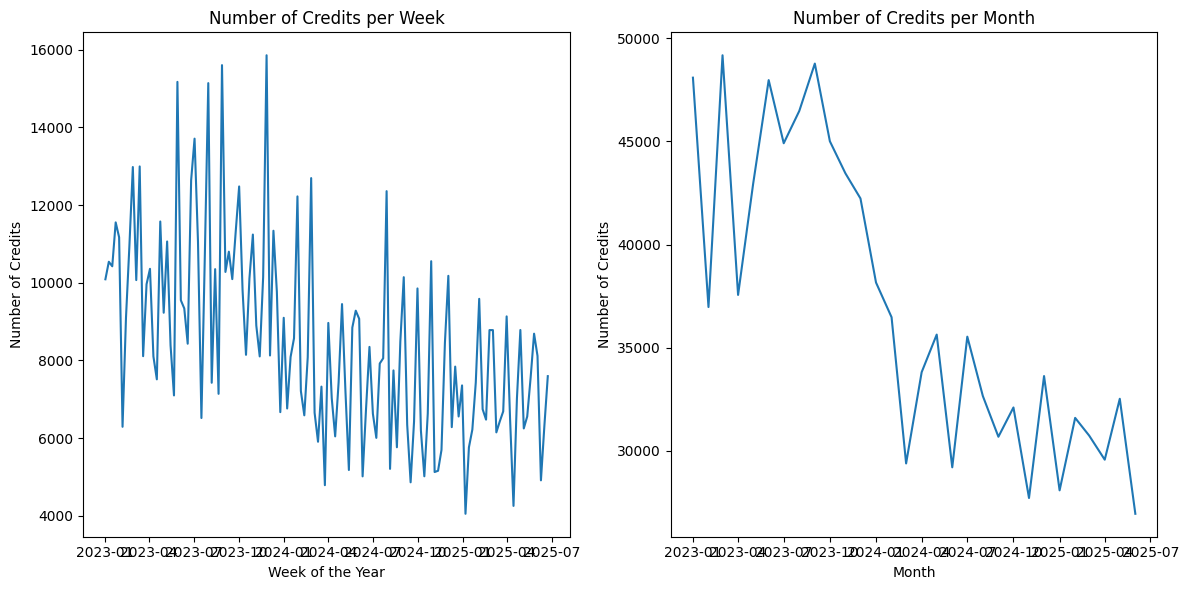

In [ ]:

df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['id_credito'].count()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['id_credito'].count()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('Number of Credits')
plt.title('Number of Credits per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('Number of Credits')
plt.title('Number of Credits per Month')

plt.tight_layout()
plt.show()


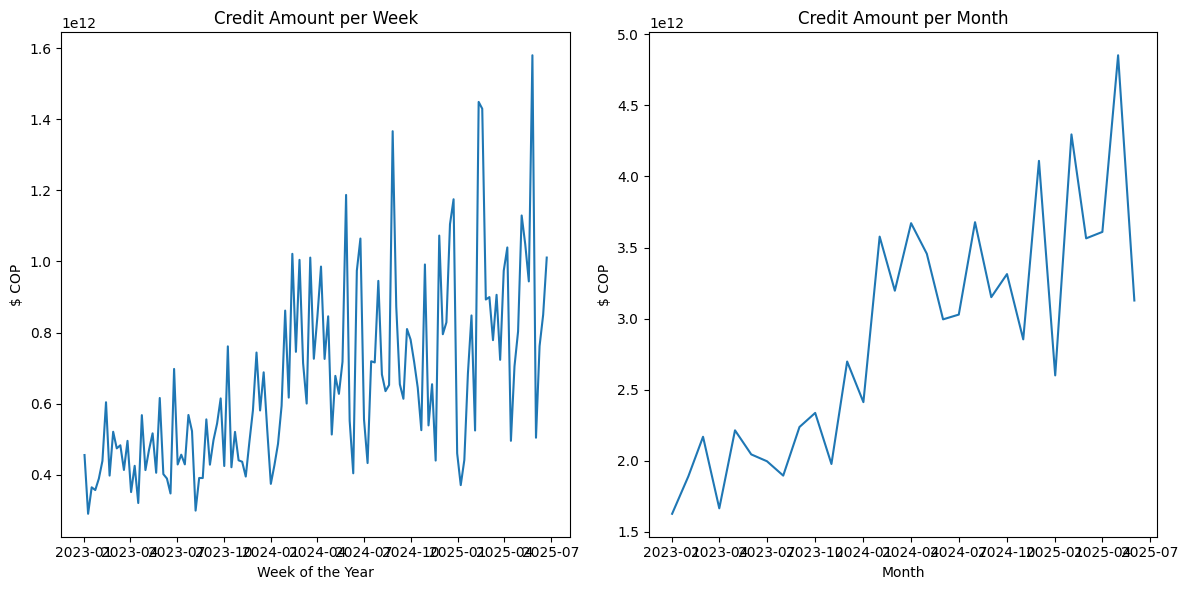

In [ ]:

df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['valor_credito'].sum()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['valor_credito'].sum()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('$ COP')
plt.title('Credit Amount per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('$ COP')
plt.title('Credit Amount per Month')

plt.tight_layout()
plt.show()


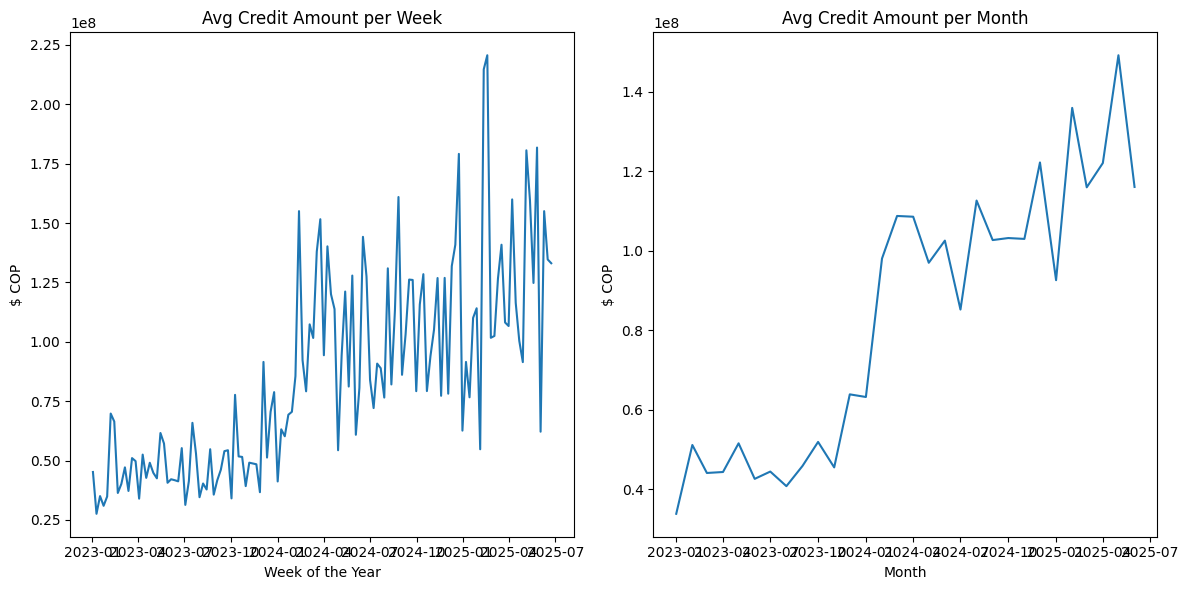

In [ ]:
df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['valor_credito'].mean()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['valor_credito'].mean()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('$ COP')
plt.title('Avg Credit Amount per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('$ COP')
plt.title('Avg Credit Amount per Month')

plt.tight_layout()
plt.show()


In [ ]:
df_pandas.columns

Index(['id_credito', 'fecha_credito', 'cod_municipio', 'tipo_cartera',
       'tipo_intermediario', 'tipo_productor', 'tipo_beneficiario',
       'tipo_persona', 'sexo', 'cod_destino', 'linea_credito', 'cadena',
       'eslabon_cadena', 'valor_credito', 'valor_inversion', 'plazo',
       'periodo_gracia', 'cuotas', 'cuotas_capital', 'tasa_indexacion',
       'periodicidad_tasa_indexacion', 'puntos_adicionales', 'garantia_fag',
       'nombre_programa', 'indicador_lec', 'valor_subsidio', 'nuevo',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio', 'tasa_indexacion_valor', 'tasa_credito',
       'tasa_credito_new', 'week', 'month'],
      dtype='object')

In [ ]:
df_pandas = df_pandas[df_pandas['linea_credito']!='Normalización de Cartera']

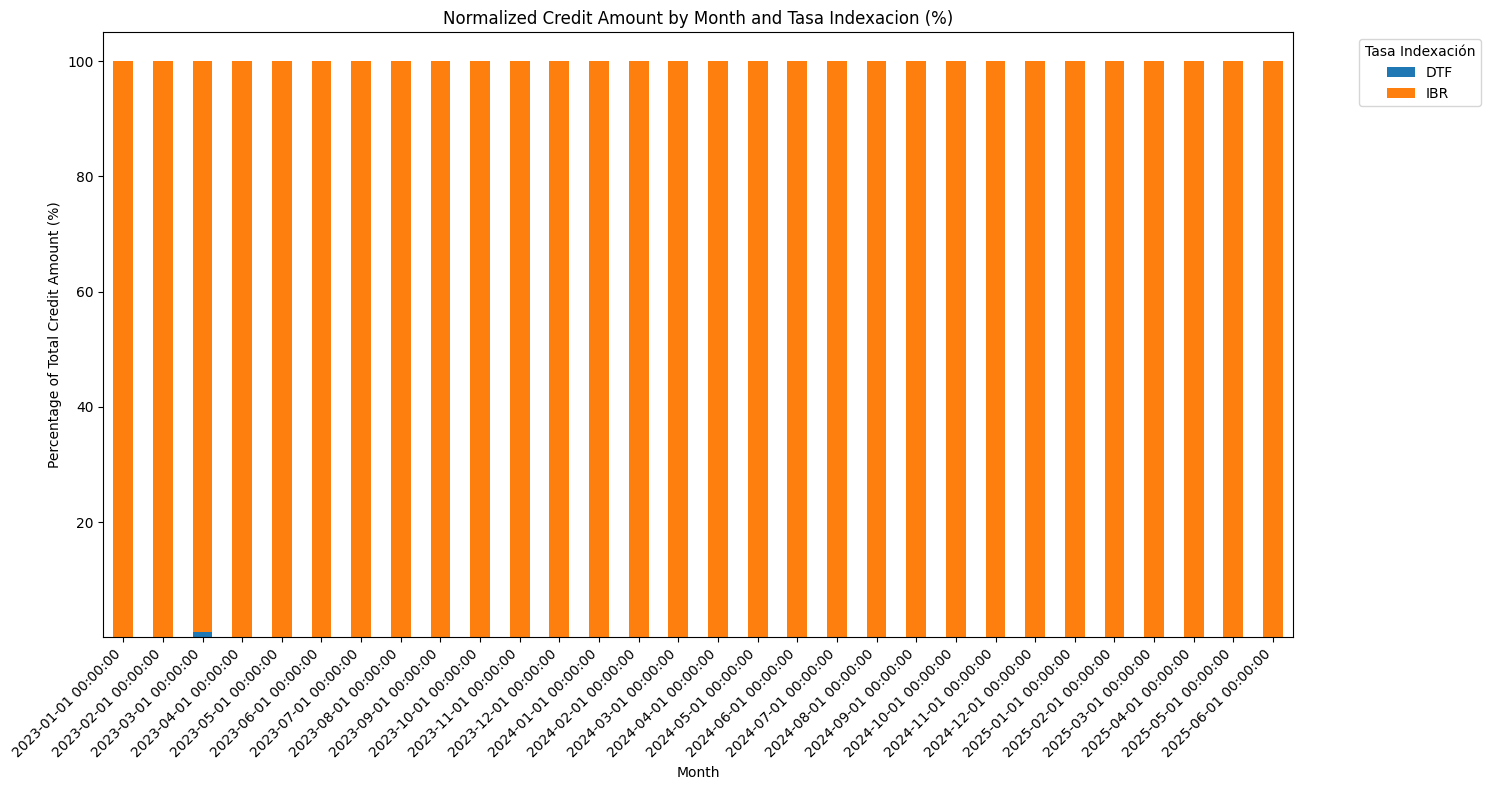

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tasa_indexacion'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tasa_indexacion', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tasa Indexacion (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tasa Indexación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

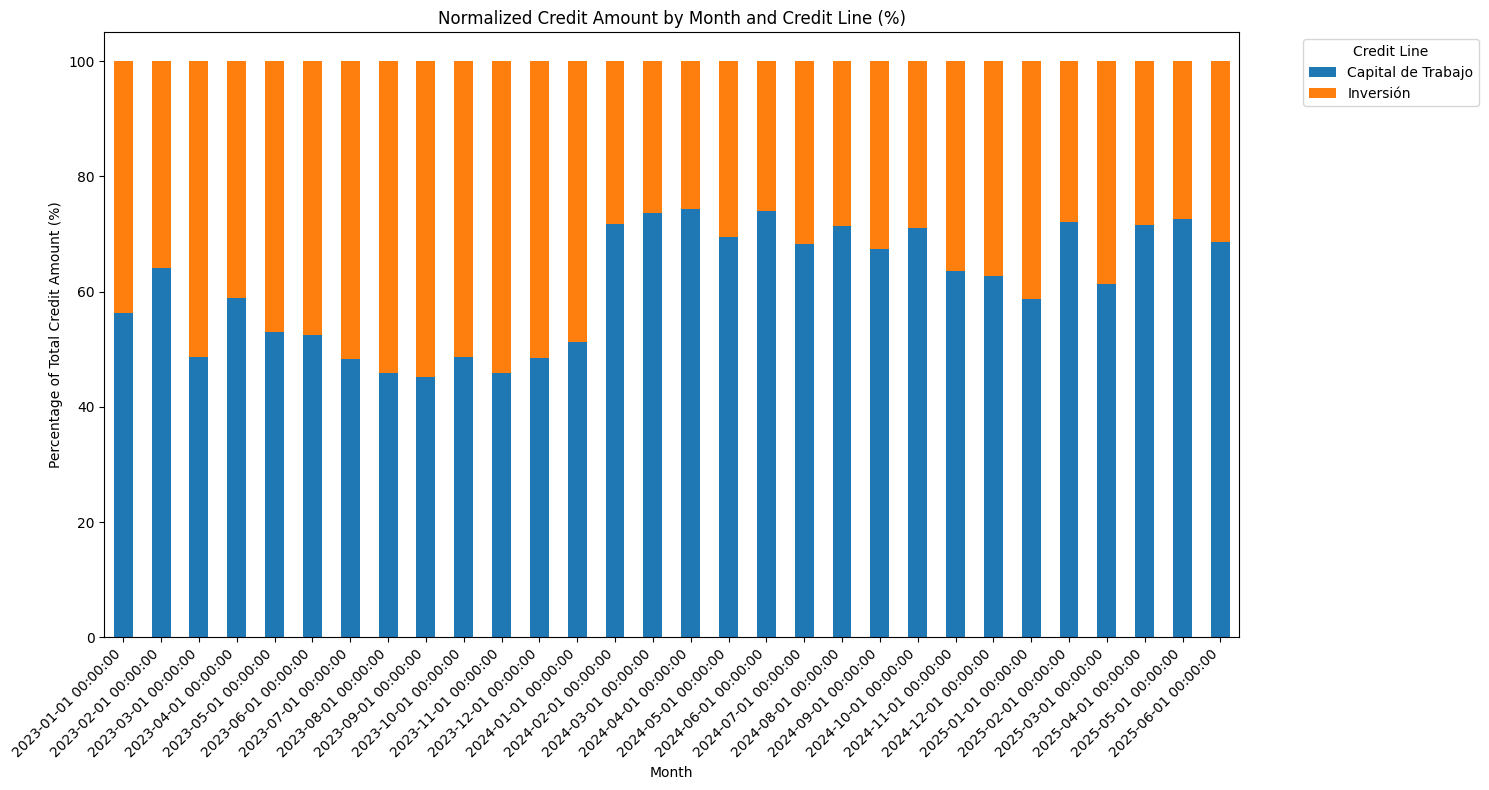

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'linea_credito'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='linea_credito', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Credit Line (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Credit Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

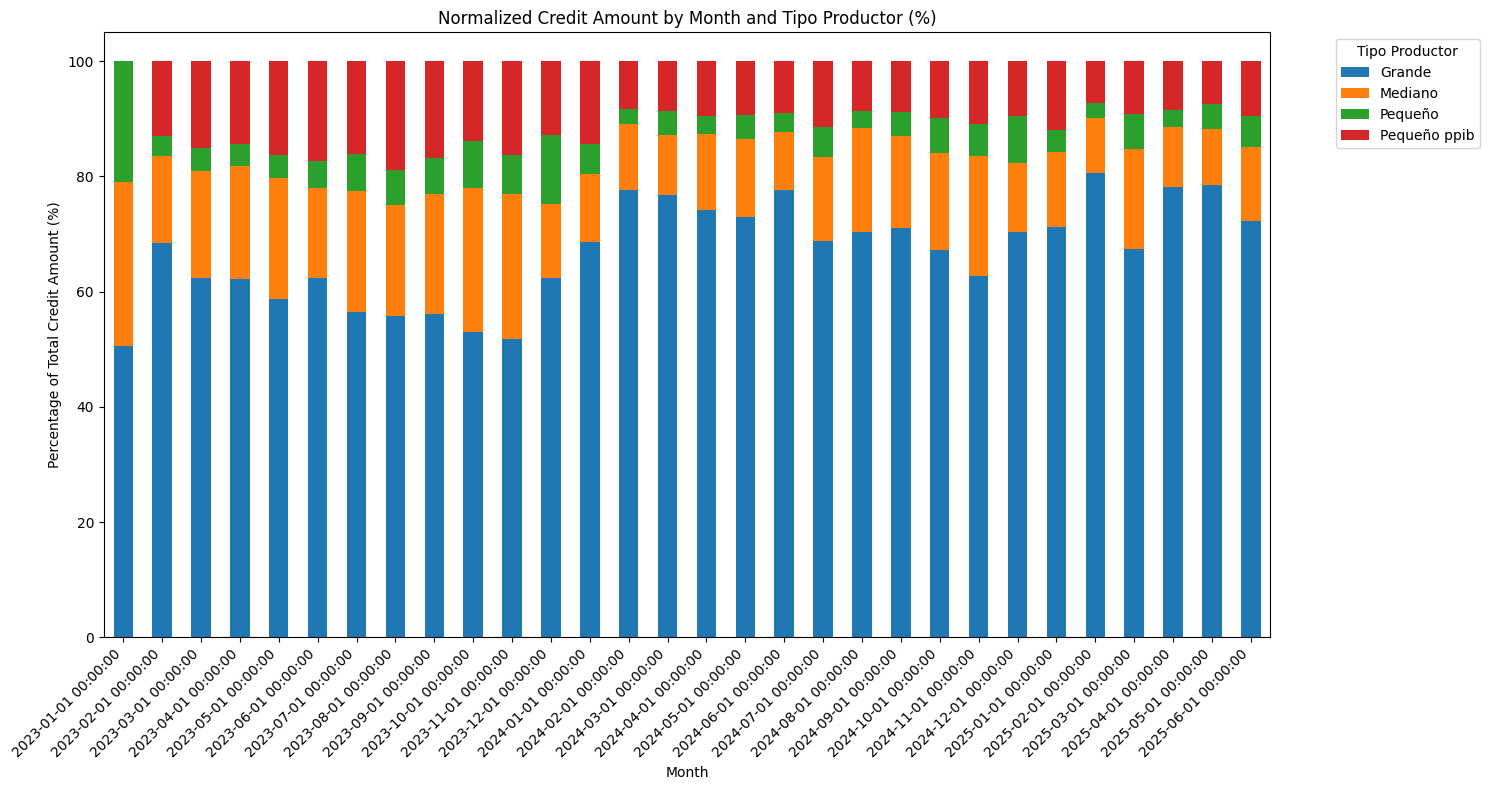

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tipo_productor'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_productor', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tipo Productor (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo Productor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

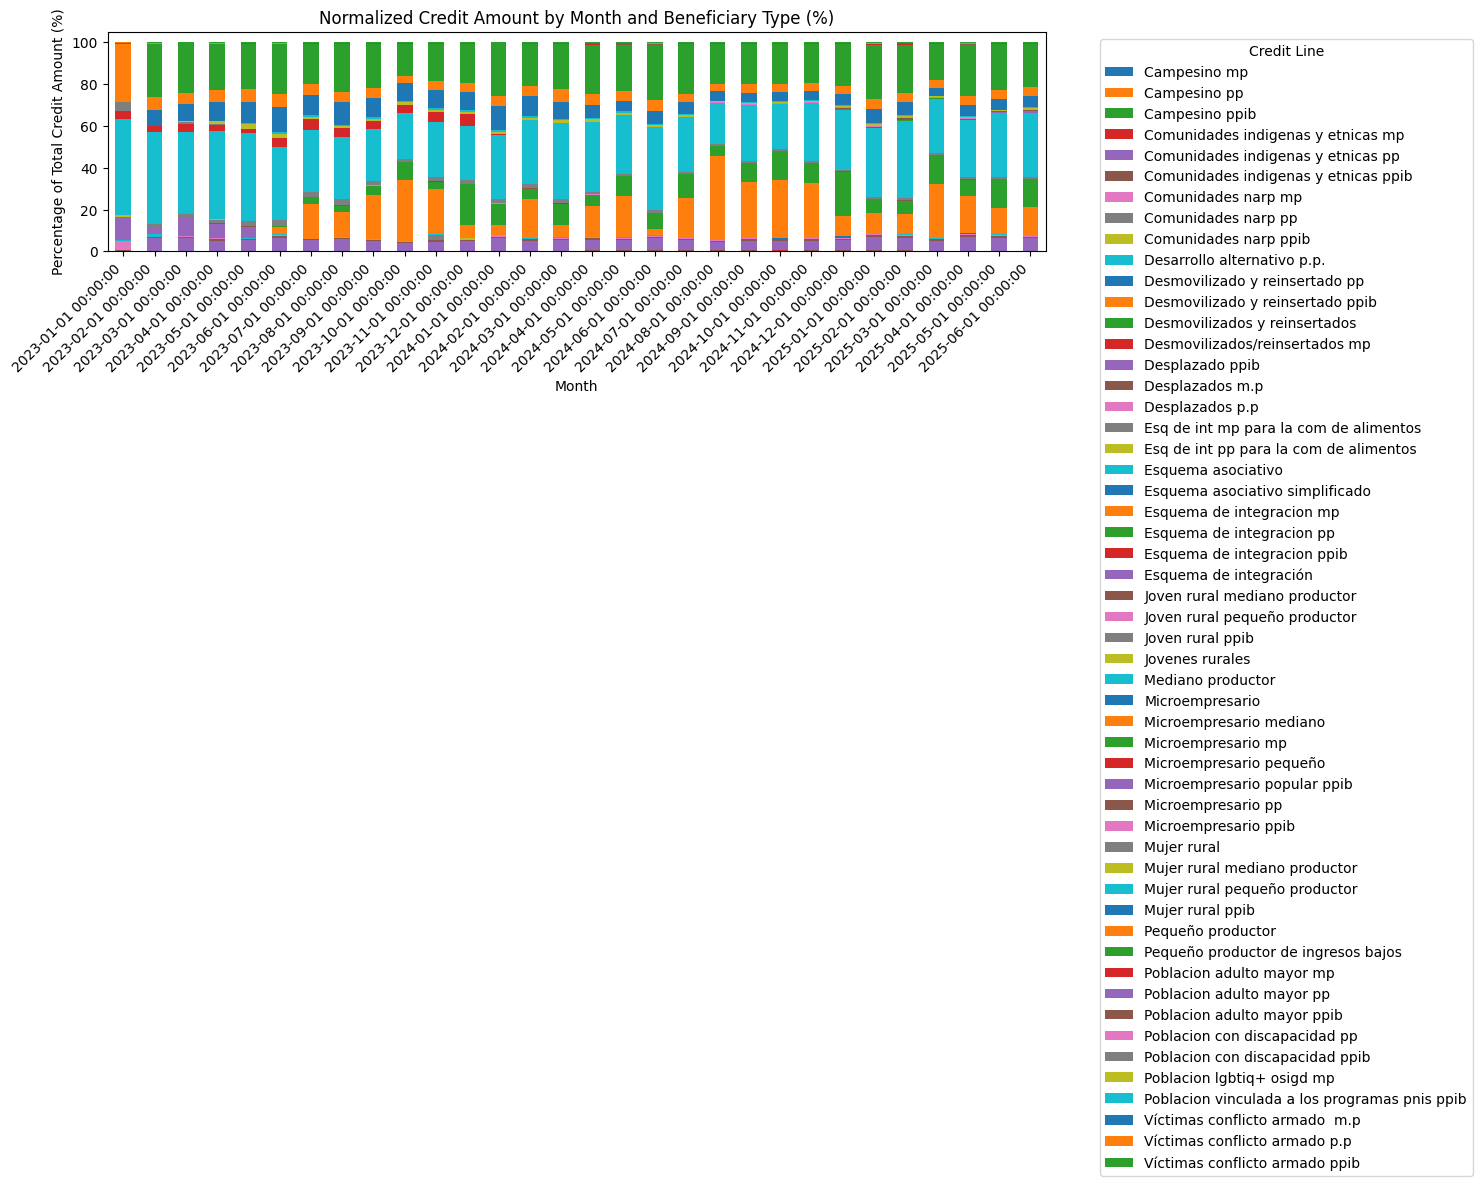

In [ ]:
grouped_data = df_pandas.query("tipo_productor != 'Grande'").groupby(['month', 'tipo_beneficiario'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_beneficiario', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Beneficiary Type (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Credit Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

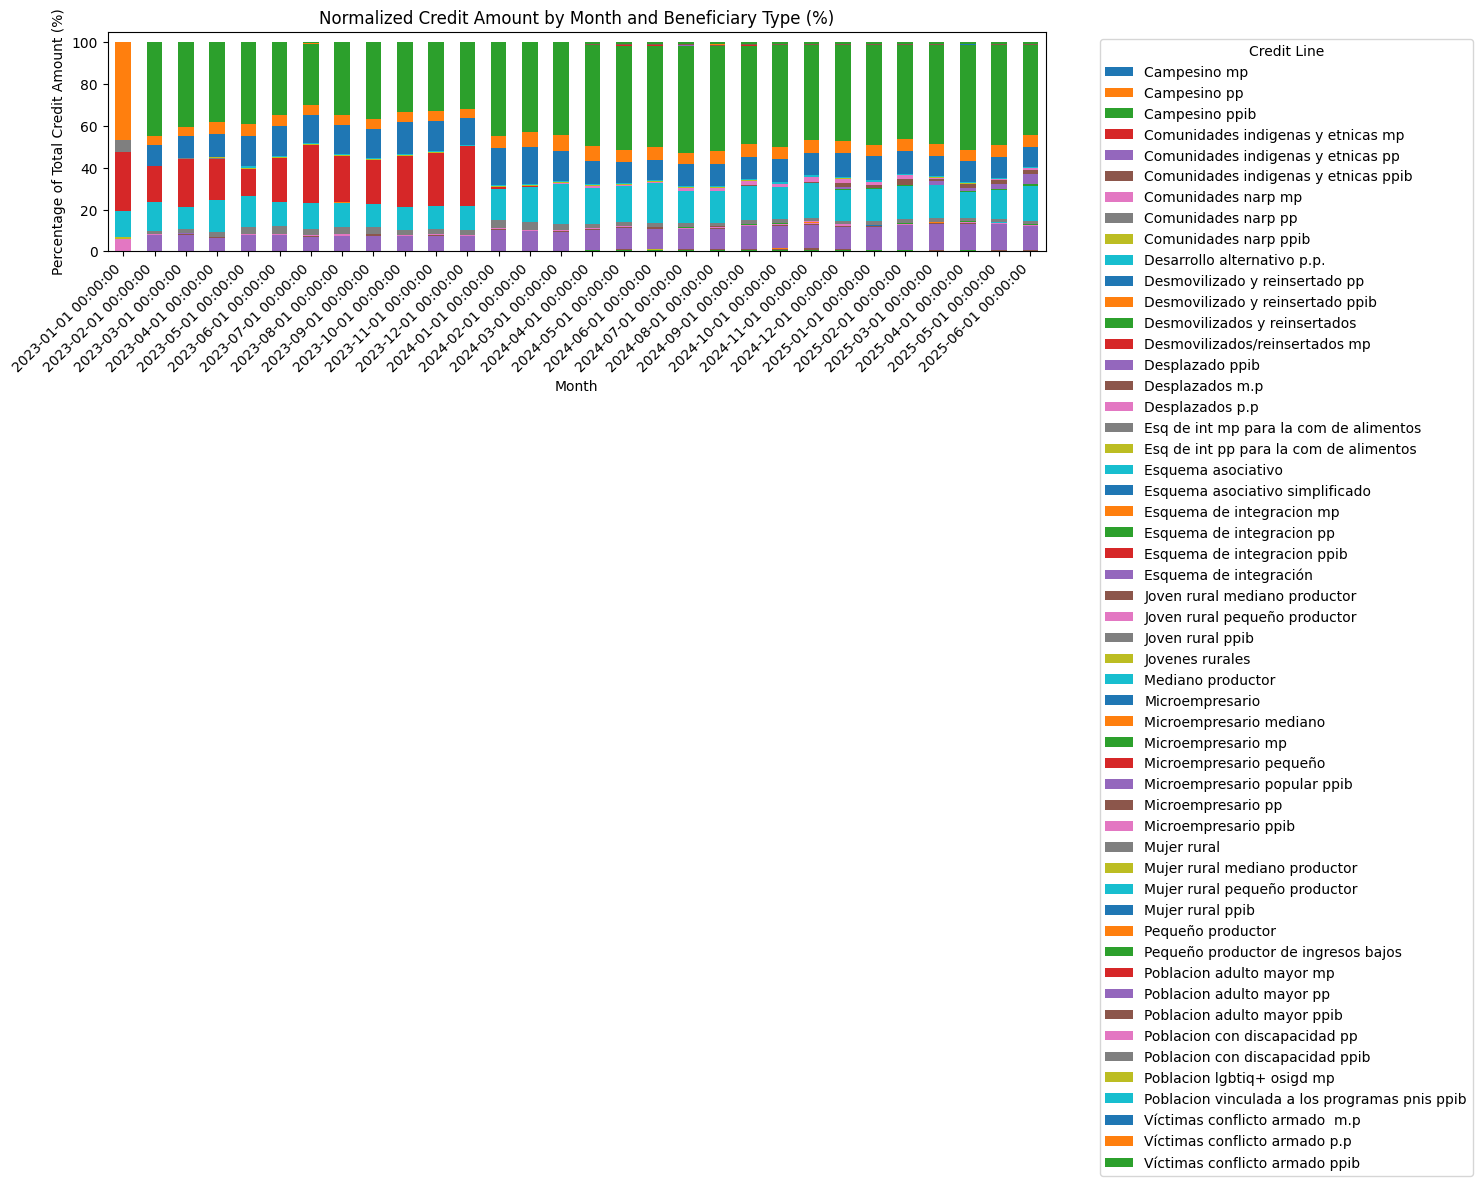

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.query("tipo_productor != 'Grande'").groupby(['month', 'tipo_beneficiario'])['id_credito'].count().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_beneficiario', values='id_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Beneficiary Type (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Credit Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

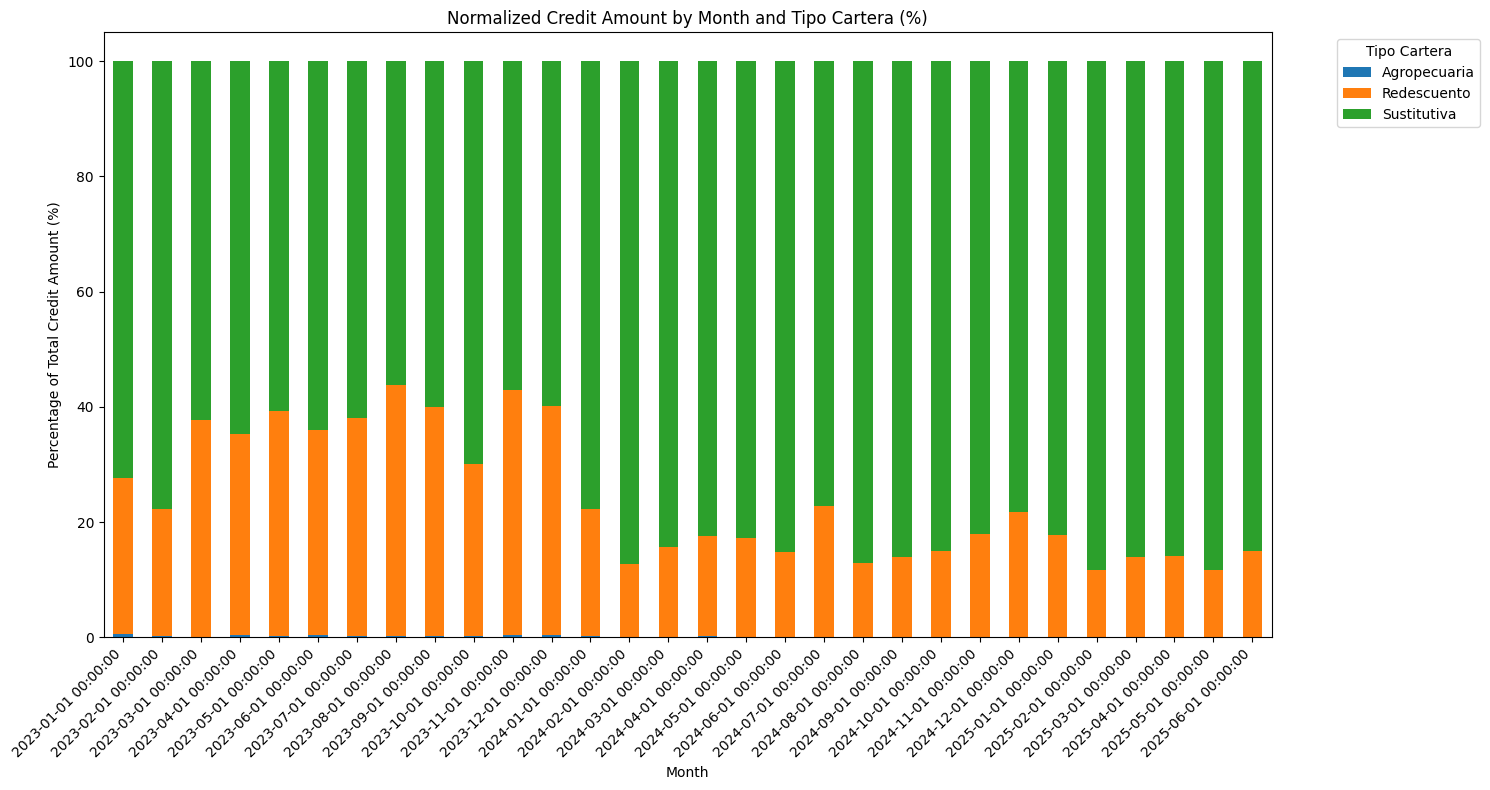

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tipo_cartera'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_cartera', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tipo Cartera (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo Cartera', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Tasas altas

In [ ]:
tasas_altas = df_pandas.query("tasa_credito_new > 100")

In [ ]:
tasas_altas.groupby('tipo_productor').count()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_beneficiario,tipo_persona,sexo,cod_destino,linea_credito,...,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,tasa_credito_new,week,month
tipo_productor,,,,,,,,,,,,,,,,,,,,,


# Nuevos destinatarios

In [ ]:
df_pandas['id_credito'] = 1

In [ ]:
#df_pandas = df_pandas[df_pandas['tasa_credito'] < 100]

In [ ]:
pd.DataFrame(df_pandas['tipo_beneficiario'].unique()).sort_values(0)

,0
58,Campesino gp
47,Campesino mp
43,Campesino pp
37,Campesino ppib
48,Comunidades indigenas y etnicas mp
...,...
20,Poblacion vinculada a los programas pnis ppib
22,Víctimas conflicto armado g.p
14,Víctimas conflicto armado m.p
15,Víctimas conflicto armado p.p


In [ ]:
df_pandas['tipo_beneficiario_v2'] = df_pandas['tipo_beneficiario'].replace({
    'Campesino pp': 'Campesino',
    'Campesino mp': 'Campesino',
    'Campesino gp': 'Campesino',
    'Campesino ppib': 'Campesino',
    'Comunidades indigenas y etnicas pp': 'Comunidades Indígenas',
    'Comunidades indigenas y etnicas mp': 'Comunidades Indígenas',
    'Comunidades indigenas y etnicas ppib': 'Comunidades Indígenas',
    'Comunidades narp mp': 'Comunidades Narp',
    'Comunidades narp pp': 'Comunidades Narp',
    'Comunidades narp ppib': 'Comunidades Narp',
    'Departamentos distritos y mun gp': 'Departamentos Distritos y Municipios',
    'Desmovilizado y reinsertado pp': 'Desmovilizado y Reinsertado',
    'Desmovilizado y reinsertado ppib': 'Desmovilizado y Reinsertado',
    'Desmovilizados y reinsertados': 'Desmovilizado y Reinsertado',
    'Desmovilizados/reinsertados gp': 'Desmovilizado y Reinsertado',
    'Desmovilizados/reinsertados mp': 'Desmovilizado y Reinsertado',
    'Desplazado ppib': 'Desplazados',
    'Desplazados p.p': 'Desplazados',
    'Desplazados m.p': 'Desplazados',
    'Desplazados gp': 'Desplazados',
    'Esq de int gp para la com de alimentos': 'Esq de int para la com de alimentos',
    'Esq de int mp para la com de alimentos': 'Esq de int para la com de alimentos',
    'Esq de int pp para la com de alimentos': 'Esq de int para la com de alimentos',
    'Esquema de integracion mp': 'Esquema de Integración',
    'Esquema de integracion pp': 'Esquema de Integración',
    'Esquema de integracion ppib': 'Esquema de Integración',
    'Esquema de integración': 'Esquema de Integración',
    'Joven rural grande productor': 'Joven Rural',
    'Joven rural mediano productor': 'Joven Rural',
    'Joven rural pequeño productor': 'Joven Rural',
    'Joven rural ppib': 'Joven Rural',
    'Jovenes rurales': 'Joven Rural',
    'Microempresario': 'Microempresario',
    'Microempresario mediano': 'Microempresario',
    'Microempresario mp': 'Microempresario',
    'Microempresario pequeño': 'Microempresario',
    'Microempresario pp': 'Microempresario',
    'Microempresario ppib': 'Microempresario',
    'Microempresario popular ppib': 'Microempresario',
    'Mujer rural grande productor': 'Mujer rural',
    'Mujer rural mediano productor': 'Mujer rural',
    'Mujer rural pequeño productor': 'Mujer rural',
    'Mujer rural ppib': 'Mujer rural',
    'Poblacion adulto mayor gp': 'Poblacion Adulto Mayor',
    'Poblacion adulto mayor mp': 'Poblacion Adulto Mayor',
    'Poblacion adulto mayor pp': 'Poblacion Adulto Mayor',
    'Poblacion adulto mayor ppib': 'Poblacion Adulto Mayor',
    'Poblacion con discapacidad gp': 'Poblacion con Discapacidad',
    'Poblacion con discapacidad mp': 'Poblacion con Discapacidad',
    'Poblacion con discapacidad pp': 'Poblacion con Discapacidad',
    'Poblacion con discapacidad ppib': 'Poblacion con Discapacidad',
    'Víctimas conflicto armado  g.p': 'Víctimas del Conflicto Armado',
    'Víctimas conflicto armado  m.p': 'Víctimas del Conflicto Armado',
    'Víctimas conflicto armado p.p': 'Víctimas del Conflicto Armado',
    'Víctimas conflicto armado ppib': 'Víctimas del Conflicto Armado',
})

In [ ]:
df_pandas['tipo_beneficiario_v2'].unique()

array(['Pequeño productor', 'Mediano productor', 'Desplazados',
       'Mujer rural', 'Pequeño productor de ingresos bajos',
       'Joven Rural', 'Víctimas del Conflicto Armado', 'Grande productor',
       'Desmovilizado y Reinsertado', 'Microempresario',
       'Esquema asociativo',
       'Poblacion vinculada a los programas pnis ppib',
       'Desarrollo alternativo p.p.', 'Departamentos distritos y mun',
       'Esquema de Integración', 'Departamentos Distritos y Municipios',
       'Esquema asociativo simplificado', 'Campesino',
       'Comunidades Indígenas', 'Poblacion Adulto Mayor',
       'Comunidades Narp', 'Poblacion con Discapacidad',
       'Esq de int para la com de alimentos',
       'Poblacion lgbtiq+ osigd mp'], dtype=object)

In [ ]:
def compare_numeric_by_category(df, numeric_col, category_col):
    """
    Compares a numeric column across different categories in another column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        numeric_col (str): The name of the numeric column to compare.
        category_col (str): The name of the categorical column to group by.
    """

    # Create box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=category_col, y=numeric_col, data=df)
    plt.title(f'Comparison of {numeric_col} by {category_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Display descriptive statistics
    print(f"\nDescriptive Statistics of {numeric_col} by {category_col}:")
    display(df.groupby(category_col)[numeric_col].describe())

## Comparaciones univariables

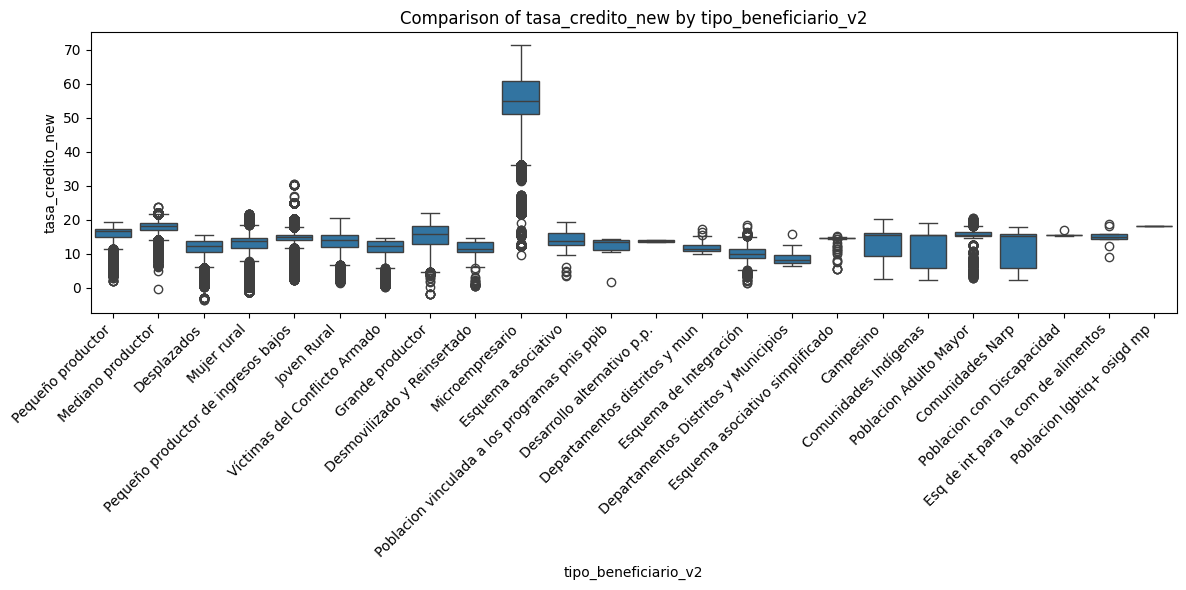


Descriptive Statistics of tasa_credito_new by tipo_beneficiario_v2:


,count,mean,std,min,25%,50%,75%,max
tipo_beneficiario_v2,,,,,,,,
Campesino,2294.0,13.508202,4.297197,2.608,9.37625,15.4570,15.99100,20.236
Comunidades Indígenas,1224.0,12.171593,5.077770,2.291,5.82350,15.4160,15.55425,19.001
Comunidades Narp,44.0,10.985932,5.891839,2.291,5.83875,15.2955,15.70600,17.829
Departamentos Distritos y Municipios,154.0,8.599364,1.610035,6.525,7.16625,8.3380,9.73225,15.886
Departamentos distritos y mun,348.0,11.712761,1.189412,9.850,10.72575,11.4815,12.62875,17.315
Desarrollo alternativo p.p.,2.0,13.787000,0.598212,13.364,13.57550,13.7870,13.99850,14.210
Desmovilizado y Reinsertado,193.0,11.003036,3.718036,0.495,10.63100,11.5300,13.59900,14.527
Desplazados,89406.0,11.589381,3.029593,-3.521,10.65900,12.2060,13.78500,15.495
Esq de int para la com de alimentos,11.0,14.891182,2.584715,9.120,14.44800,15.0350,15.75700,18.669


In [ ]:
compare_numeric_by_category(df_pandas, 'tasa_credito_new', 'tipo_beneficiario_v2')


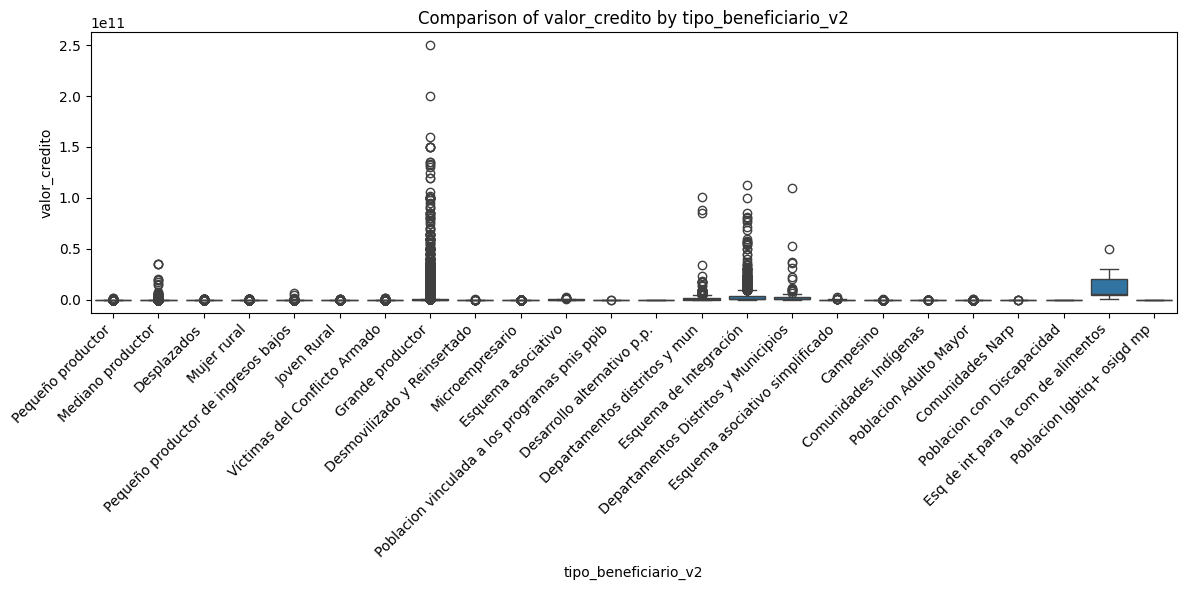


Descriptive Statistics of valor_credito by tipo_beneficiario_v2:


,count,mean,std,min,25%,50%,75%,max
tipo_beneficiario_v2,,,,,,,,
Campesino,2294.0,1.833829e+07,2.027565e+07,1000000.0,8.018250e+06,1.400000e+07,2.200000e+07,3.169986e+08
Comunidades Indígenas,1224.0,1.463014e+07,1.315946e+07,1500000.0,7.000000e+06,1.100000e+07,2.000000e+07,2.000000e+08
Comunidades Narp,44.0,2.733523e+07,1.496110e+07,5000000.0,1.750000e+07,2.500000e+07,3.070000e+07,7.000000e+07
Departamentos Distritos y Municipios,154.0,3.860399e+09,1.101482e+10,17077021.0,4.353805e+08,1.137186e+09,3.000000e+09,1.100000e+11
Departamentos distritos y mun,348.0,2.657492e+09,9.097218e+09,3985978.0,2.000000e+08,5.672682e+08,1.962500e+09,1.010967e+11
Desarrollo alternativo p.p.,2.0,3.250000e+07,3.535534e+06,30000000.0,3.125000e+07,3.250000e+07,3.375000e+07,3.500000e+07
Desmovilizado y Reinsertado,193.0,2.136843e+07,3.045693e+07,3500000.0,1.100000e+07,1.500000e+07,2.200000e+07,3.600000e+08
Desplazados,89406.0,1.664867e+07,1.713675e+07,700000.0,9.000000e+06,1.385000e+07,2.000000e+07,1.240413e+09
Esq de int para la com de alimentos,11.0,1.372570e+10,1.516659e+10,777000000.0,4.850000e+09,5.830125e+09,1.998778e+10,5.000000e+10


In [ ]:
compare_numeric_by_category(df_pandas, 'valor_credito', 'tipo_beneficiario_v2')

## Evolución en el tiempo

In [ ]:
def plot_monthly_numerical_variable(df, numeric_col,category):
  # Group by month and tipo_beneficiario_v2 and calculate the mean tasa_credito
  monthly_tasa_beneficiario = df.groupby(['month', category])[numeric_col].mean().reset_index()

  # Pivot the data for plotting
  pivot_monthly_tasa = monthly_tasa_beneficiario.pivot(index='month', columns=category, values=numeric_col)

  # Plotting the line chart
  plt.figure(figsize=(15, 8))
  for column in pivot_monthly_tasa.columns:
      plt.plot(pivot_monthly_tasa.index, pivot_monthly_tasa[column], label=column)

  plt.title(f'Evolution of Average {numeric_col} by {category} over Time')
  plt.xlabel('Month')
  plt.ylabel(f'Average {numeric_col}')
  plt.xticks(rotation=45, ha='right')
  plt.legend(title=category, bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.tight_layout()
  plt.show()

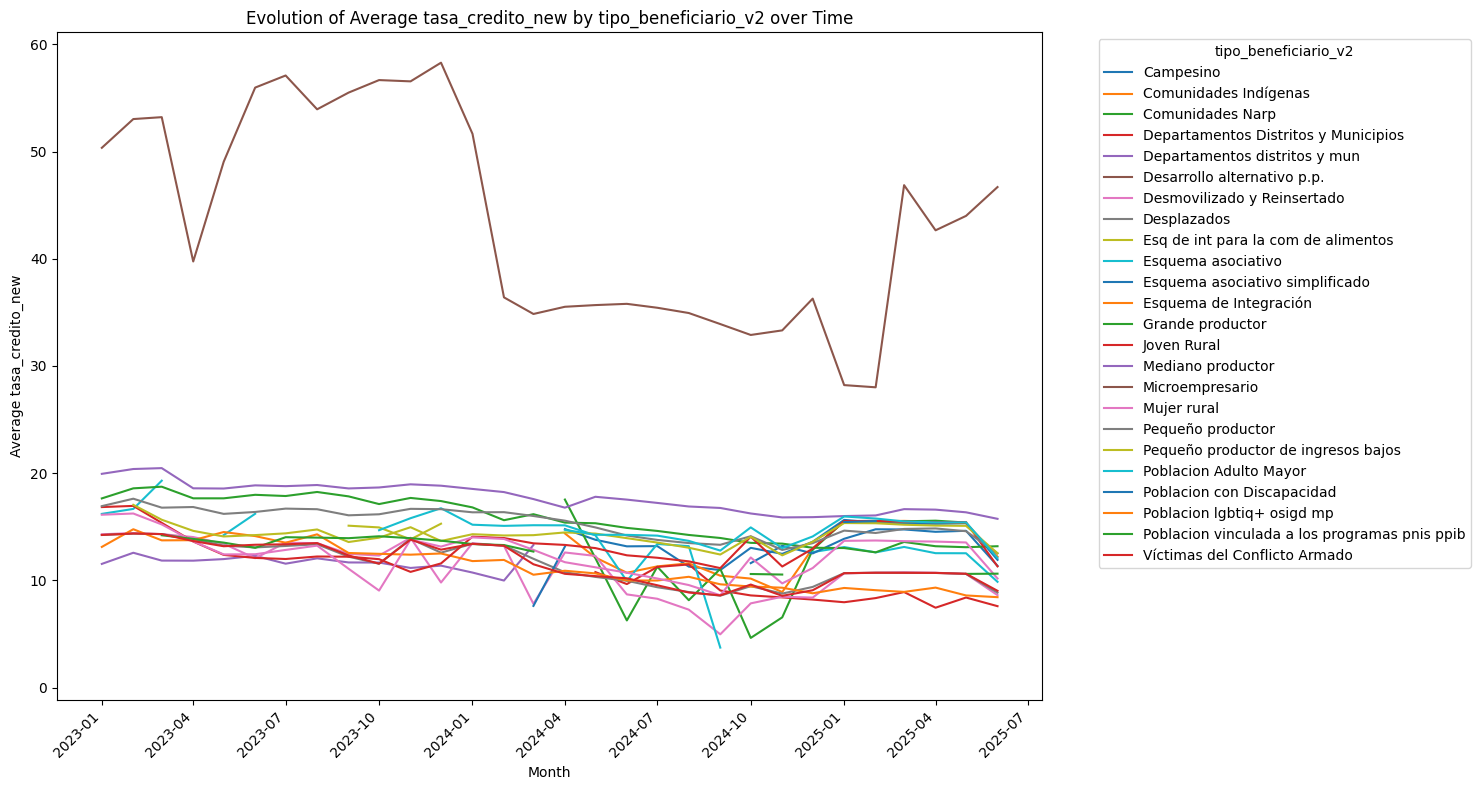

In [ ]:
plot_monthly_numerical_variable(df_pandas, 'tasa_credito_new', 'tipo_beneficiario_v2')

In [ ]:
def plot_monthly_categorical_distribution(df, category_col, value_col):
    """
    Generates stacked and 100% normalized bar charts for a categorical variable
    over time based on the sum of a numeric column.

    Args:
        df (pd.DataFrame): The input DataFrame with a 'month' column.
        category_col (str): The name of the categorical column.
        value_col (str): The name of the numeric column to sum.
    """

    # Group by month and categorical variable, summing the value_col
    grouped_data = df.groupby(['month', category_col])[value_col].sum().reset_index()

    # Pivot the data to get months as index and categorical variable as columns
    pivot_data = grouped_data.pivot(index='month', columns=category_col, values=value_col).fillna(0)

    # Plotting the stacked bar chart (raw values)
    ax1 = pivot_data.plot(kind='bar', stacked=True, figsize=(15, 8))
    plt.title(f'Total {value_col} by Month and {category_col}')
    plt.xlabel('Month')
    plt.ylabel(f'Total {value_col}')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=category_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Normalize the data to 100%
    normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

    # Plotting the stacked bar chart (normalized to 100%)
    ax2 = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))
    plt.title(f'Normalized {value_col} by Month and {category_col} (%)')
    plt.xlabel('Month')
    plt.ylabel(f'Percentage of Total {value_col} (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=category_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


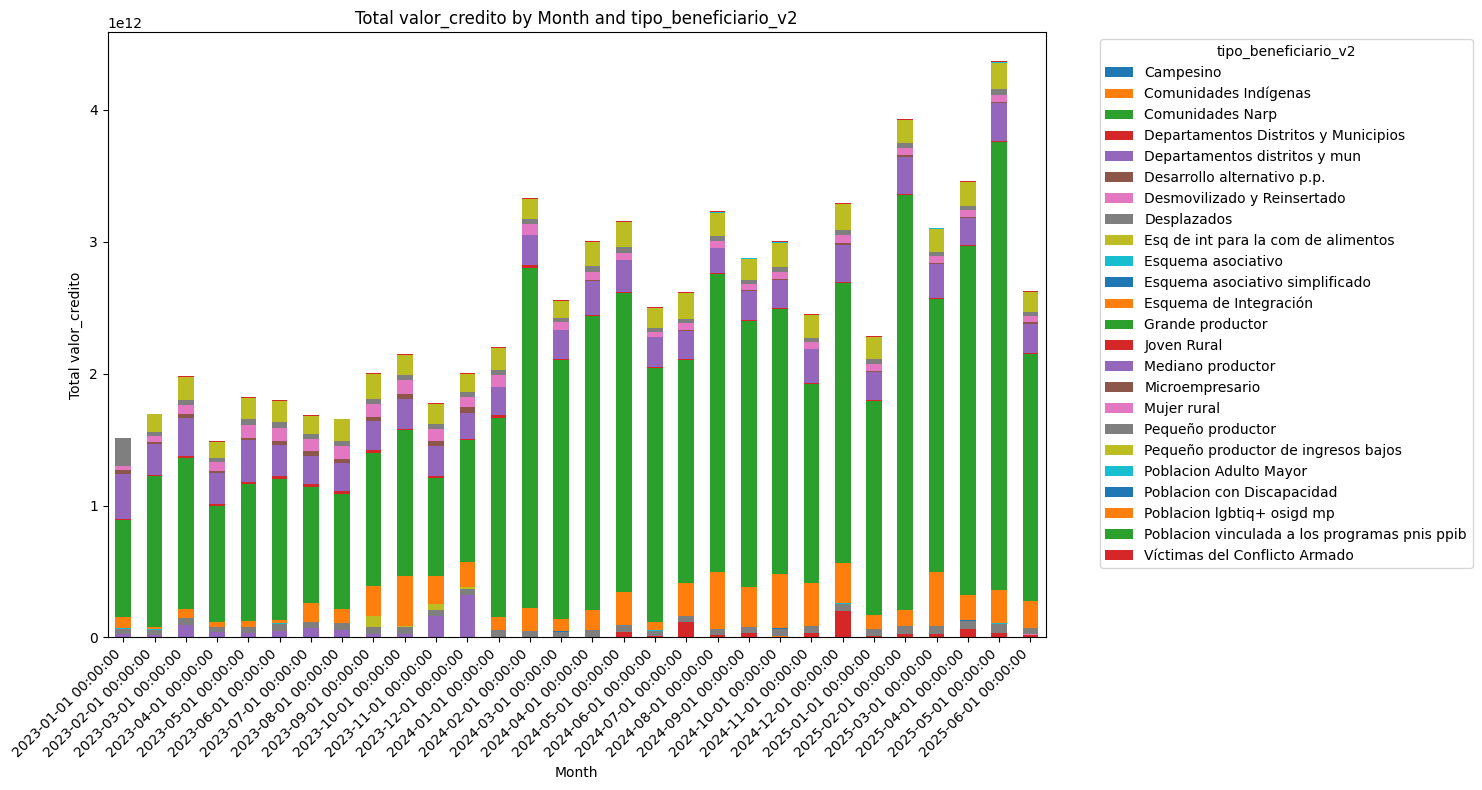

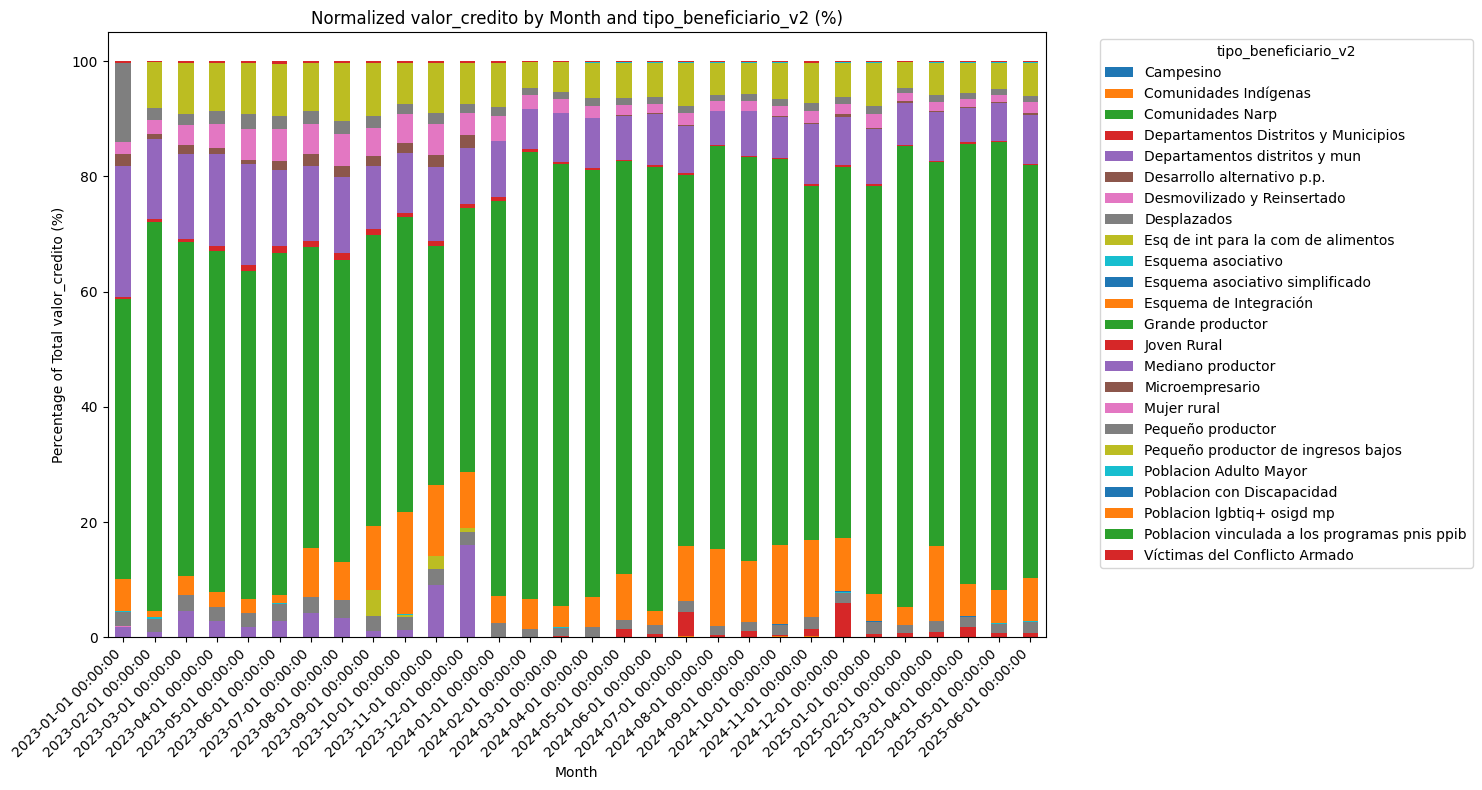

In [ ]:
plot_monthly_categorical_distribution(df_pandas, 'tipo_beneficiario_v2', 'valor_credito')

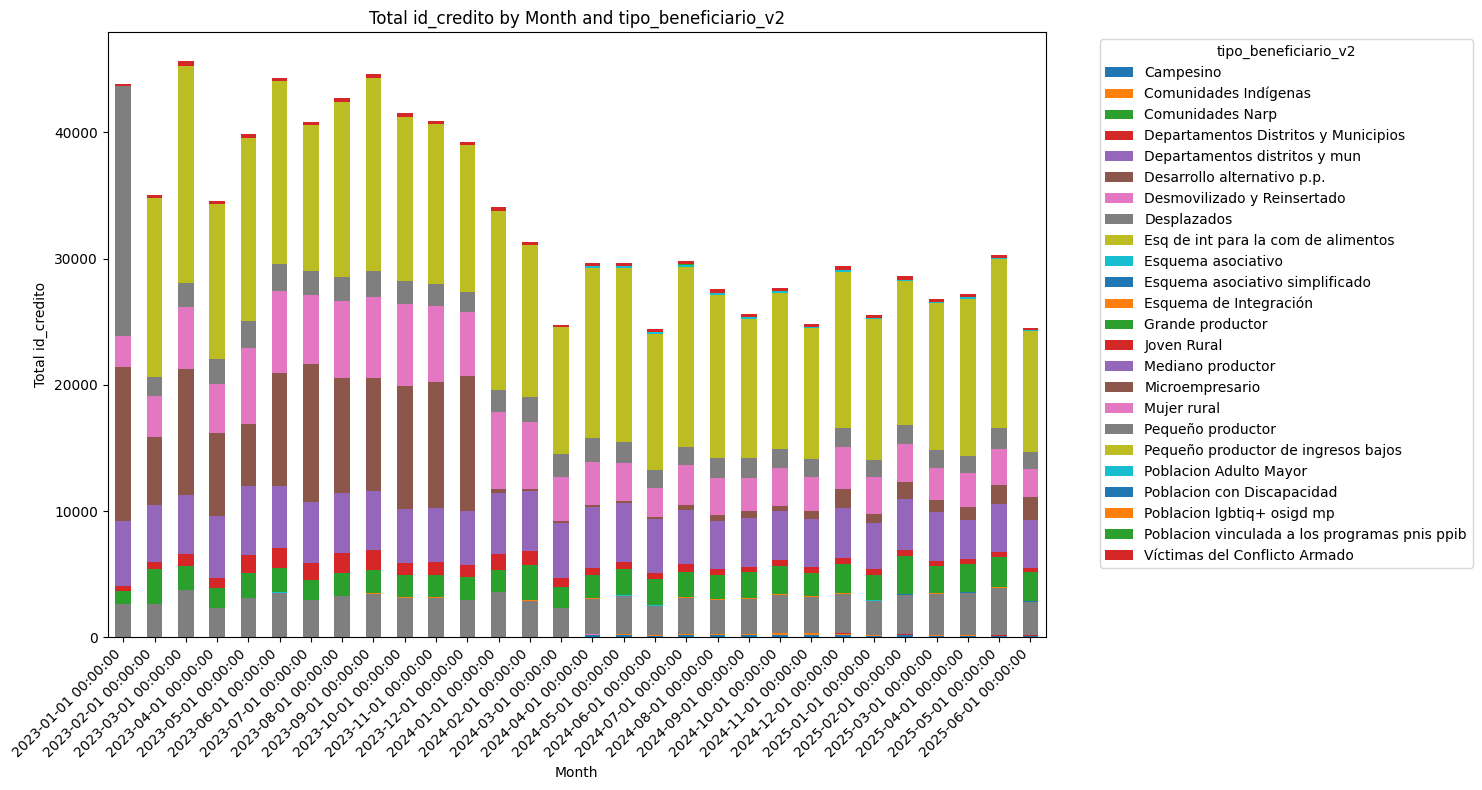

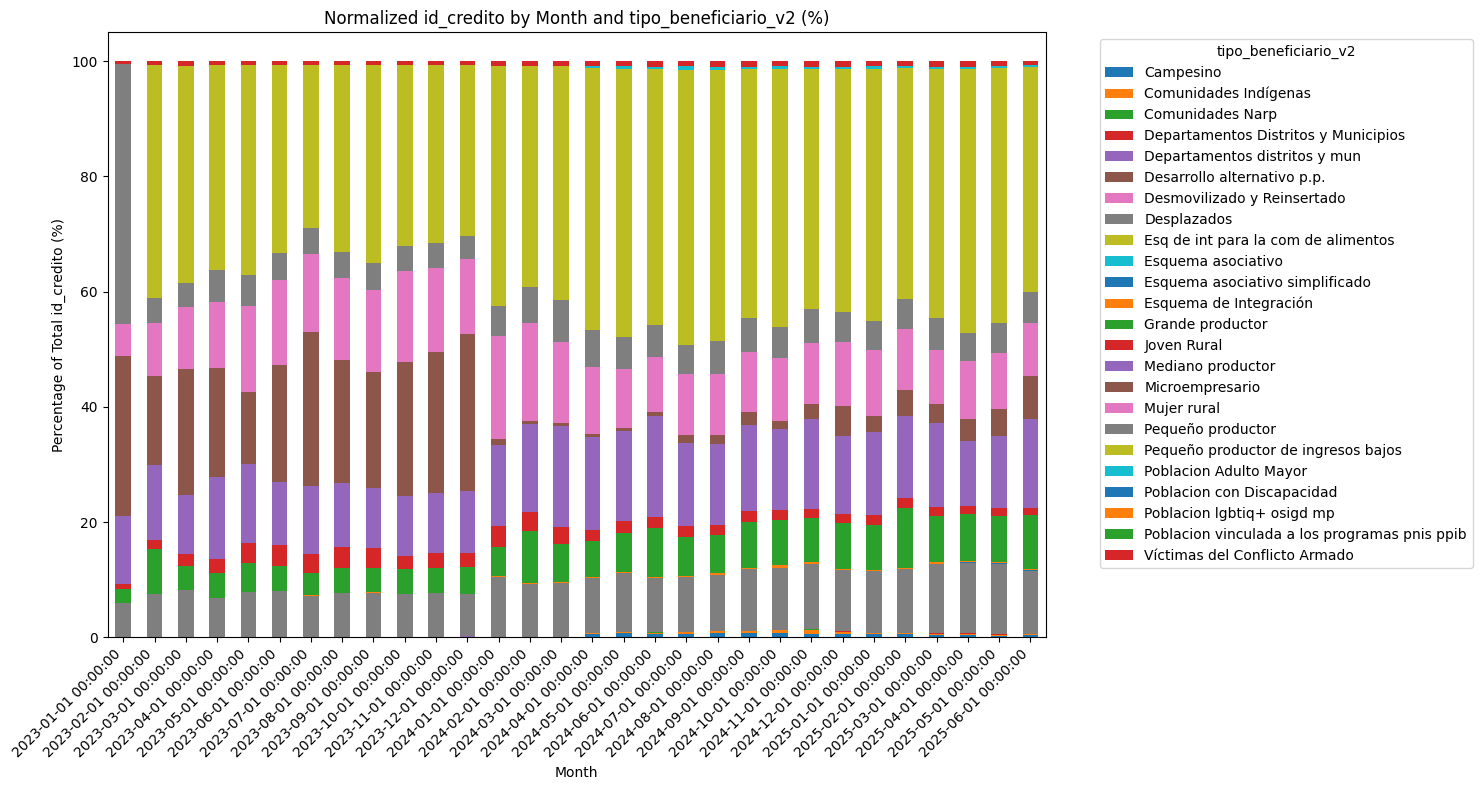

In [ ]:
plot_monthly_categorical_distribution(df_pandas, 'tipo_beneficiario_v2', 'id_credito')

### Sin grande productor

In [ ]:
df_pandas.query("tipo_beneficiario_v2 != 'Grande productor' and tasa_credito_new > 1000")

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,tasa_credito_new,week,month,tipo_beneficiario_v2


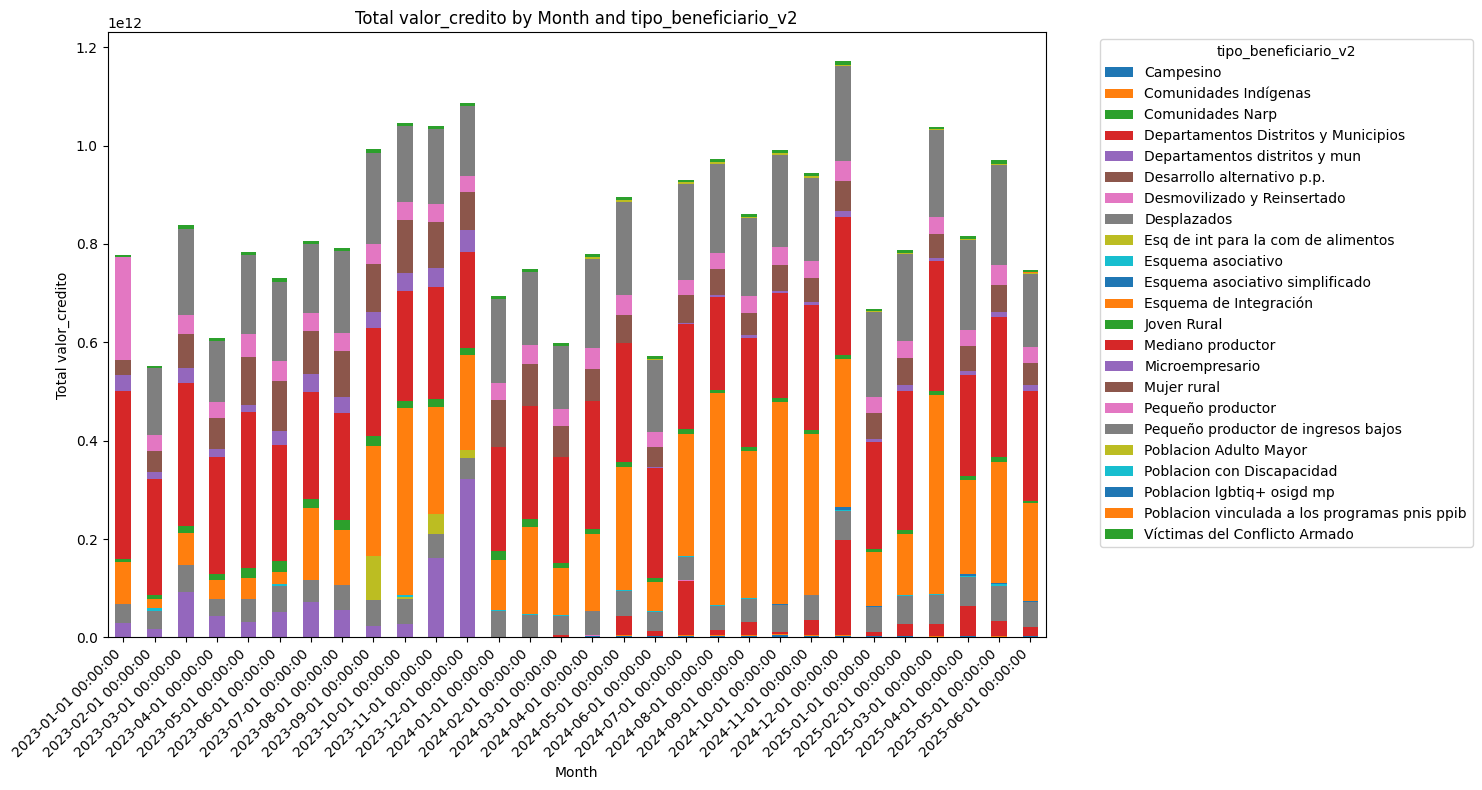

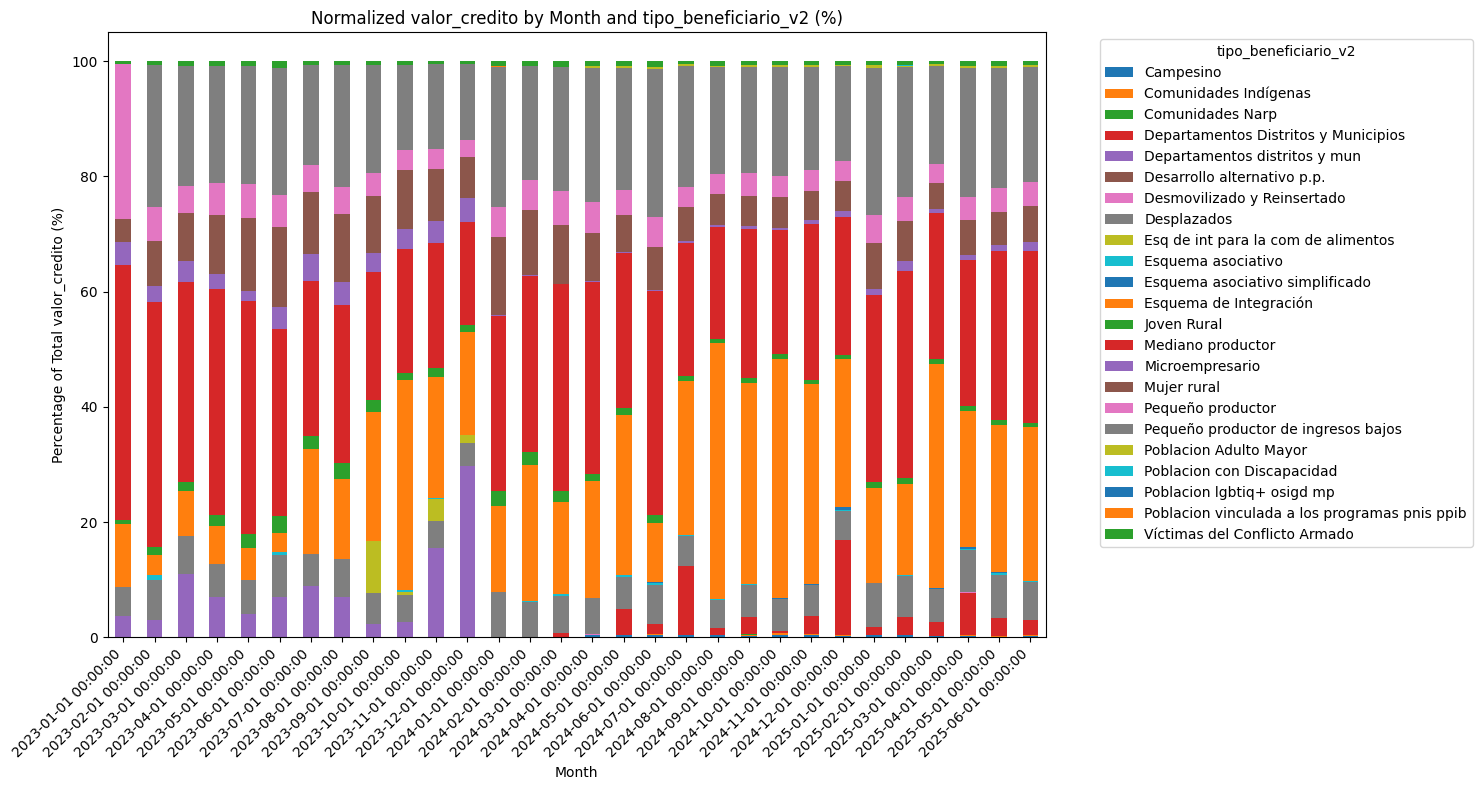

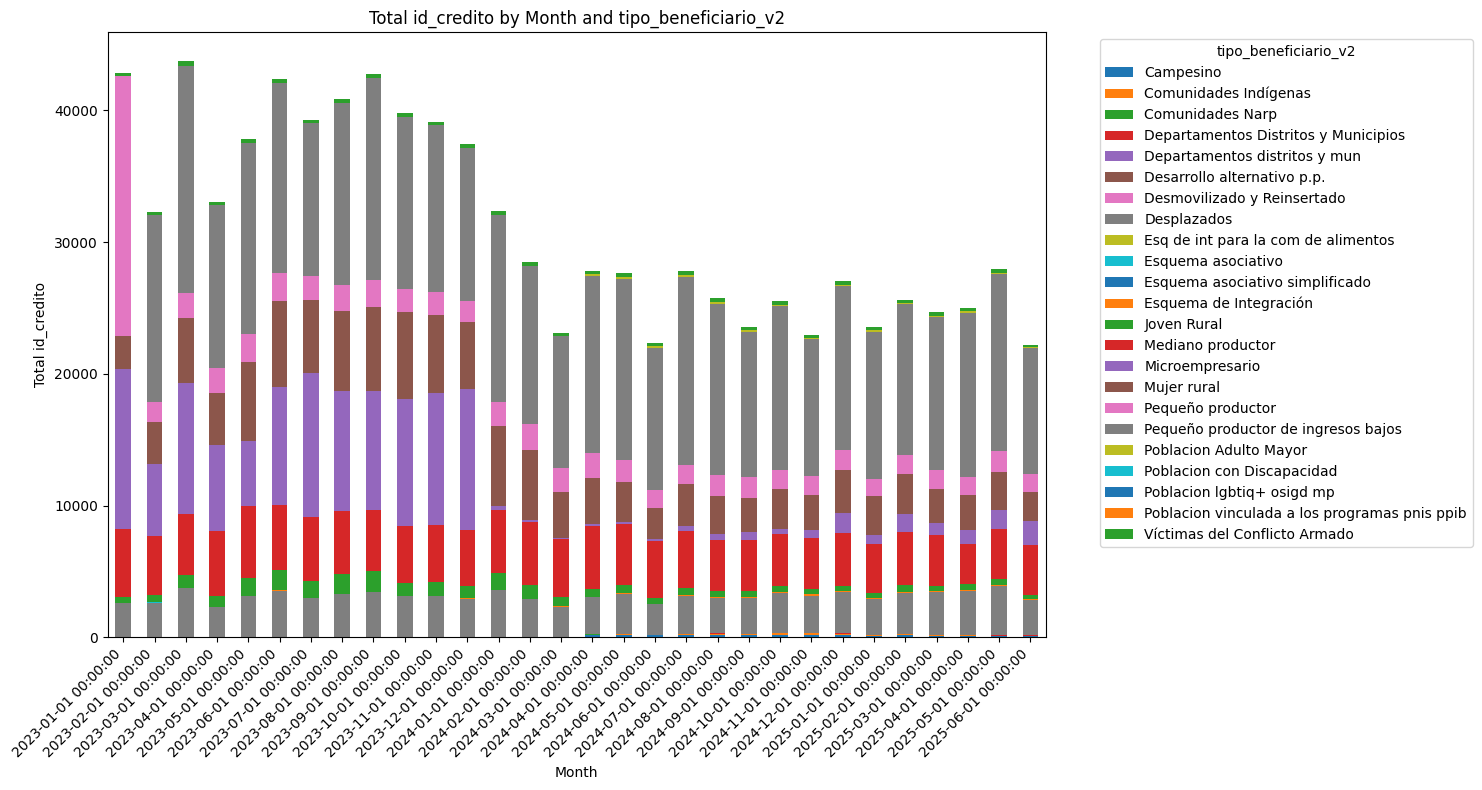

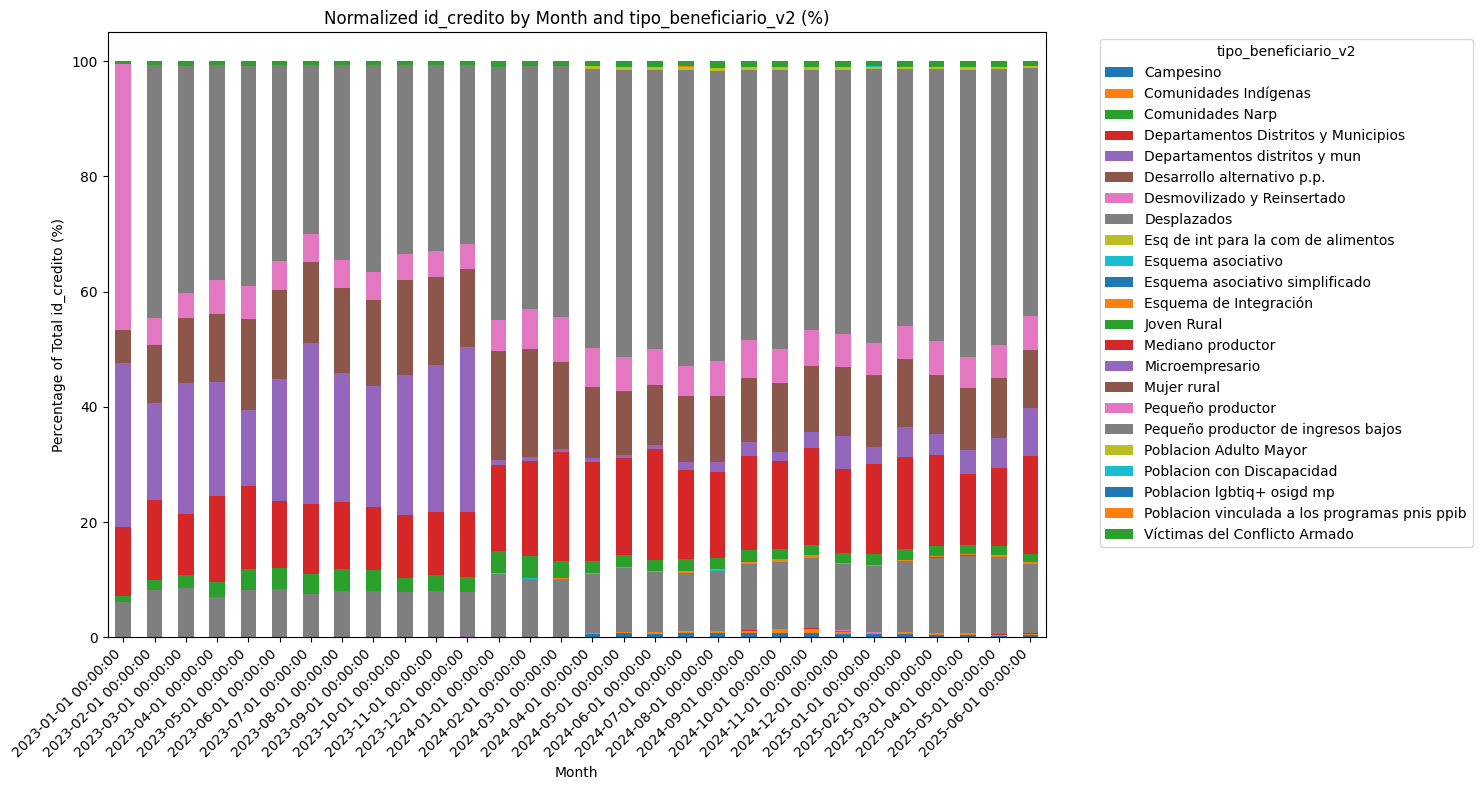

In [ ]:
plot_monthly_categorical_distribution(df_pandas.query("tipo_beneficiario_v2 != 'Grande productor'"), 'tipo_beneficiario_v2', 'valor_credito')
plot_monthly_categorical_distribution(df_pandas.query("tipo_beneficiario_v2 != 'Grande productor'"), 'tipo_beneficiario_v2', 'id_credito')

## Solo grande productor

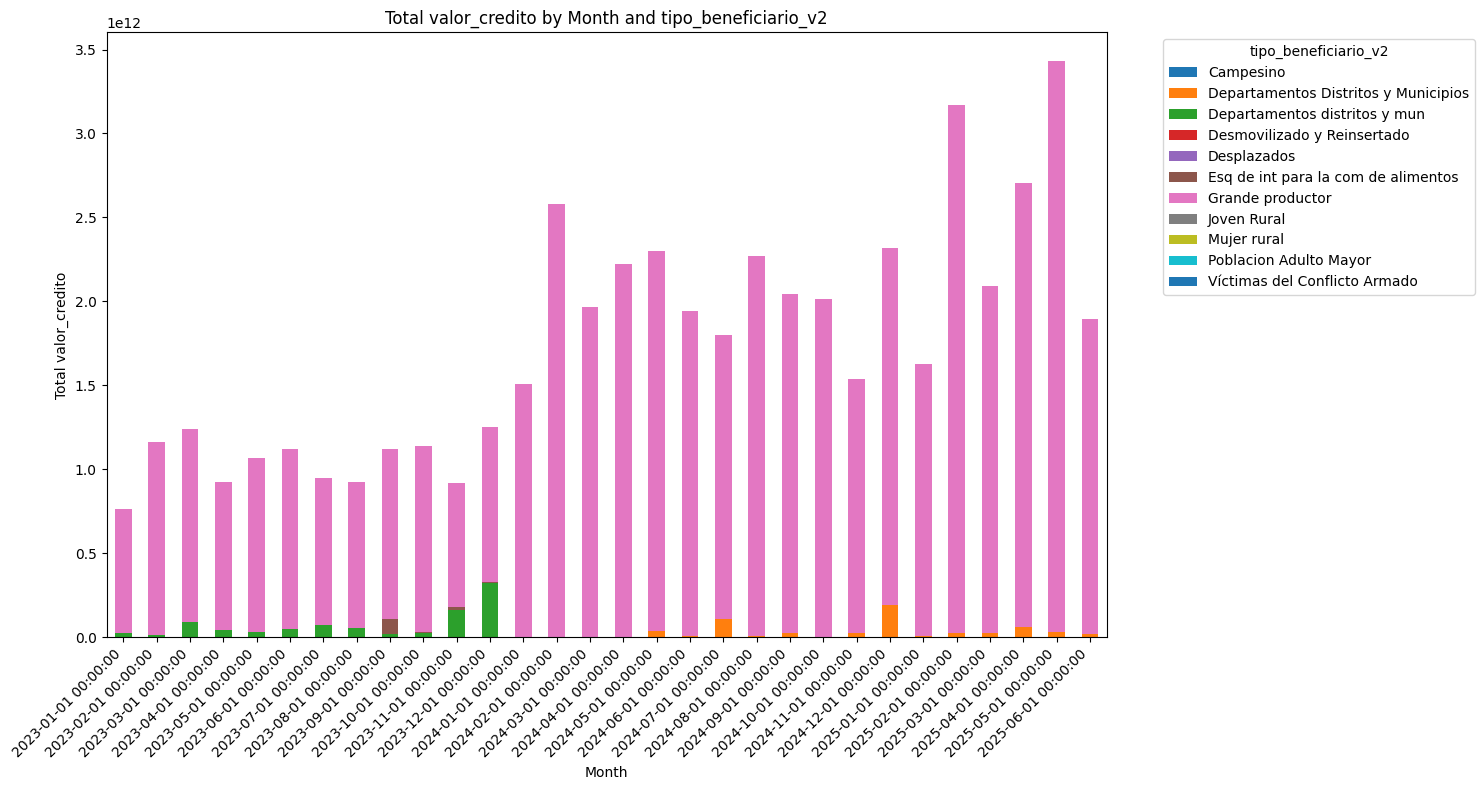

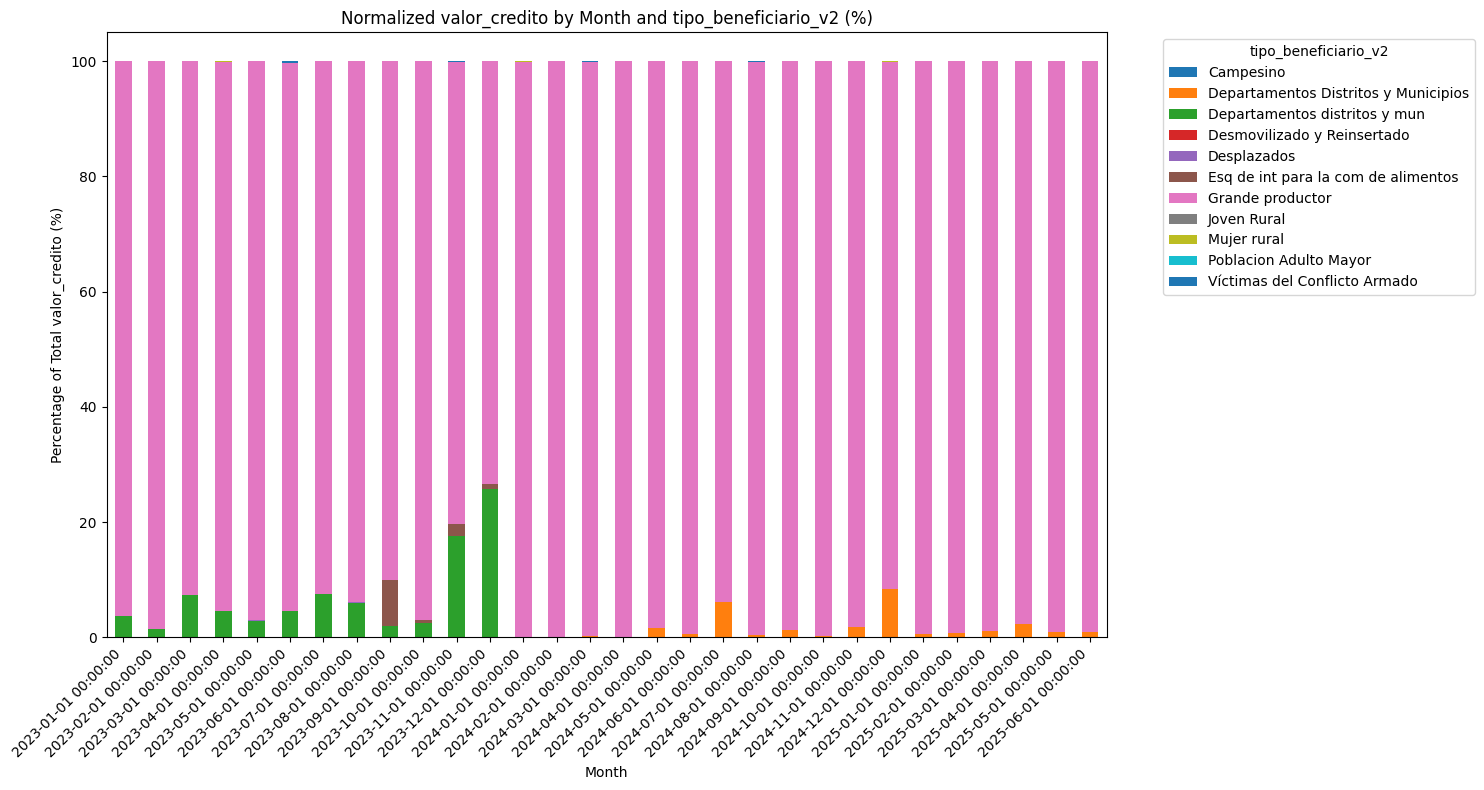

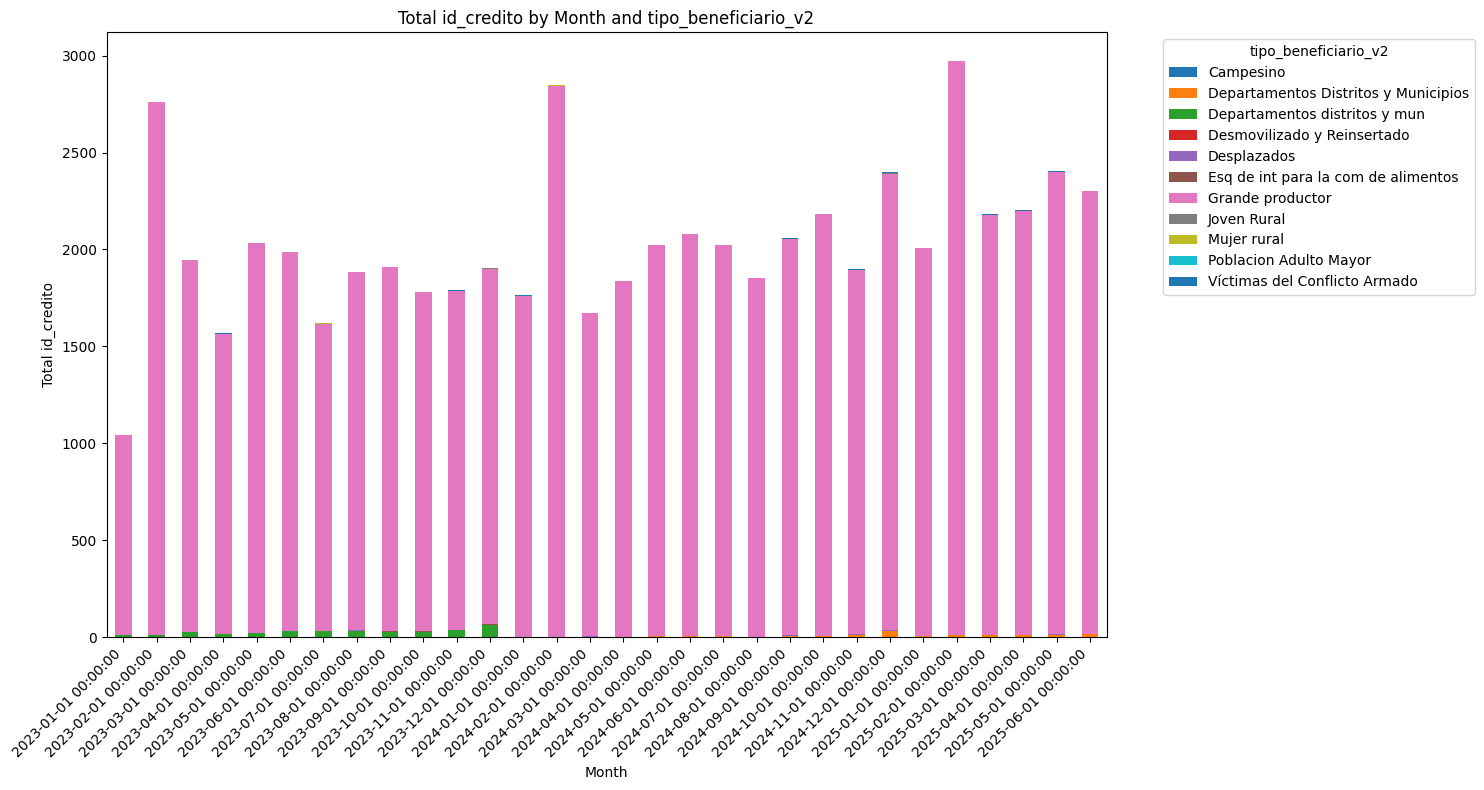

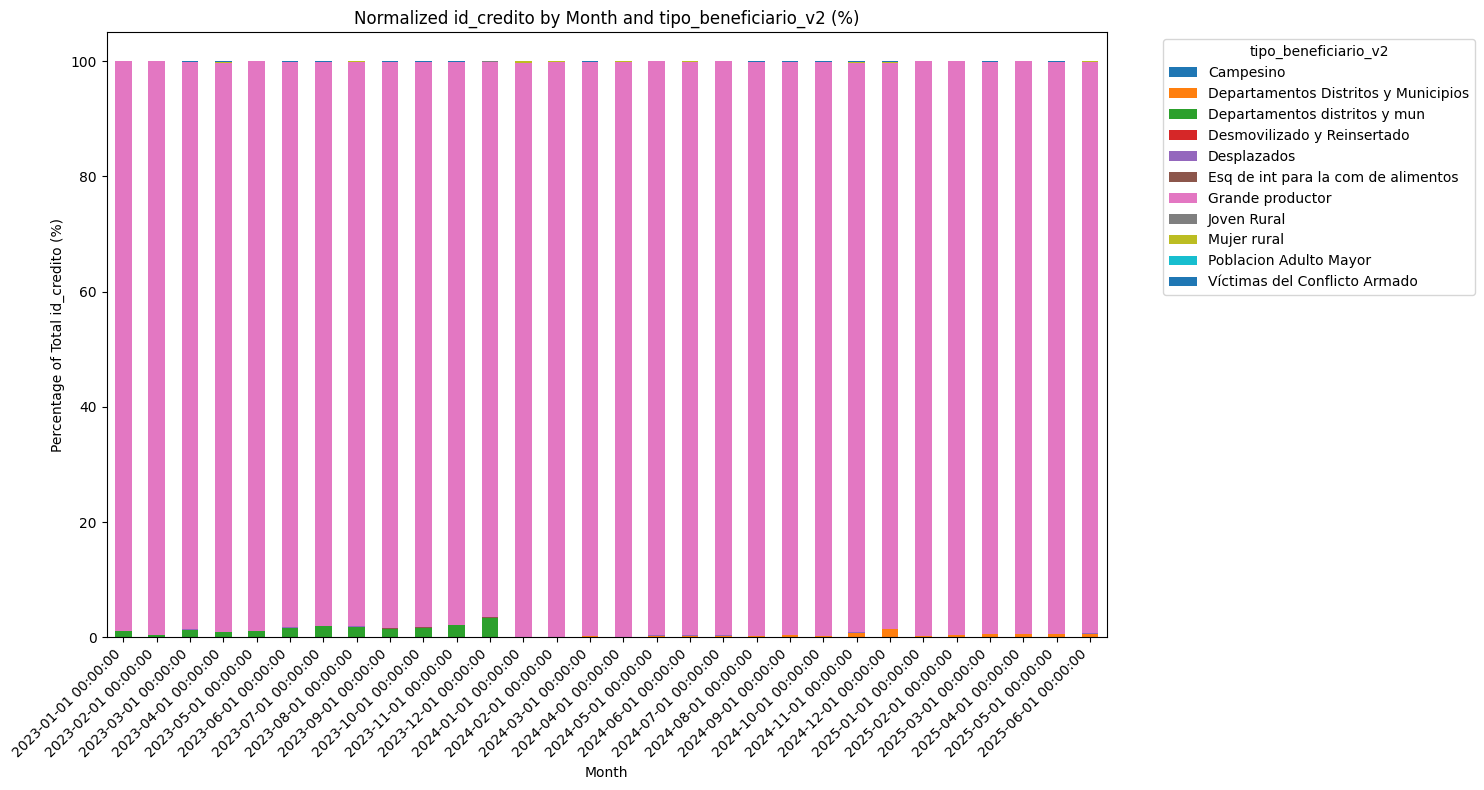

In [ ]:
plot_monthly_categorical_distribution(df_pandas.query("tipo_productor == 'Grande'"), 'tipo_beneficiario_v2', 'valor_credito')
plot_monthly_categorical_distribution(df_pandas.query("tipo_productor == 'Grande'"), 'tipo_beneficiario_v2', 'id_credito')

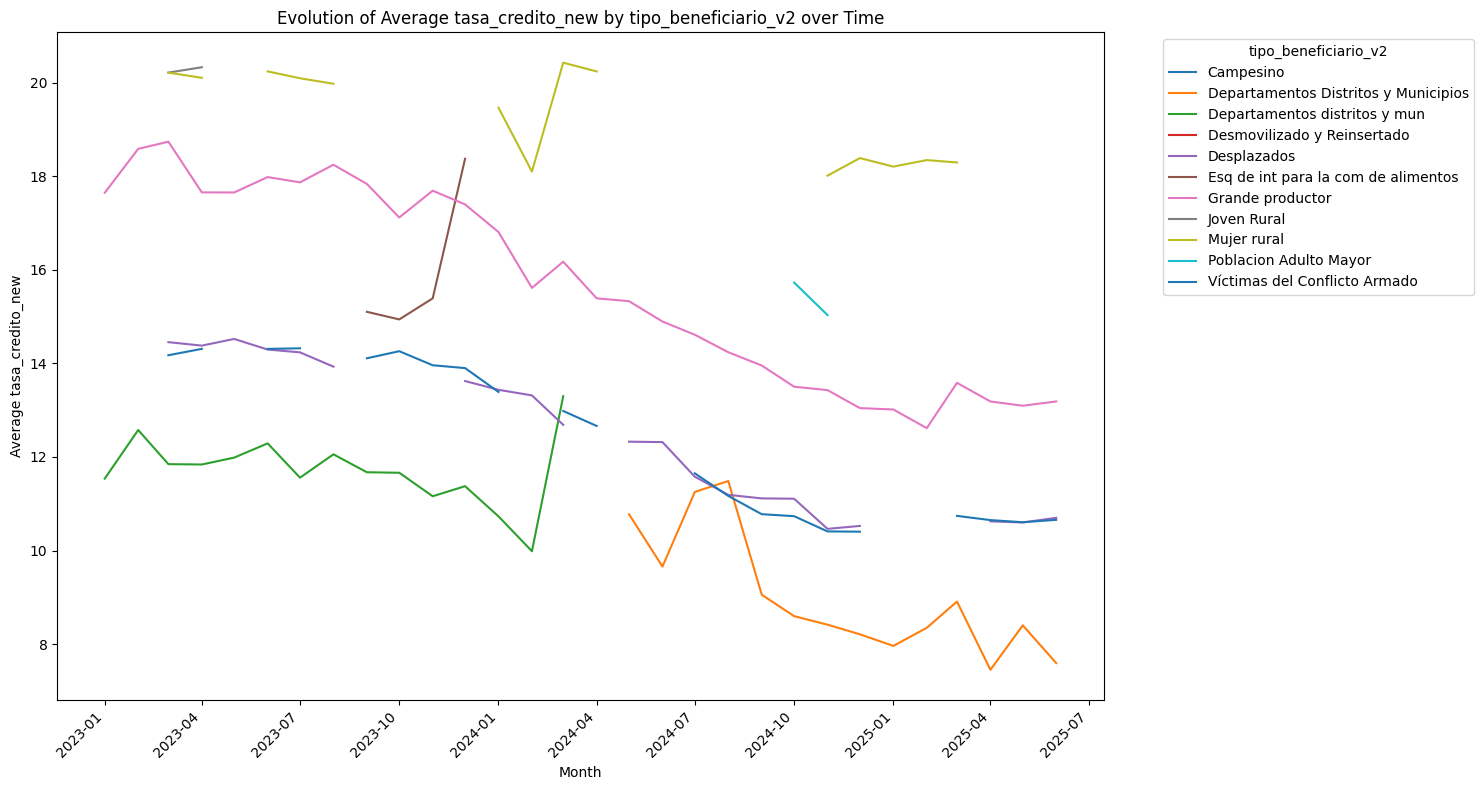

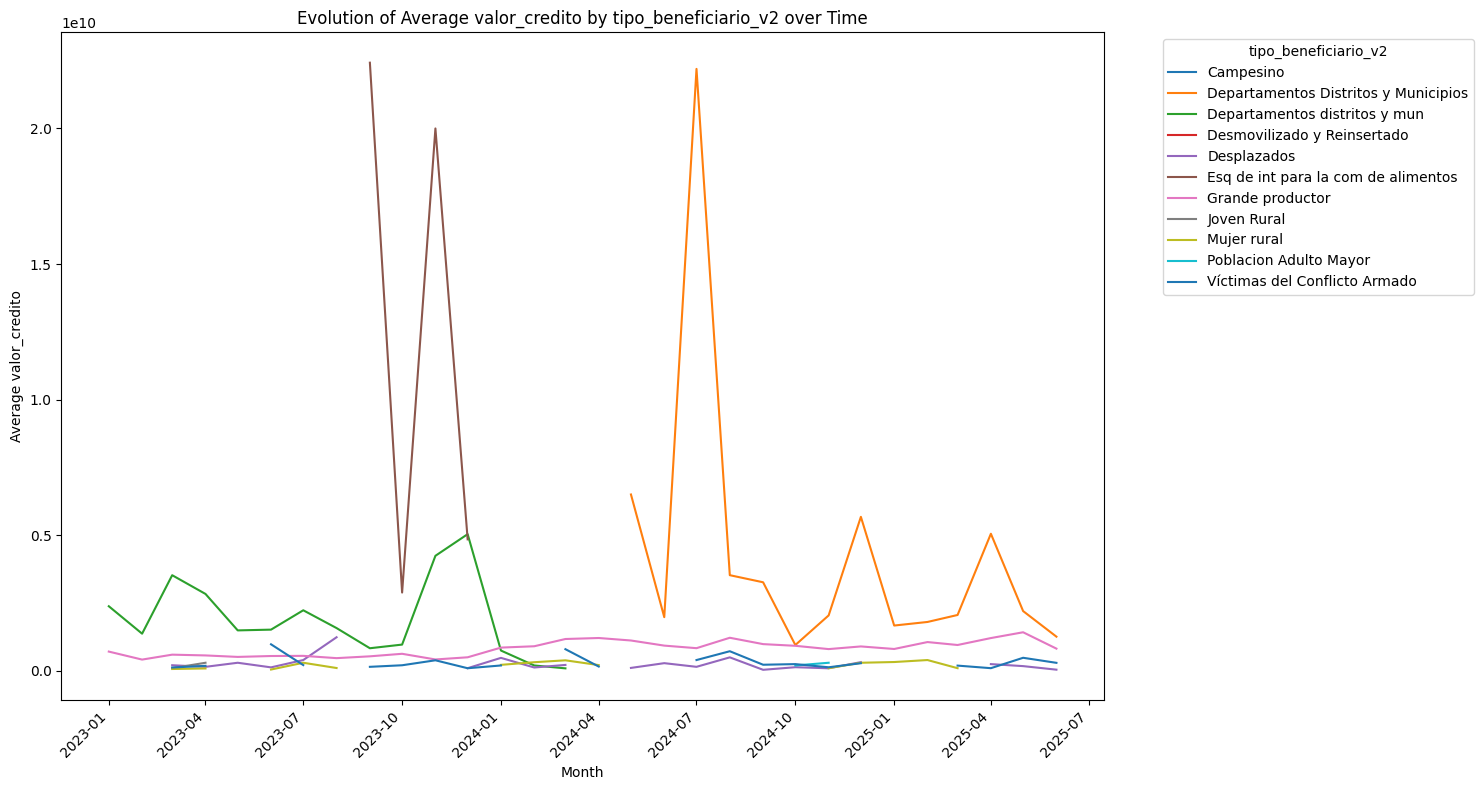

In [ ]:
plot_monthly_numerical_variable(df_pandas.query("tipo_productor == 'Grande'"), 'tasa_credito_new', 'tipo_beneficiario_v2')
plot_monthly_numerical_variable(df_pandas.query("tipo_productor == 'Grande'"), 'valor_credito', 'tipo_beneficiario_v2')

## Solo mediano productor

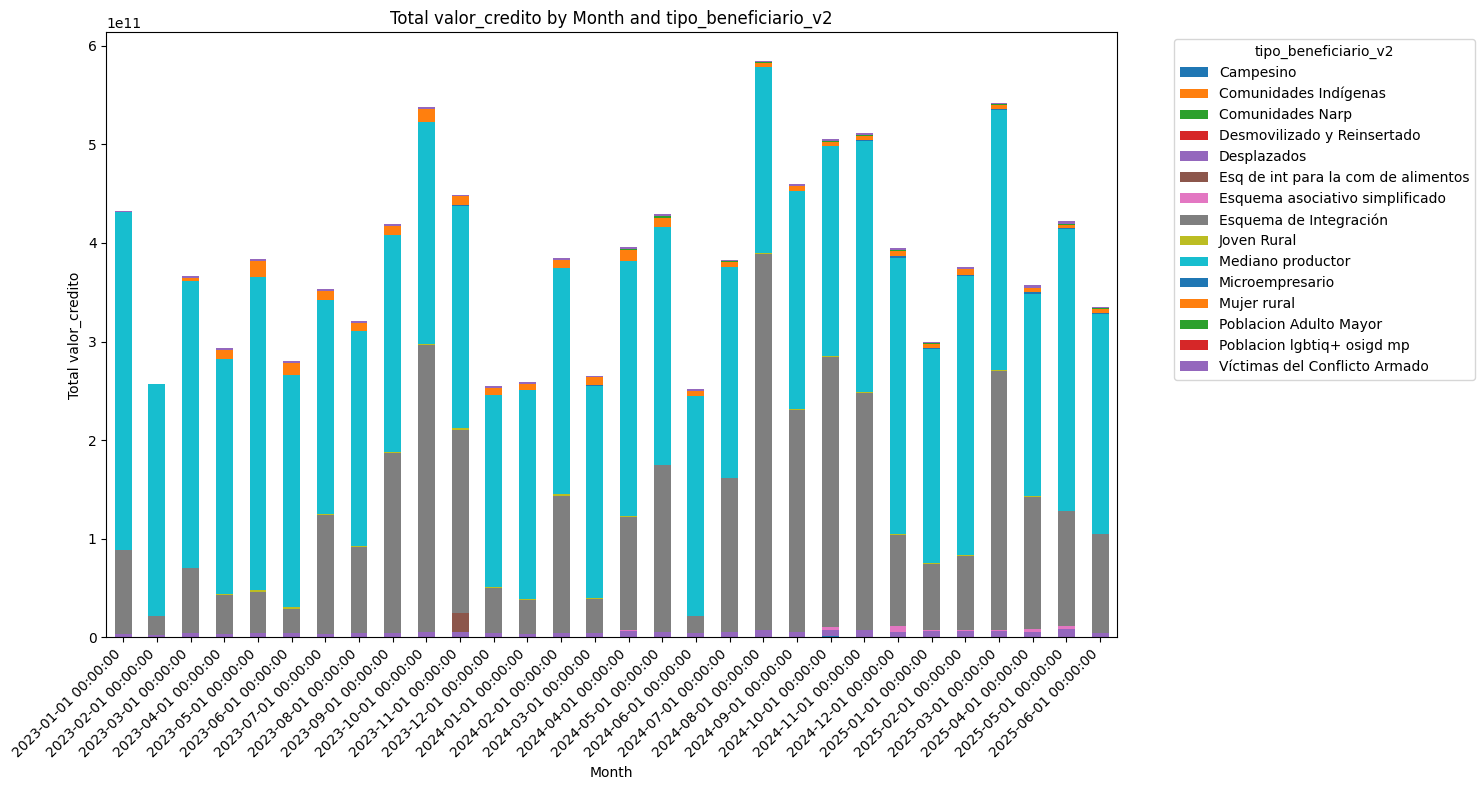

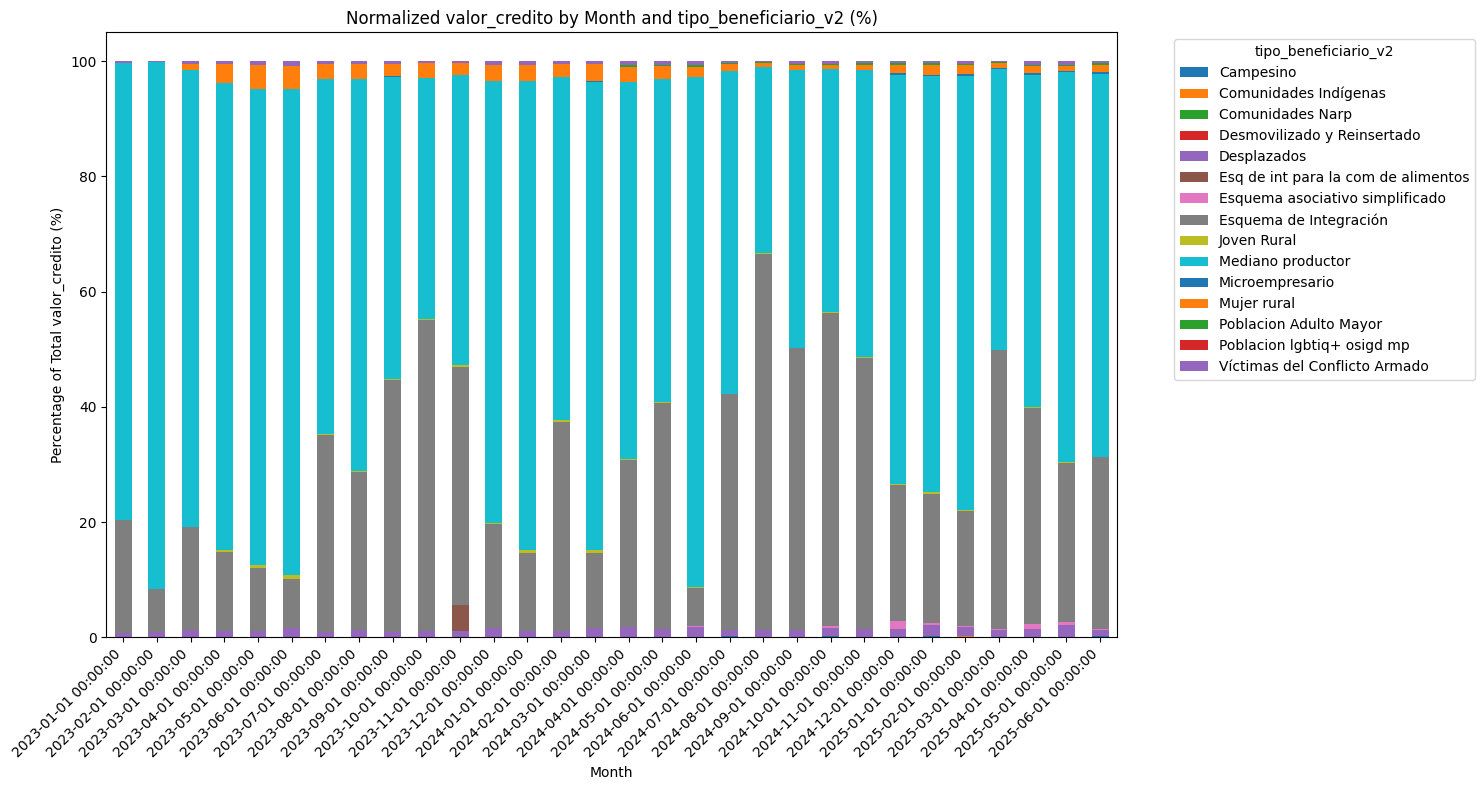

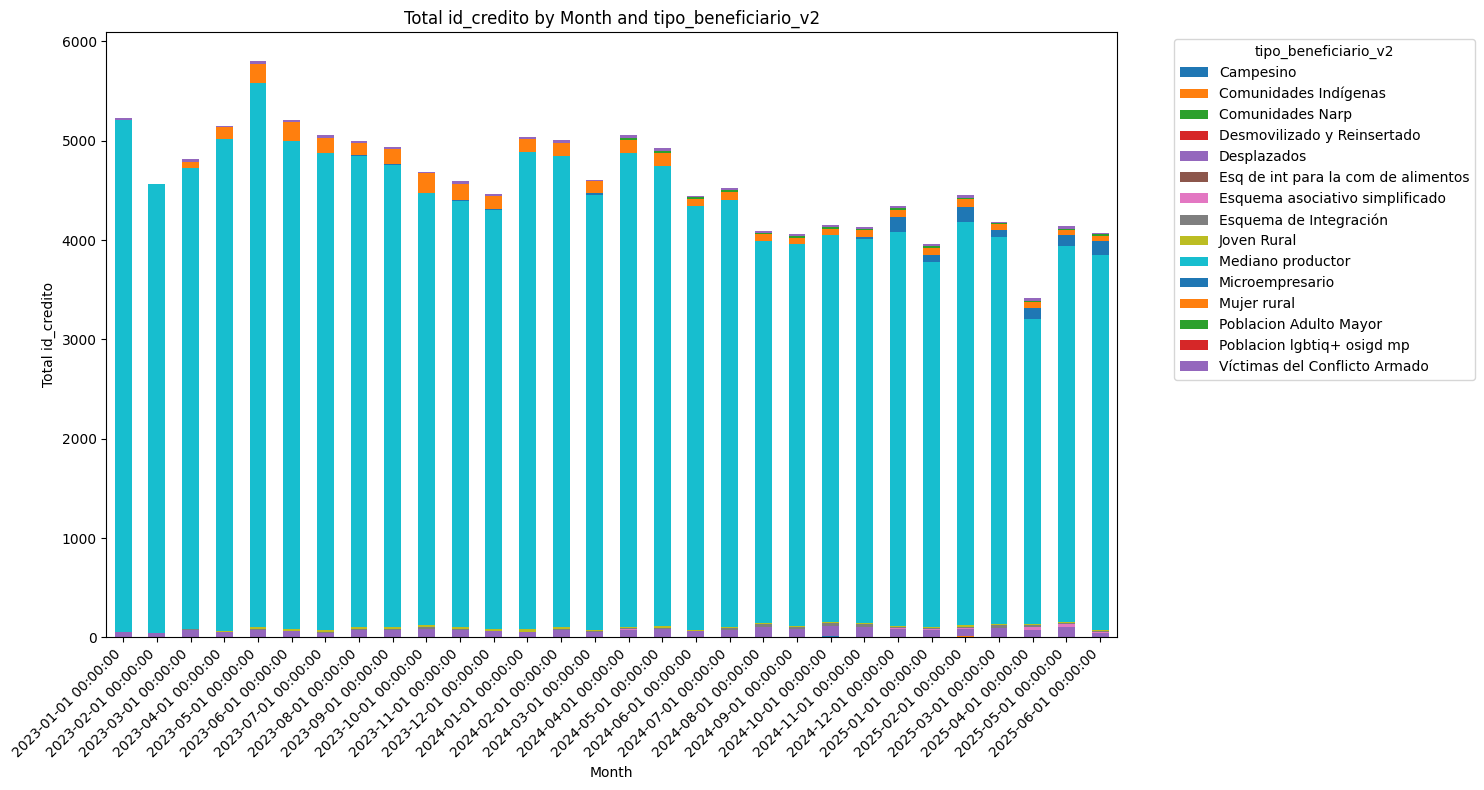

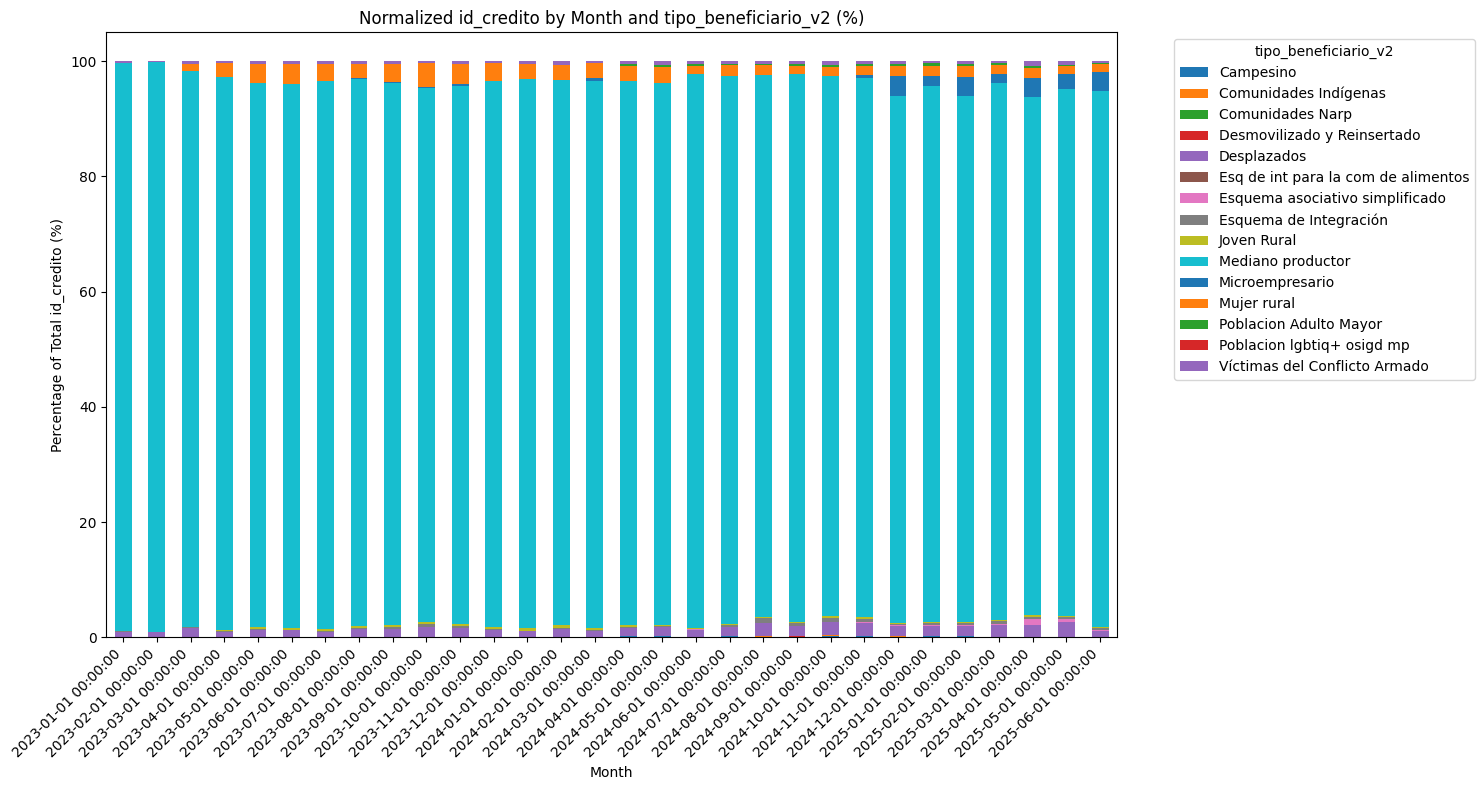

In [ ]:
plot_monthly_categorical_distribution(df_pandas.query("tipo_productor == 'Mediano'"), 'tipo_beneficiario_v2', 'valor_credito')
plot_monthly_categorical_distribution(df_pandas.query("tipo_productor == 'Mediano'"), 'tipo_beneficiario_v2', 'id_credito')

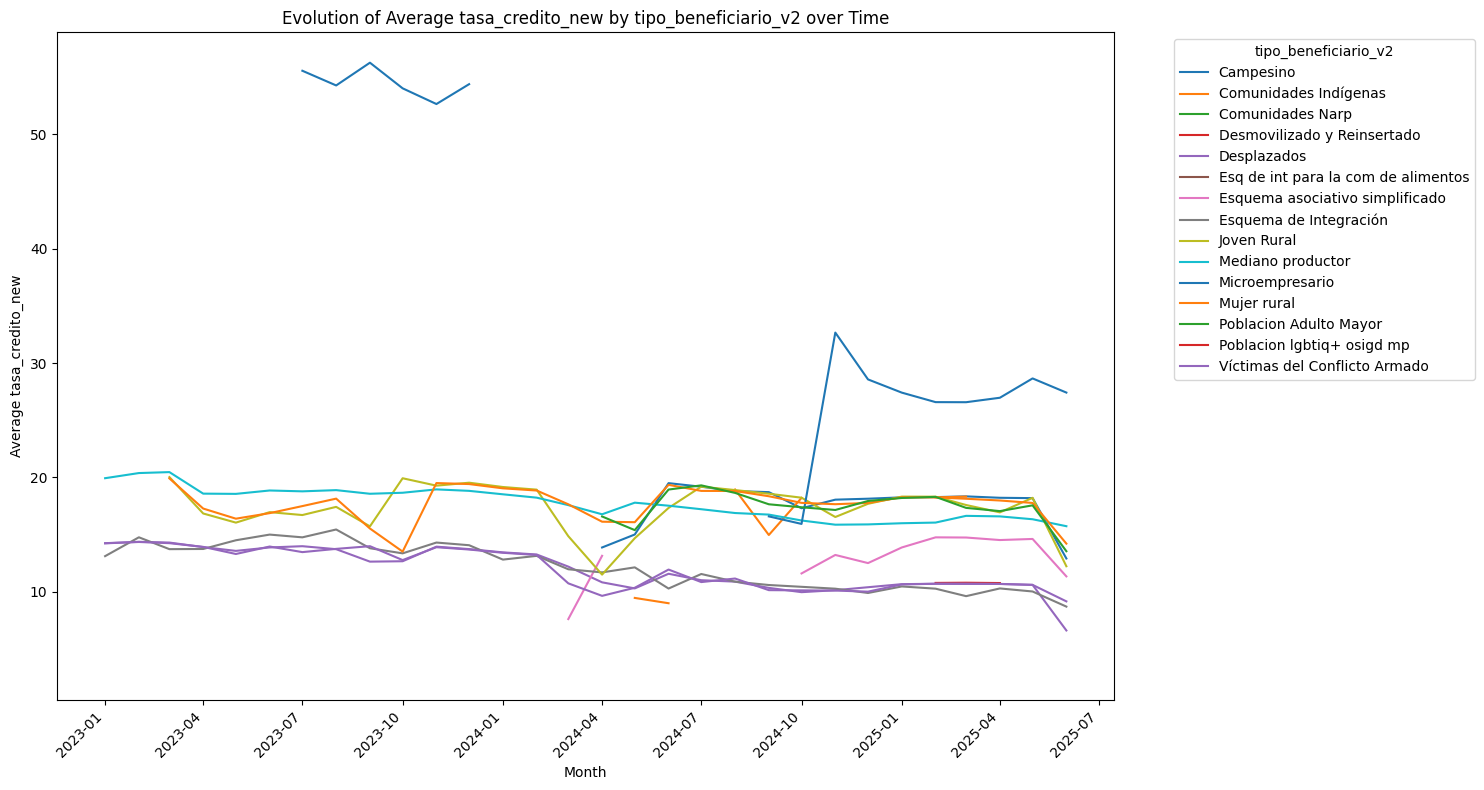

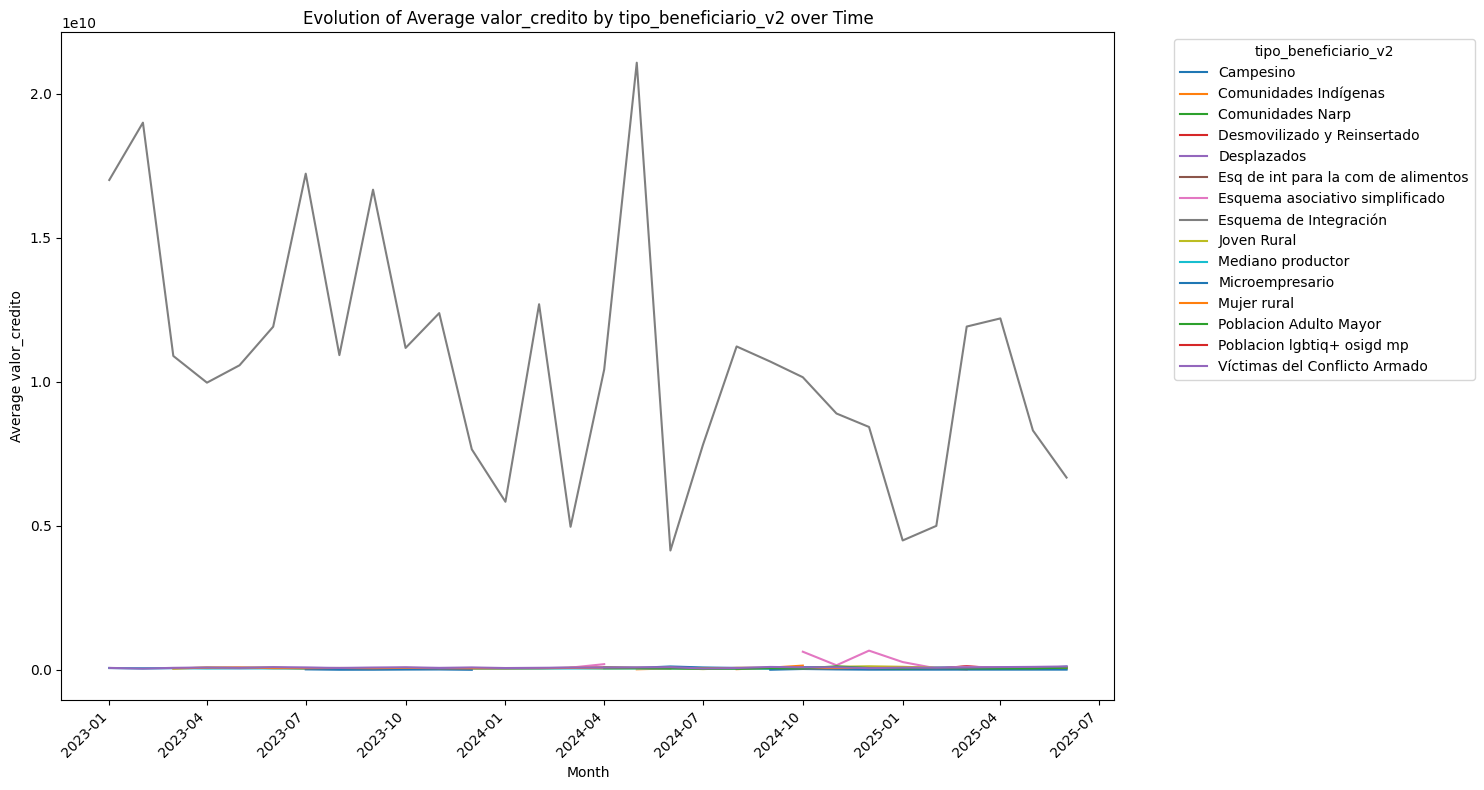

In [ ]:
plot_monthly_numerical_variable(df_pandas.query("tipo_productor == 'Mediano'"), 'tasa_credito_new', 'tipo_beneficiario_v2')
plot_monthly_numerical_variable(df_pandas.query("tipo_productor == 'Mediano'"), 'valor_credito', 'tipo_beneficiario_v2')

Sin esquema de integración

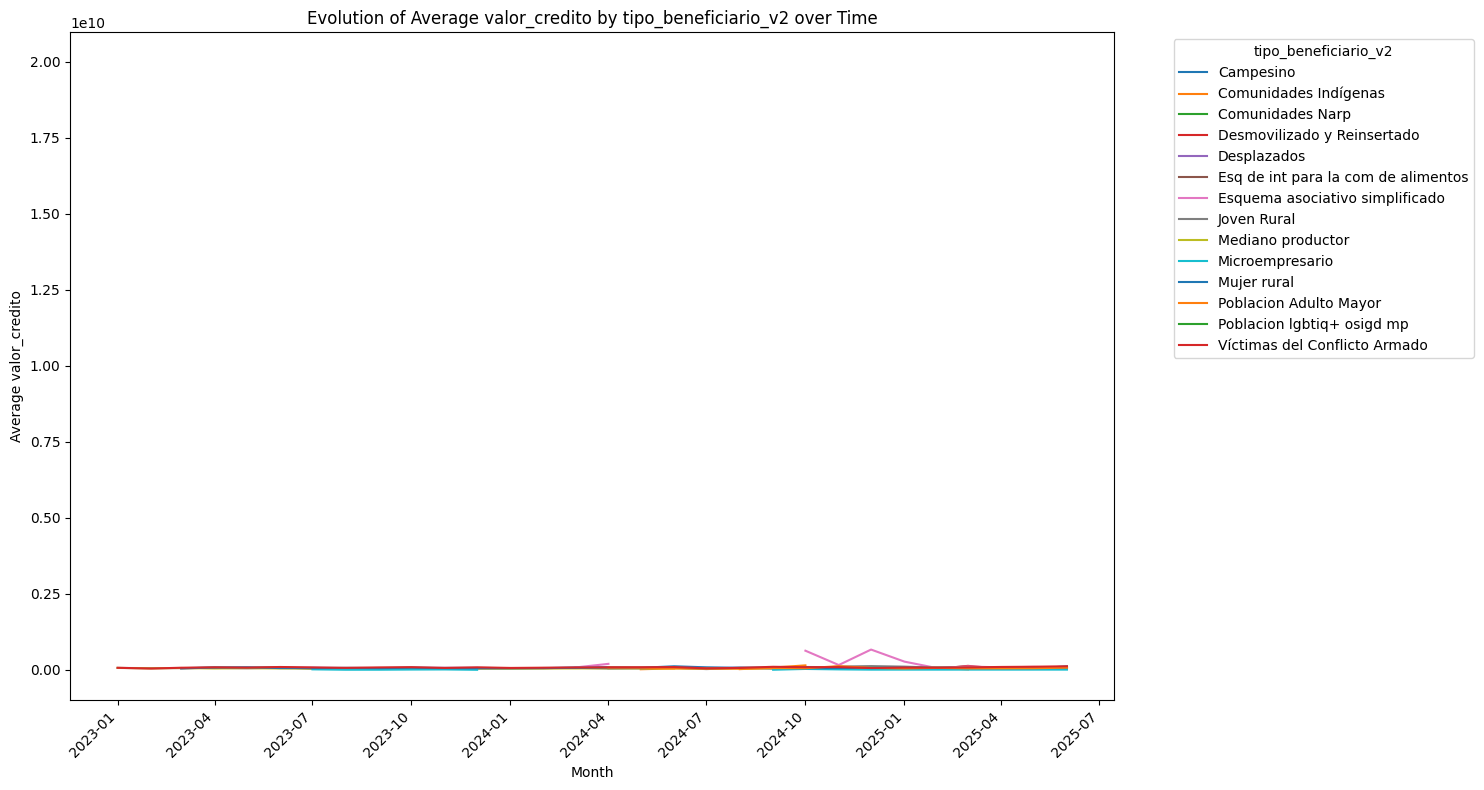

In [ ]:
df_mediano = df_pandas.query("tipo_productor == 'Mediano' and tipo_beneficiario_v2 != 'Esquema de Integración'")

plot_monthly_numerical_variable(df_mediano, 'valor_credito', 'tipo_beneficiario_v2')

## Zoom Microempresario

In [ ]:
df_microempresario = df_pandas.query("tipo_beneficiario_v2 == 'Microempresario'")

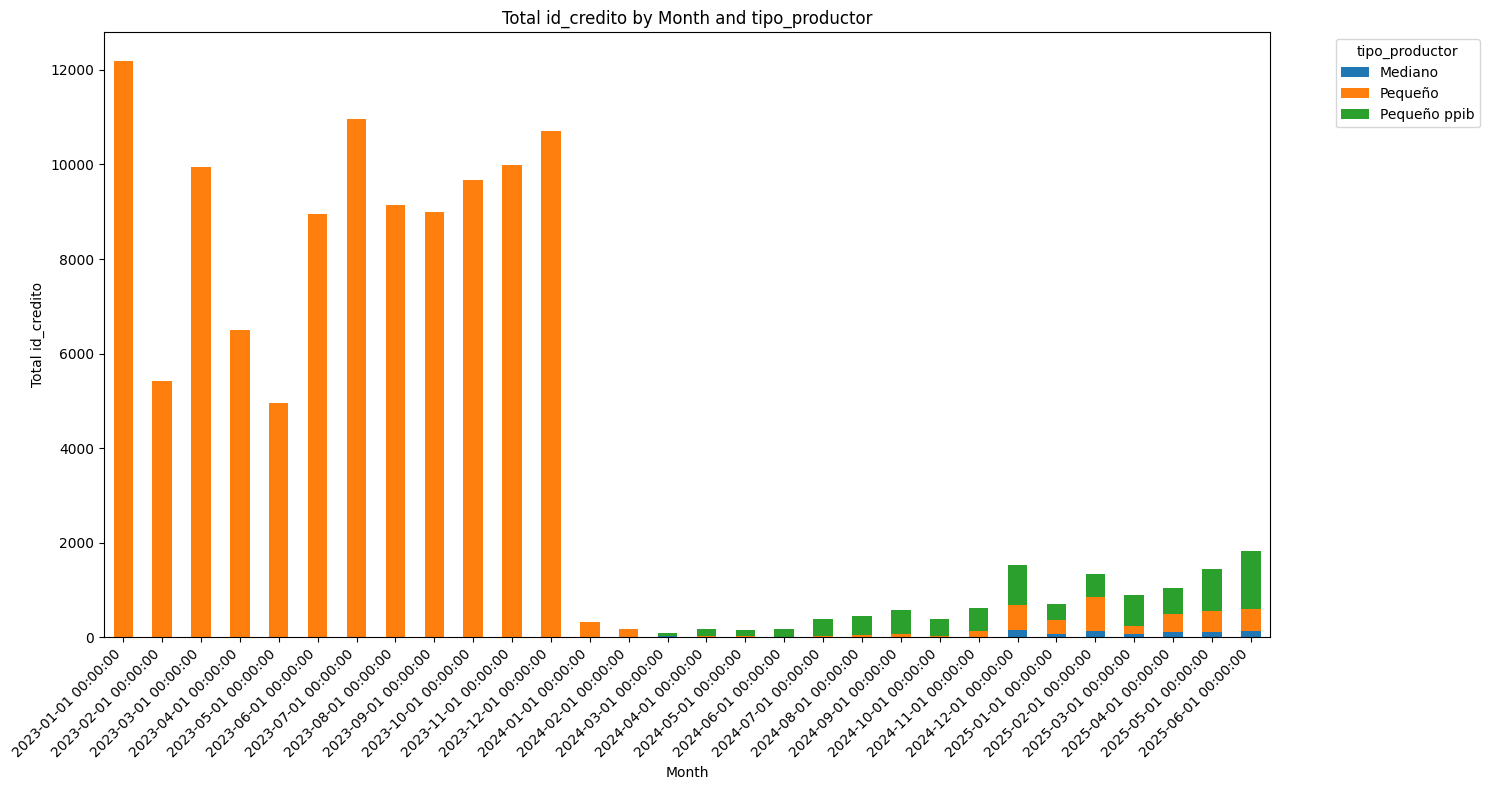

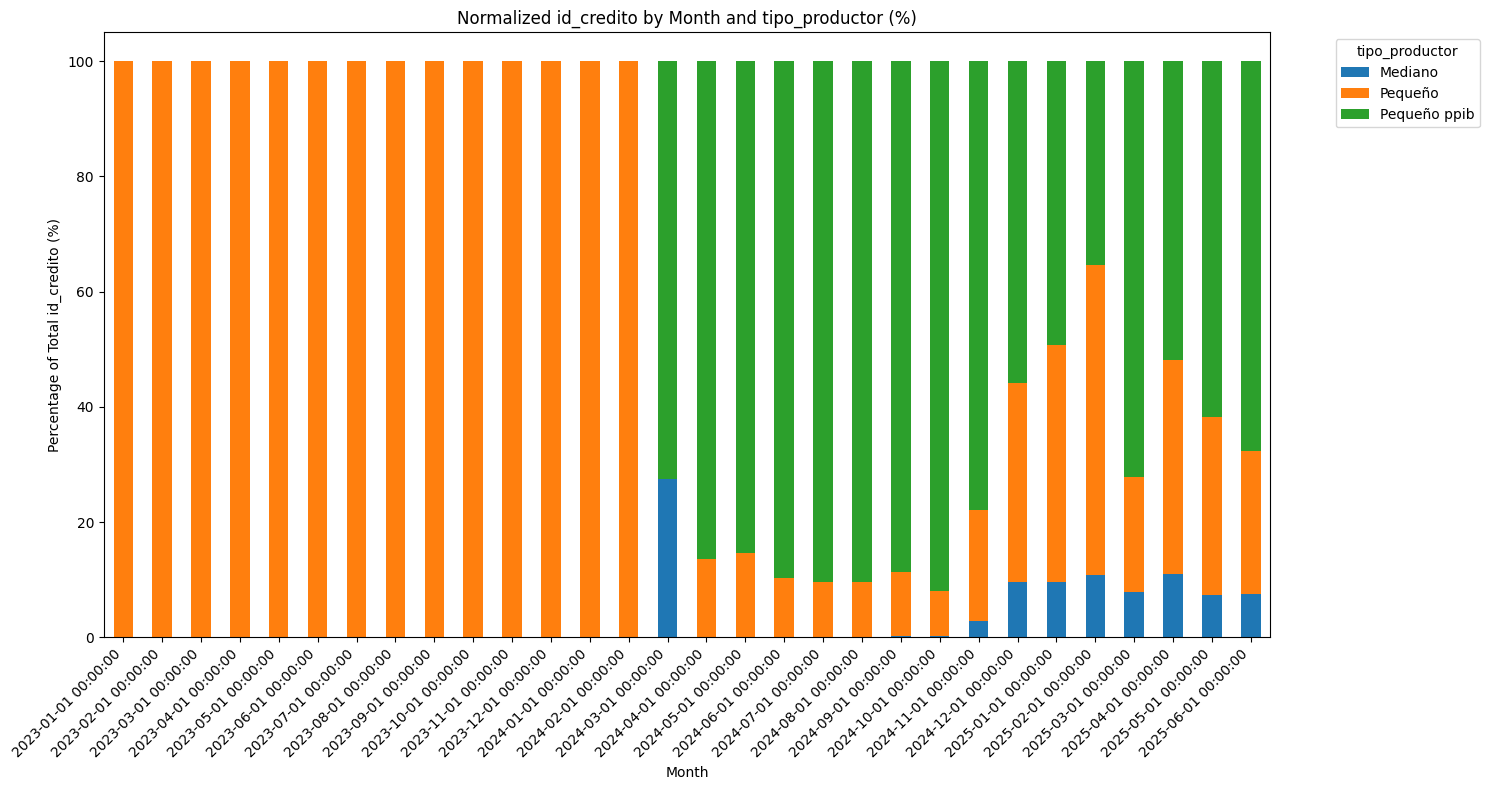

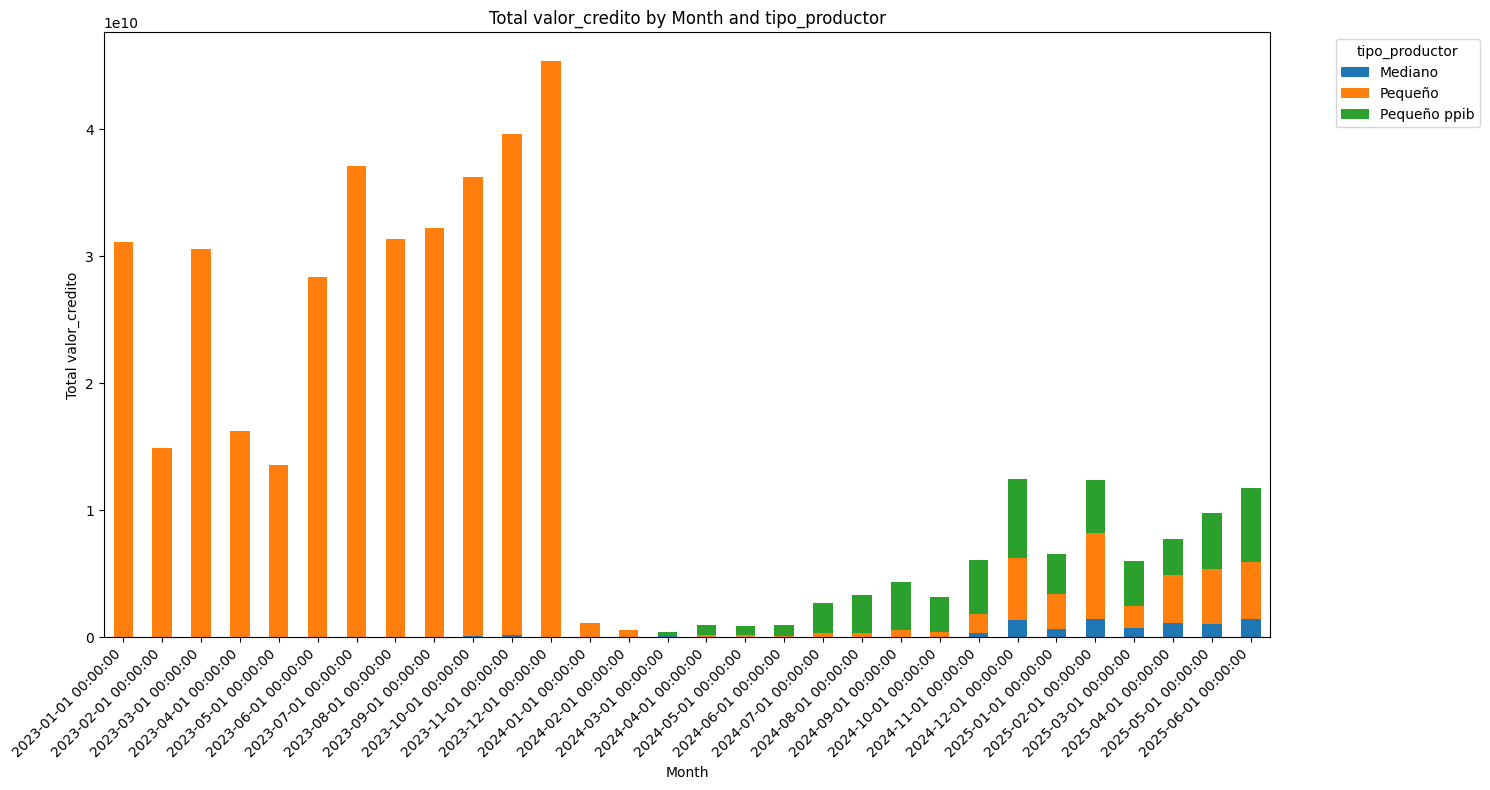

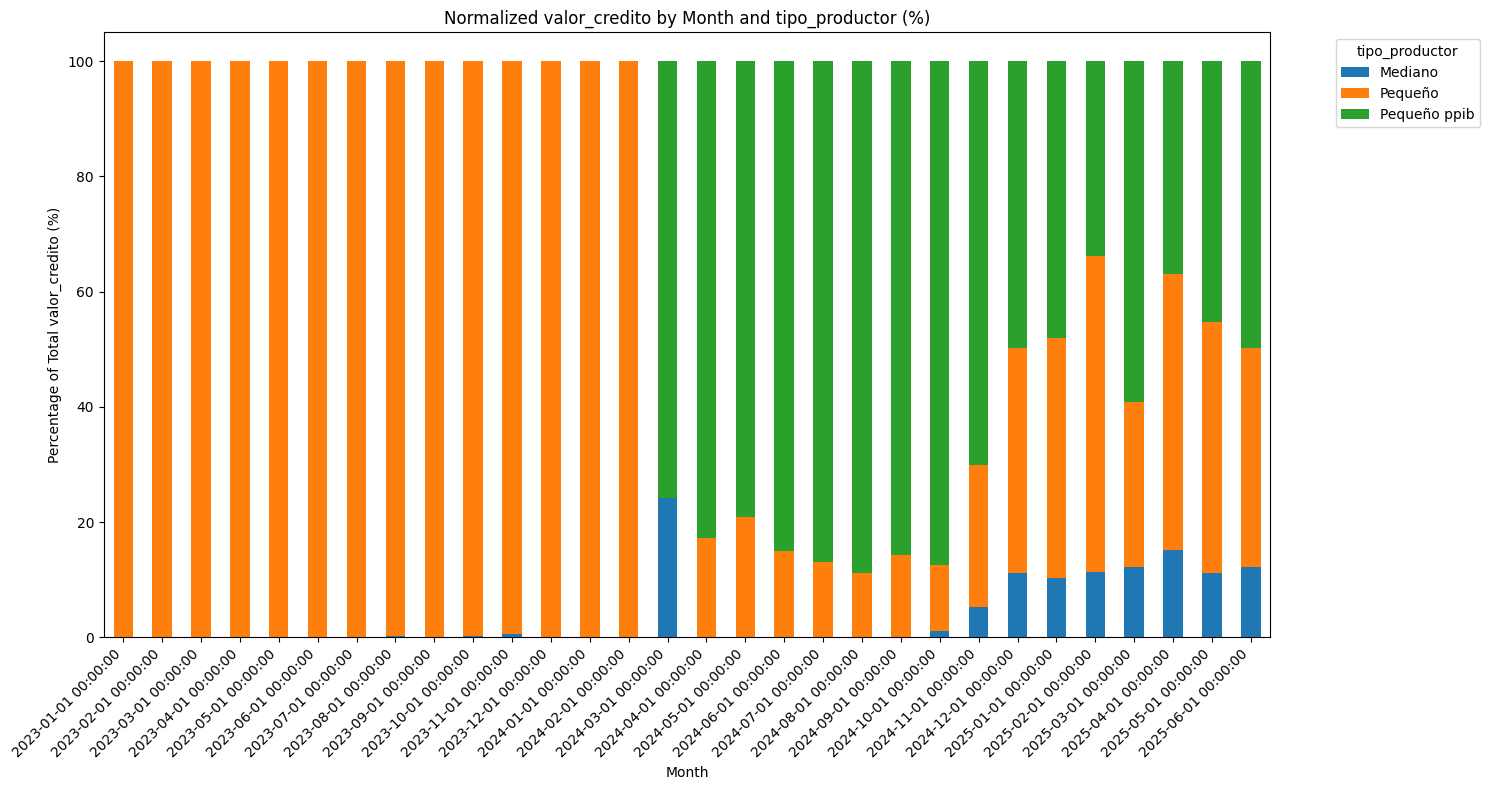

In [ ]:
plot_monthly_categorical_distribution(df_microempresario, 'tipo_productor', 'id_credito')
plot_monthly_categorical_distribution(df_microempresario, 'tipo_productor', 'valor_credito')

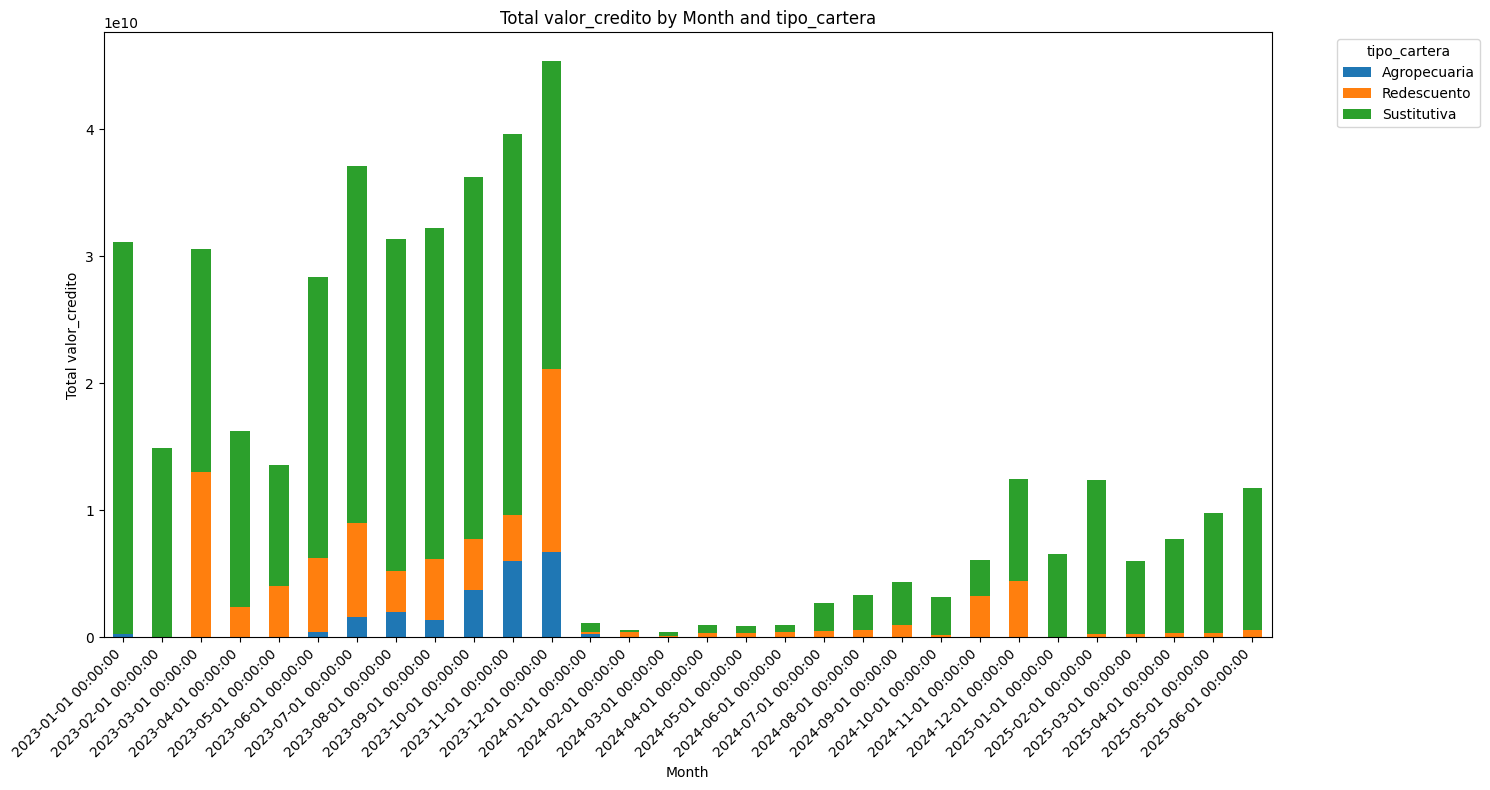

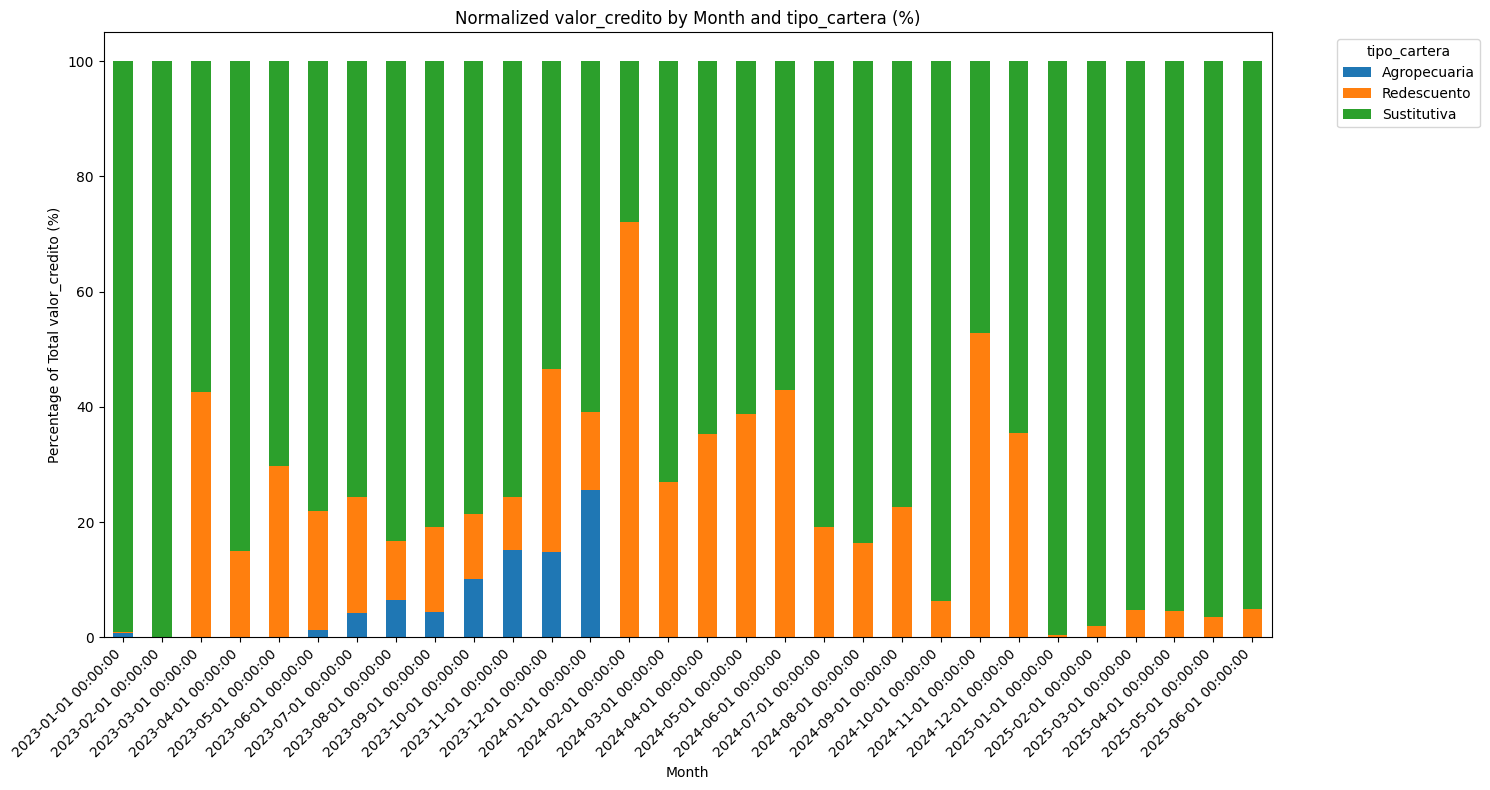

In [ ]:
plot_monthly_categorical_distribution(df_microempresario, 'tipo_cartera', 'valor_credito')

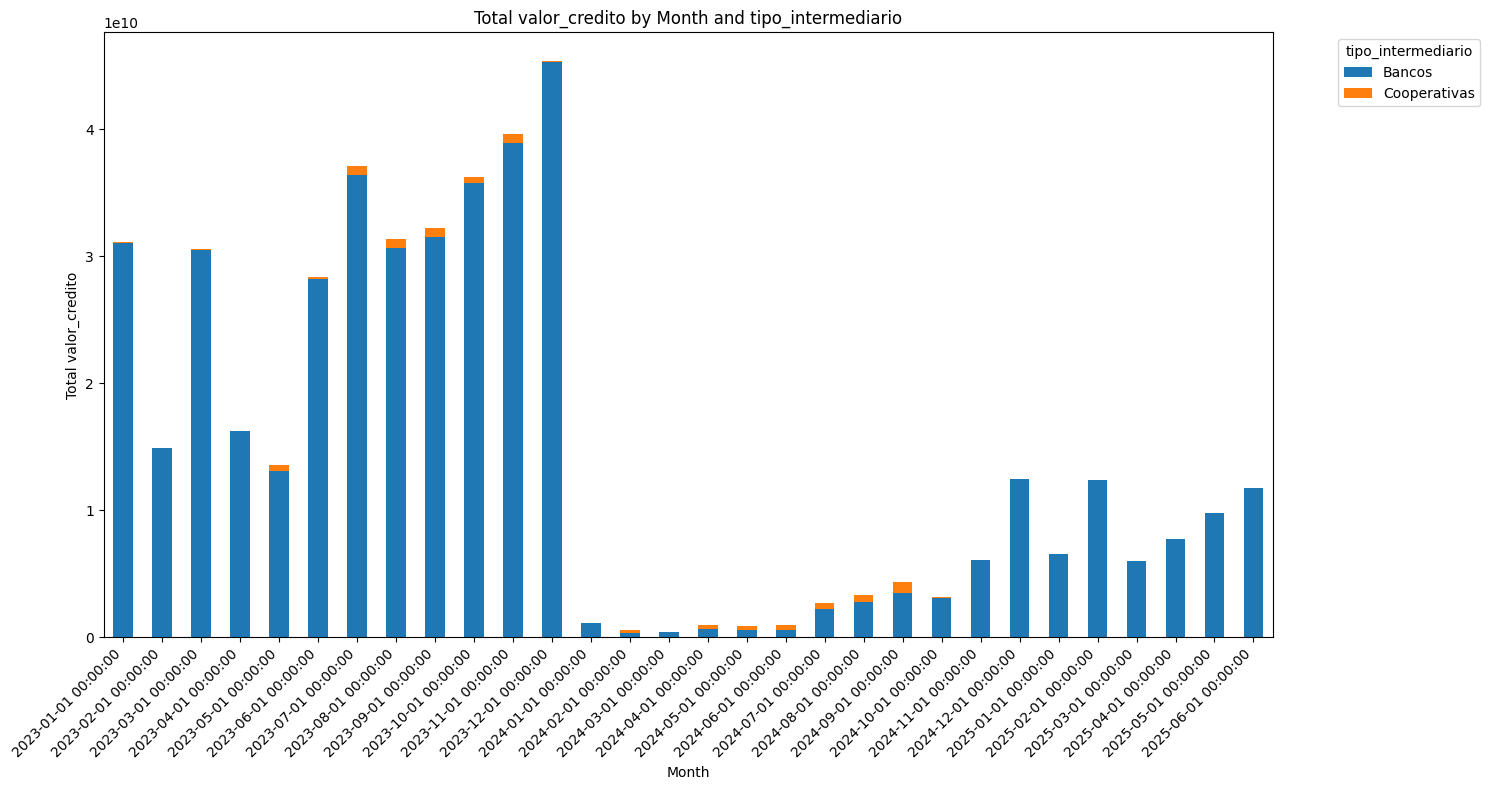

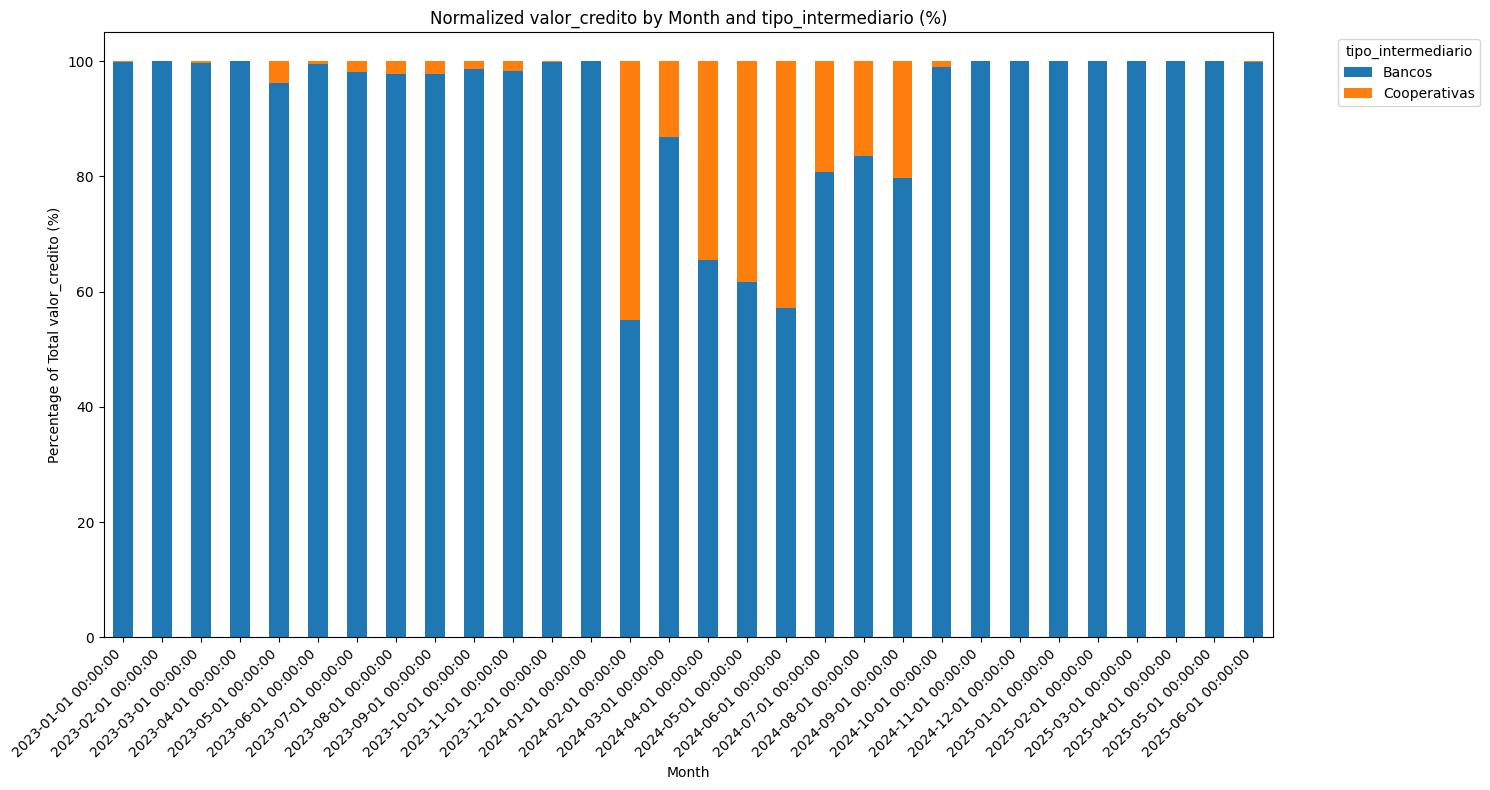

In [ ]:
plot_monthly_categorical_distribution(df_microempresario, 'tipo_intermediario', 'valor_credito')

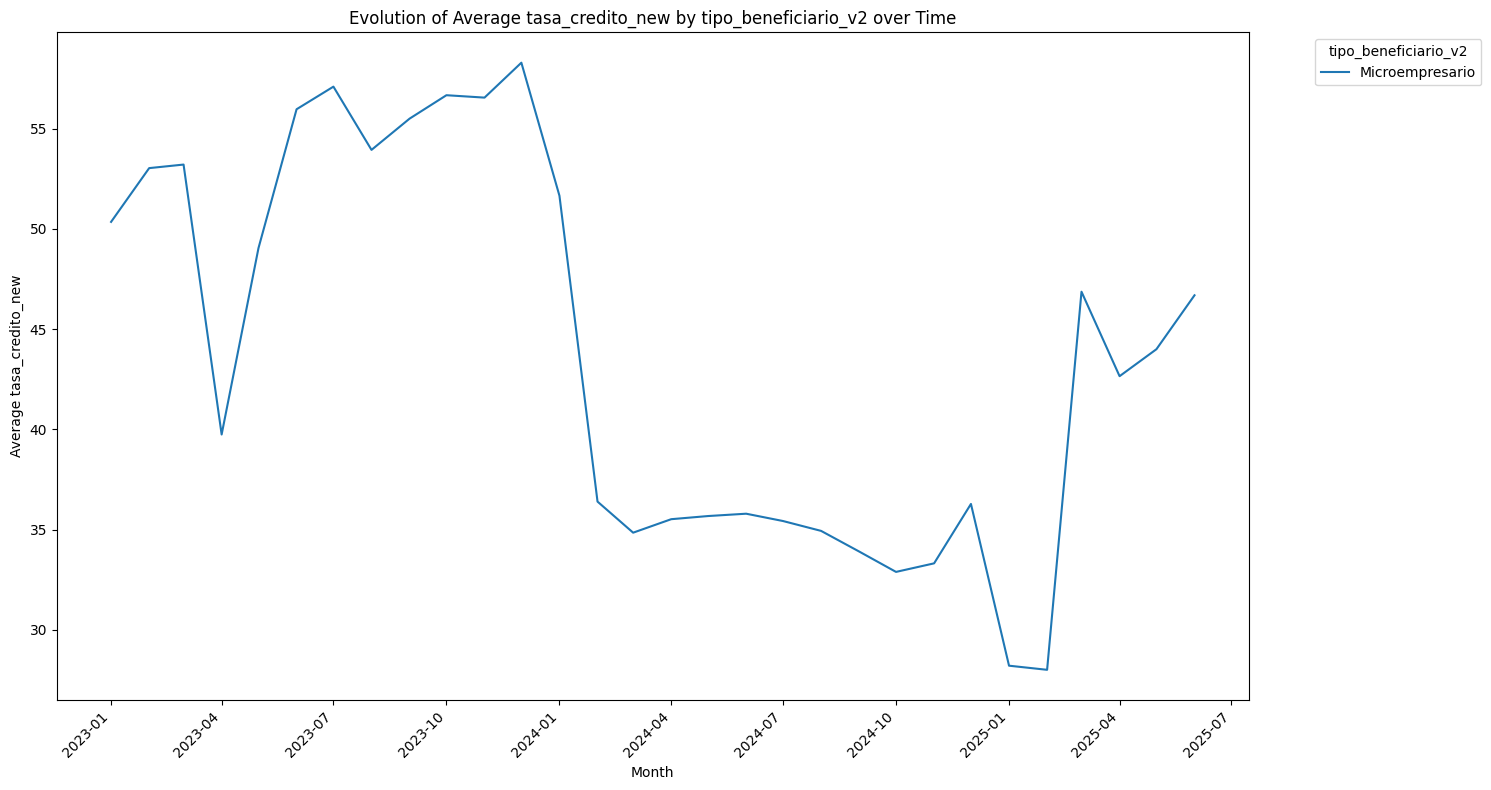

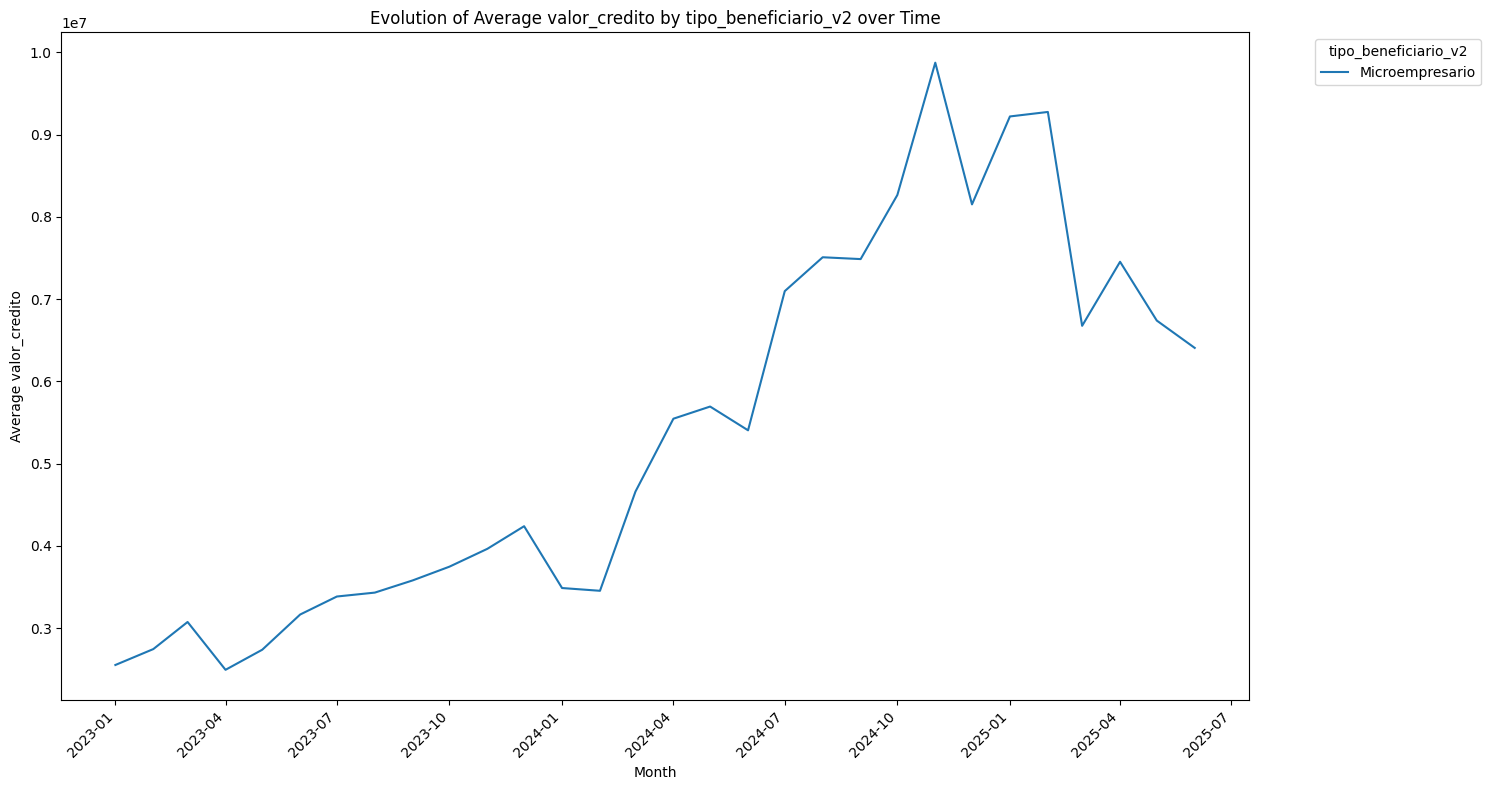

In [ ]:
plot_monthly_numerical_variable(df_microempresario, 'tasa_credito_new', 'tipo_beneficiario_v2')
plot_monthly_numerical_variable(df_microempresario, 'valor_credito', 'tipo_beneficiario_v2')

/tmp/ipython-input-2345882279.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


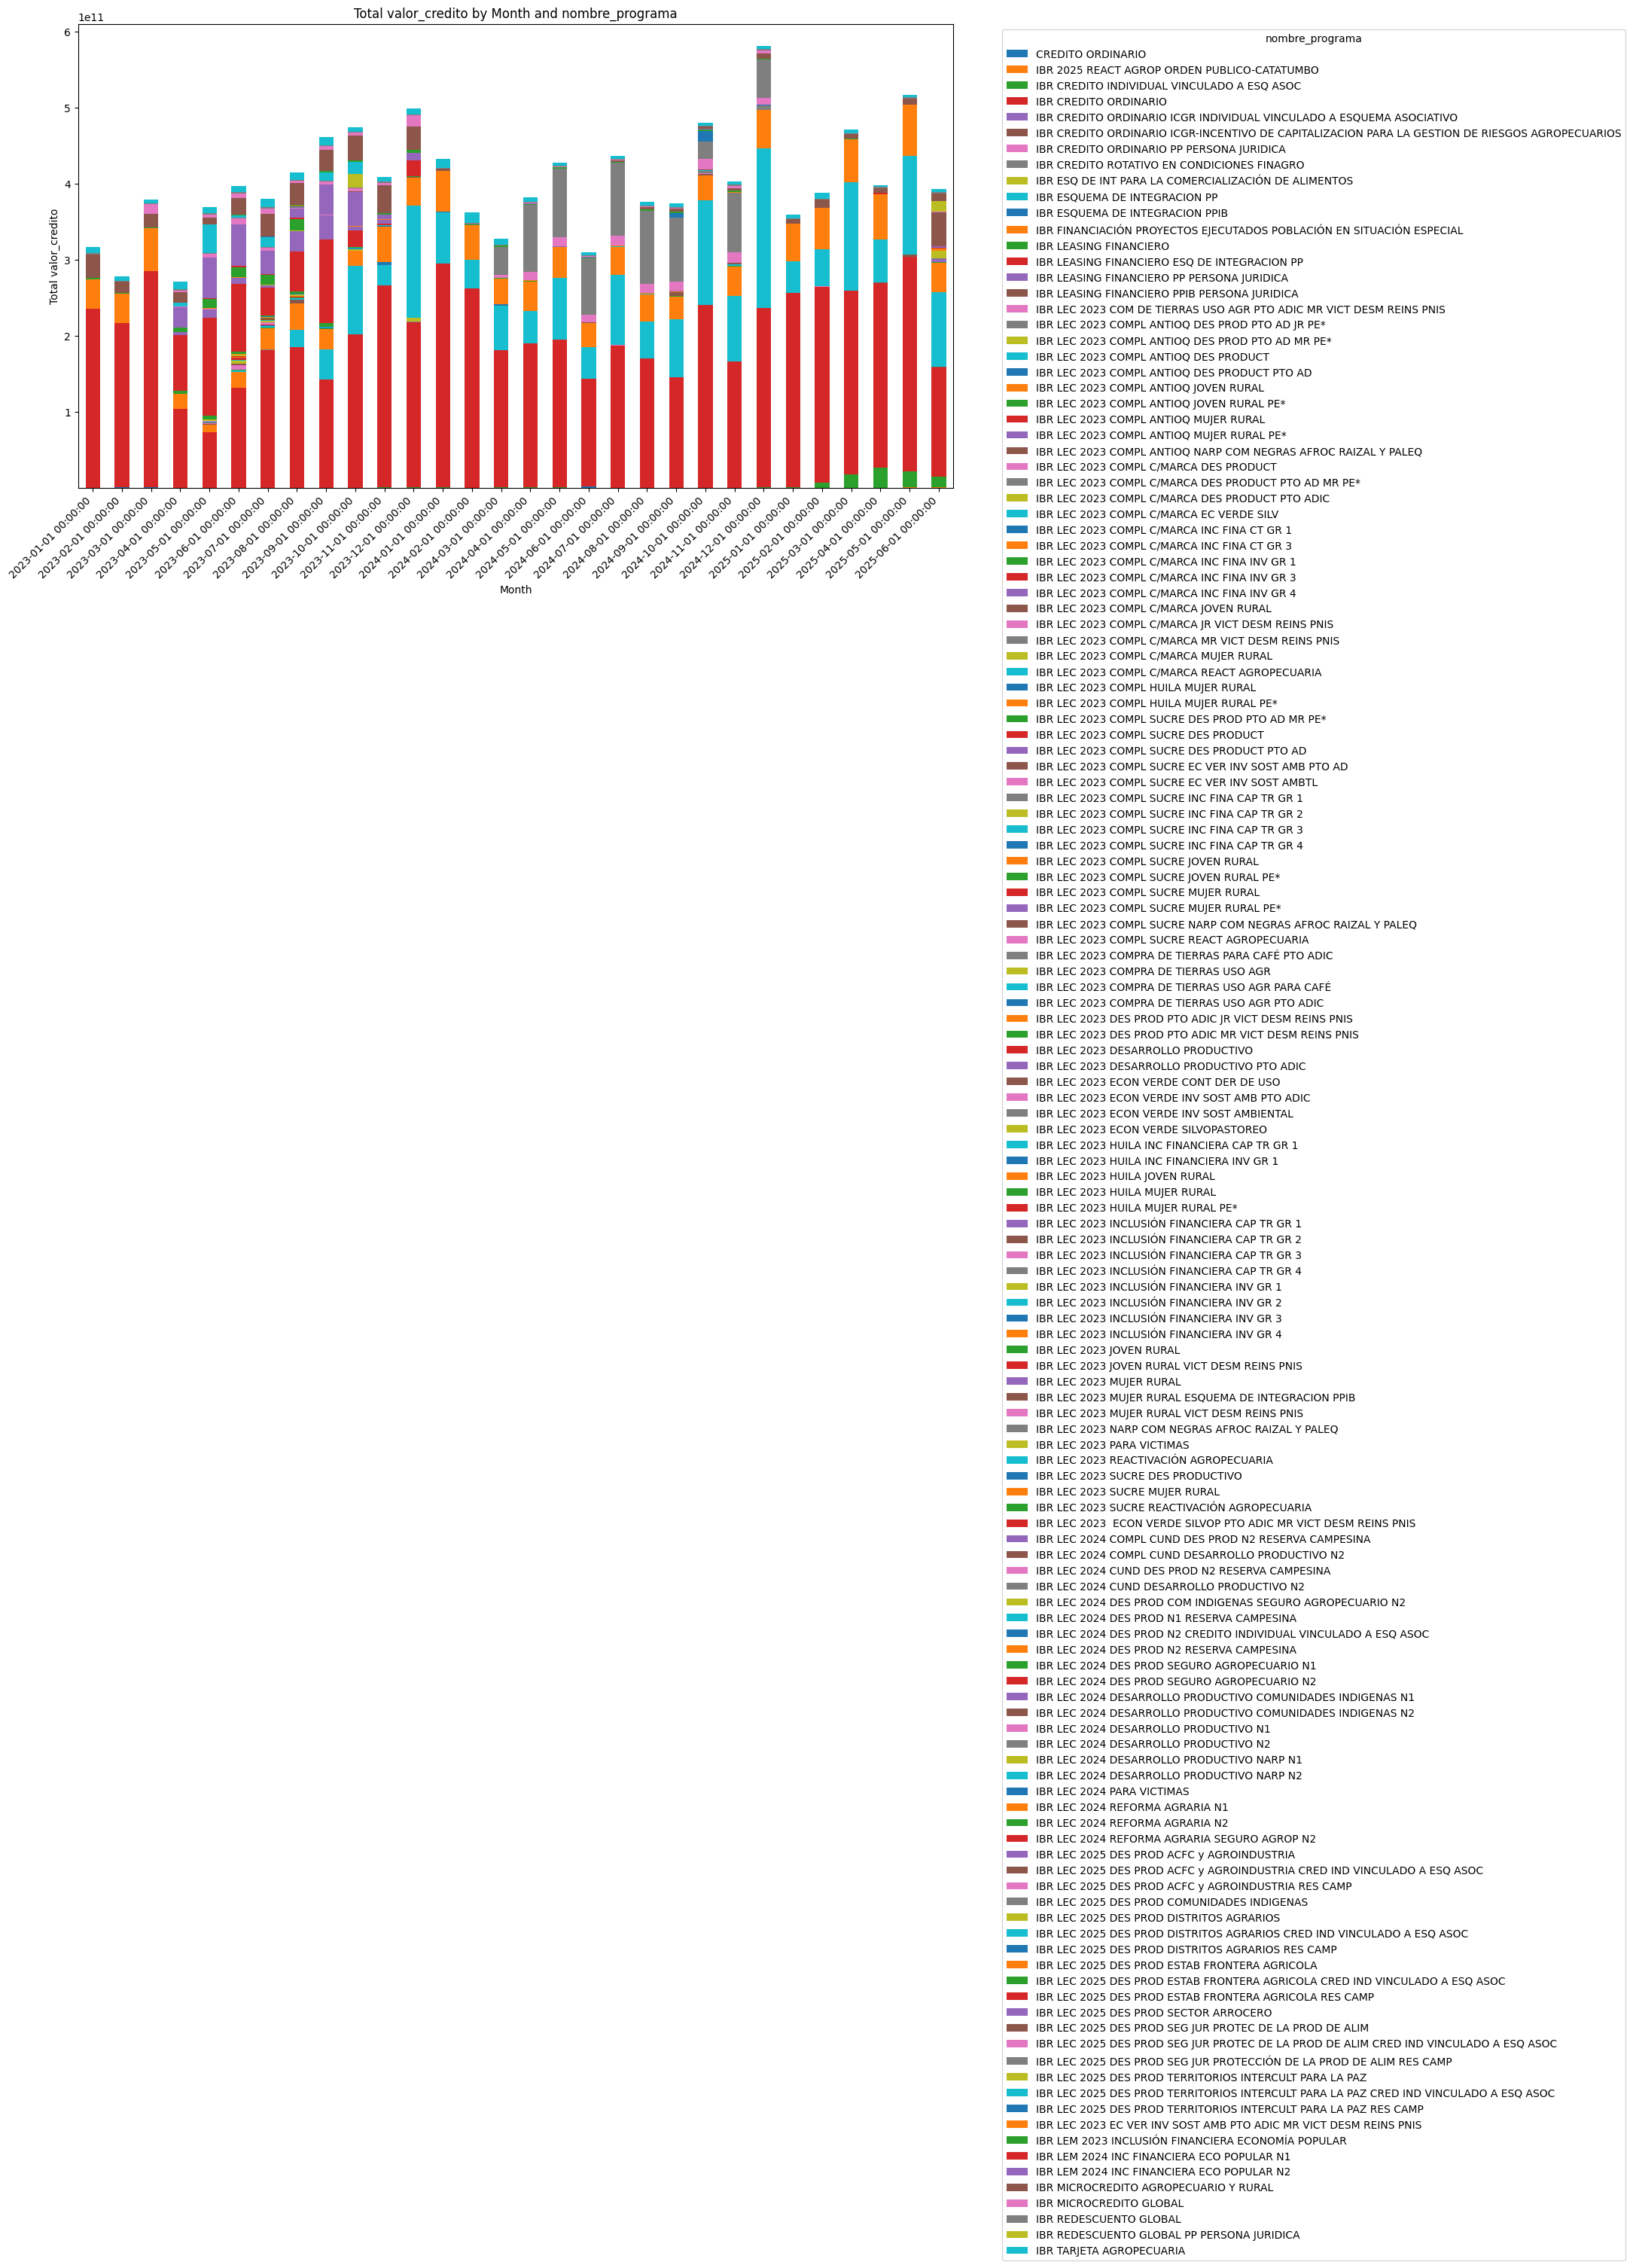

/tmp/ipython-input-2345882279.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


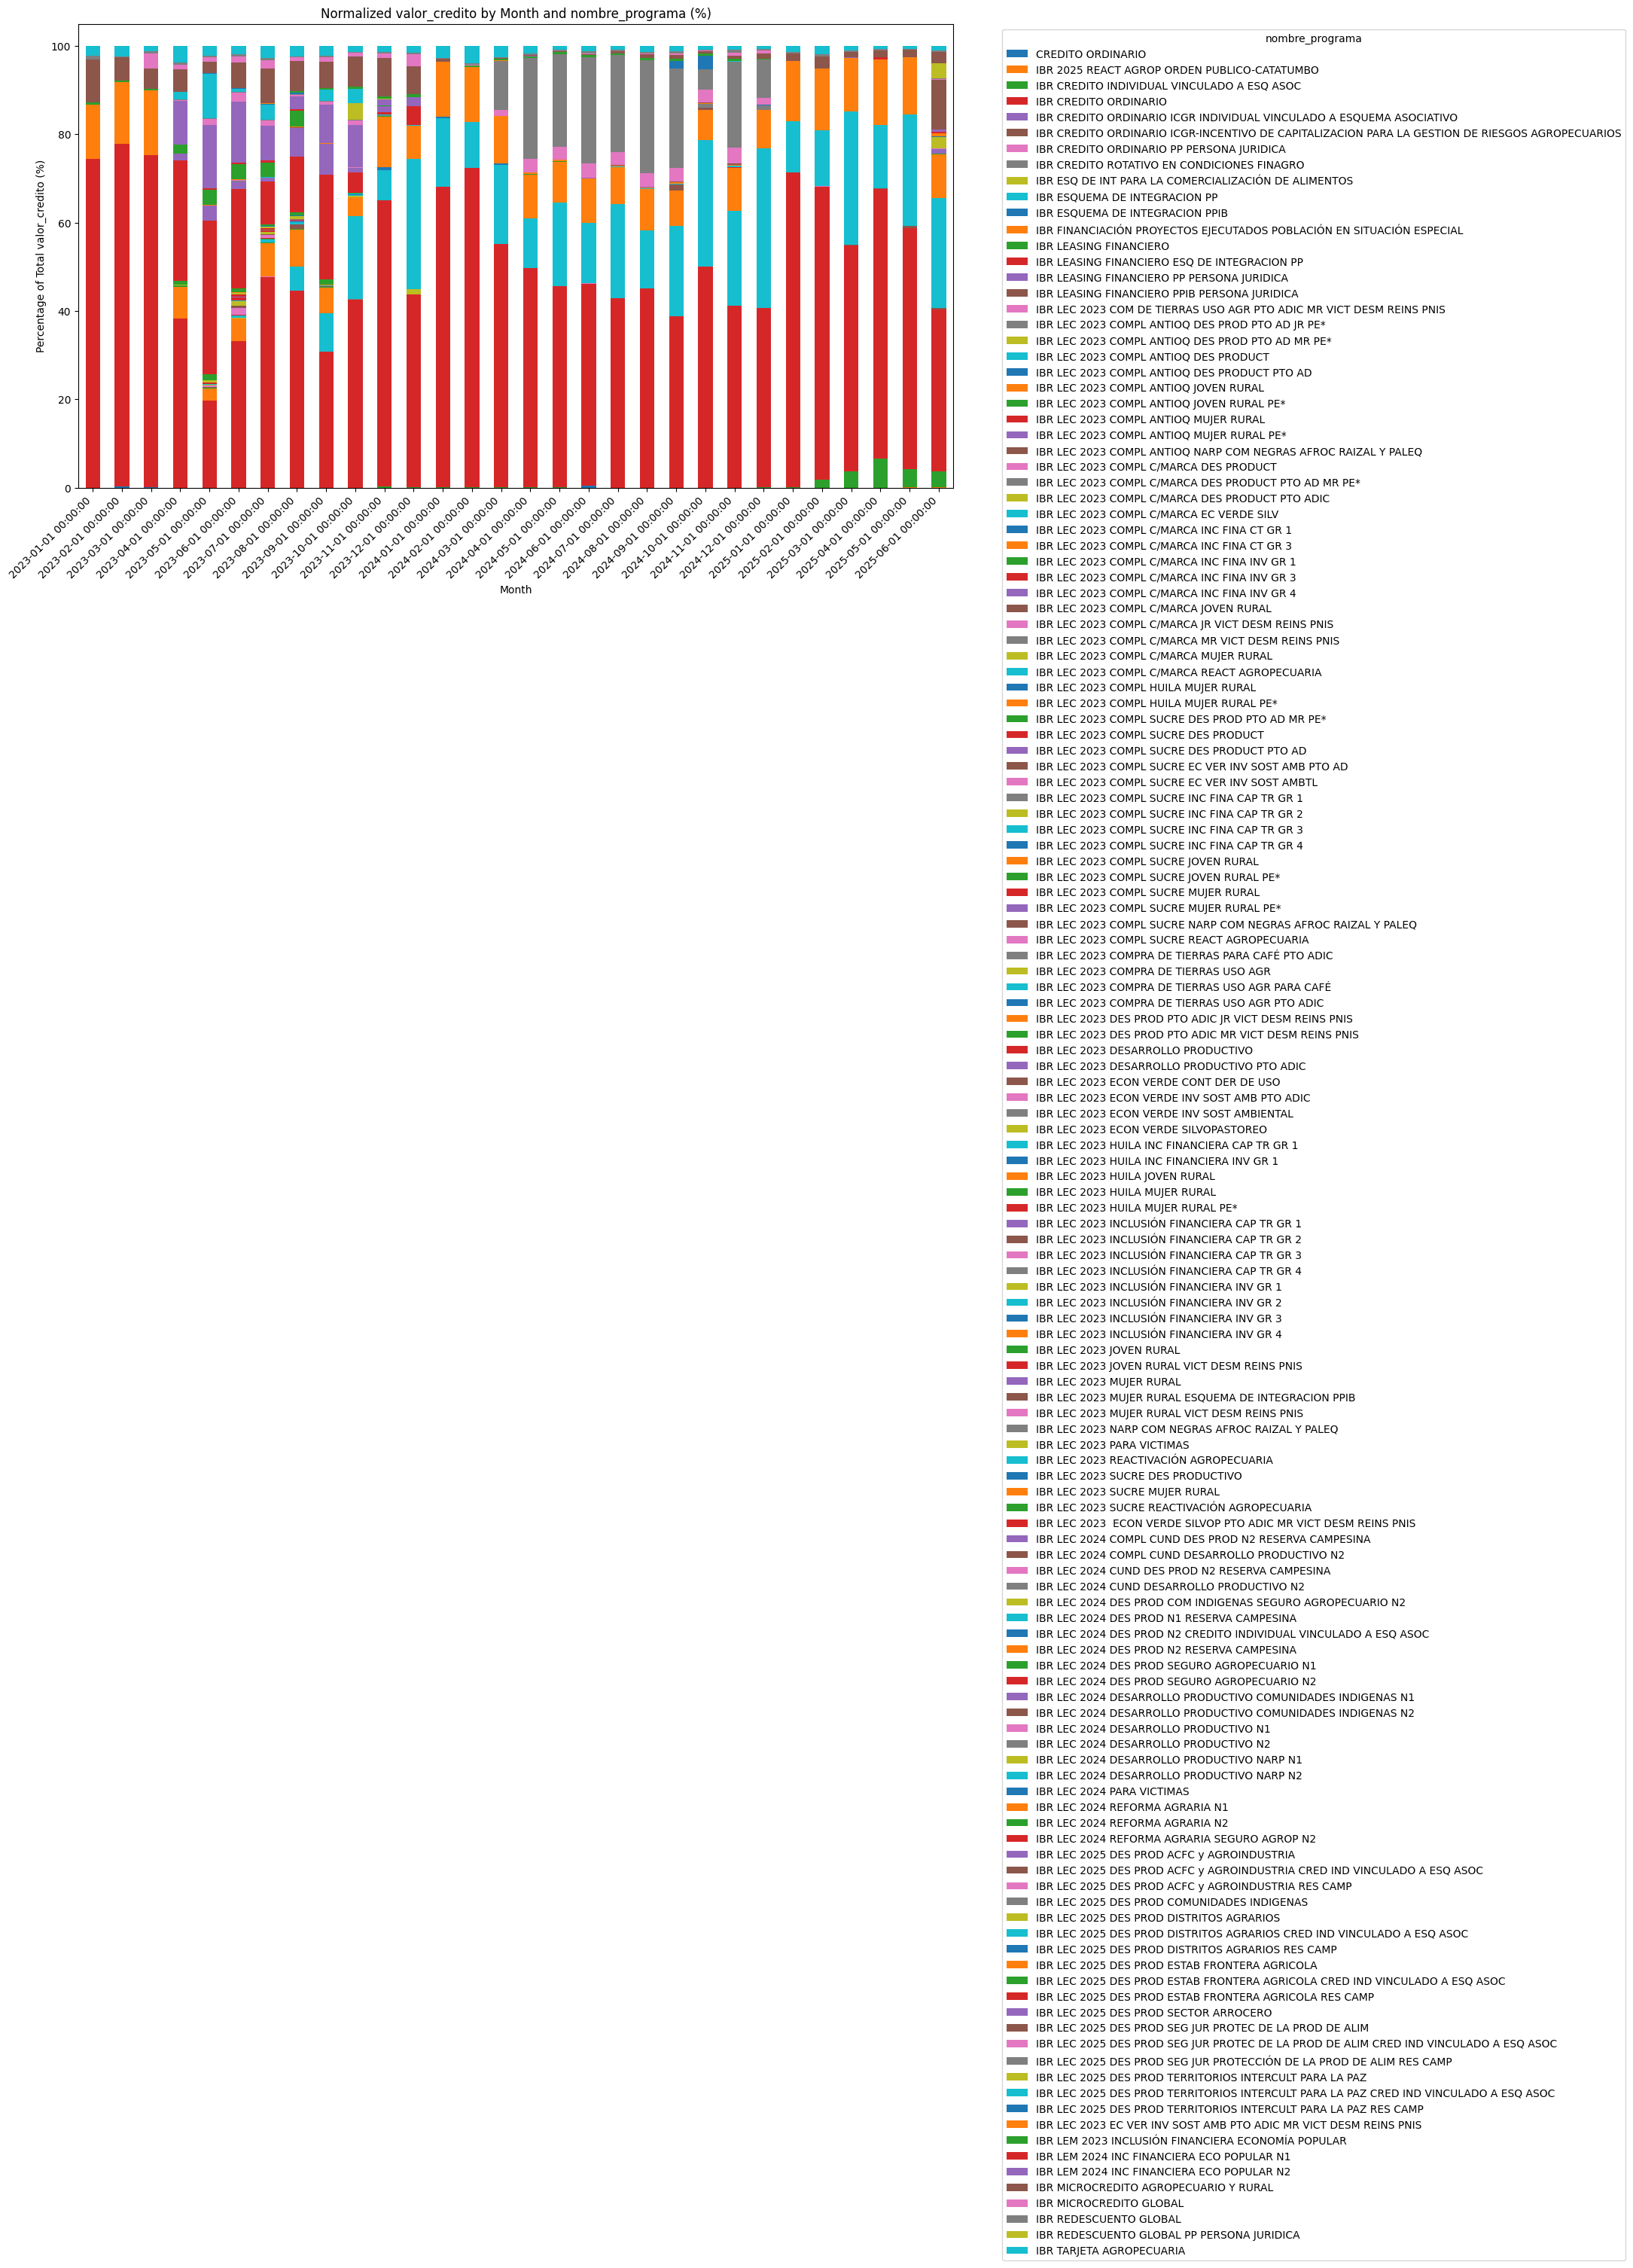

In [ ]:
plot_monthly_categorical_distribution(df_pandas.query("tipo_productor != 'Grande' and tipo_productor != 'Mediano'"), 'nombre_programa', 'valor_credito')


In [ ]:
df_pandas['tipo_productor'].unique()

array(['Pequeño', 'Mediano', 'Pequeño ppib', 'Grande'], dtype=object)

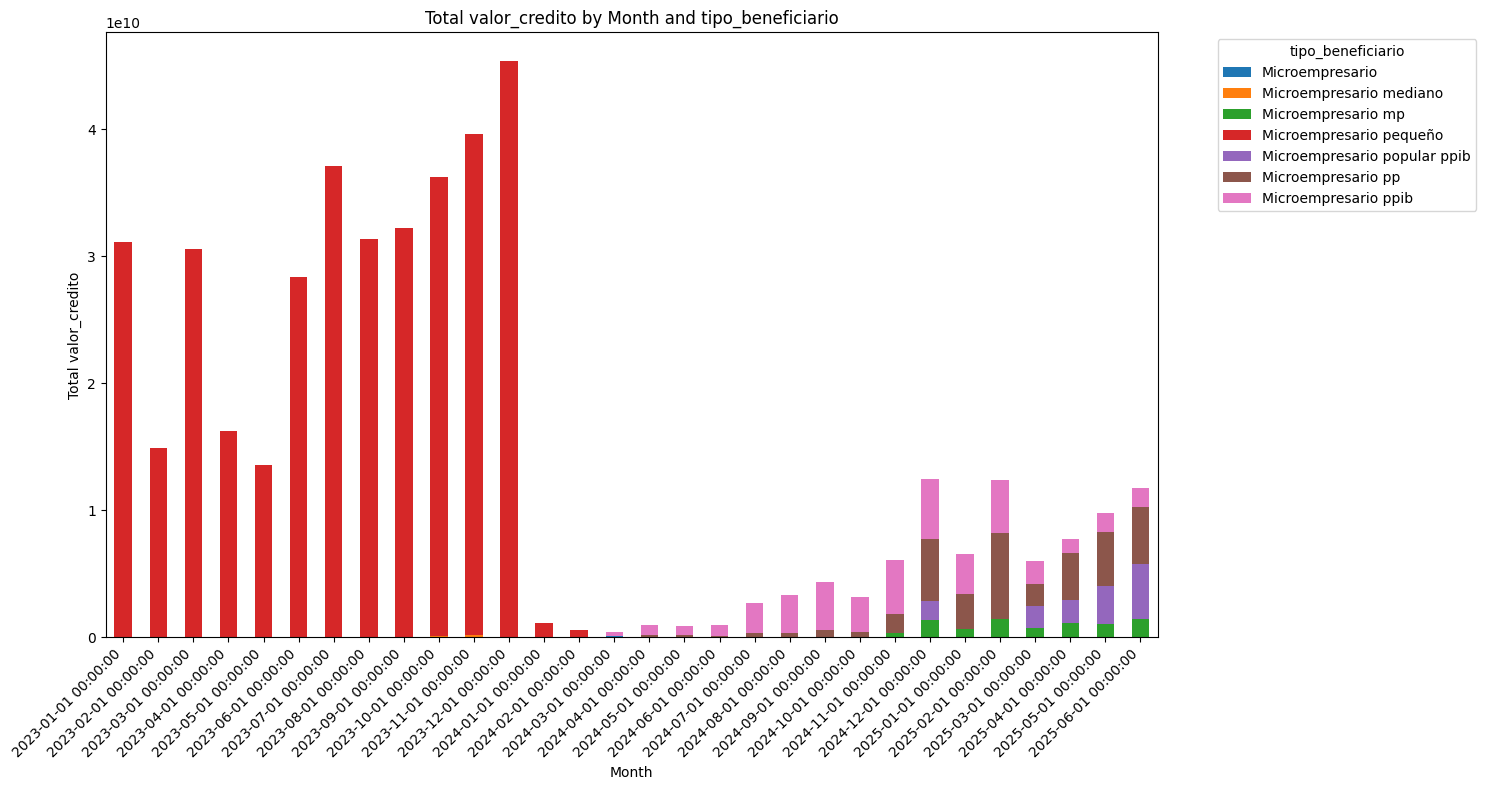

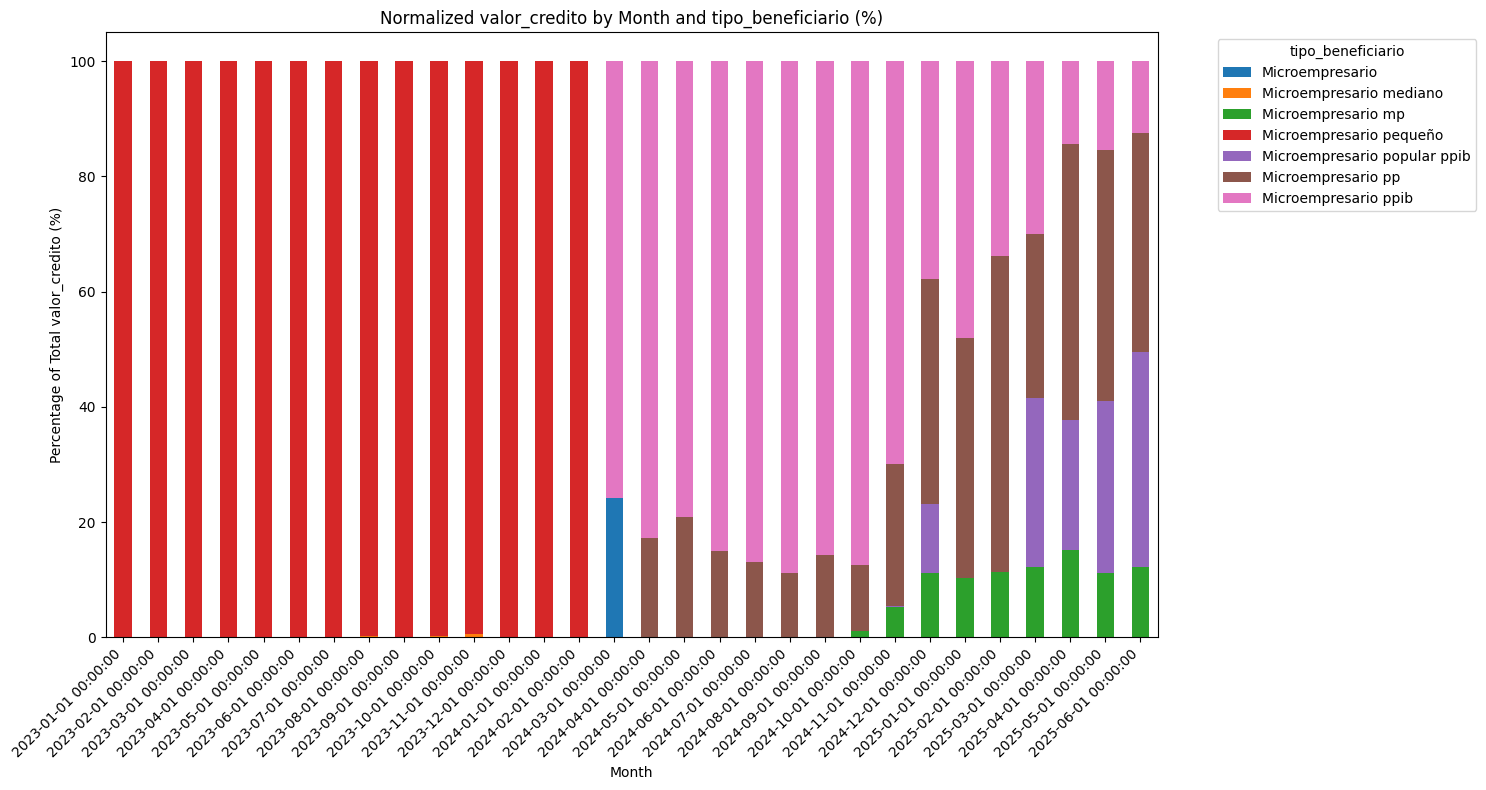

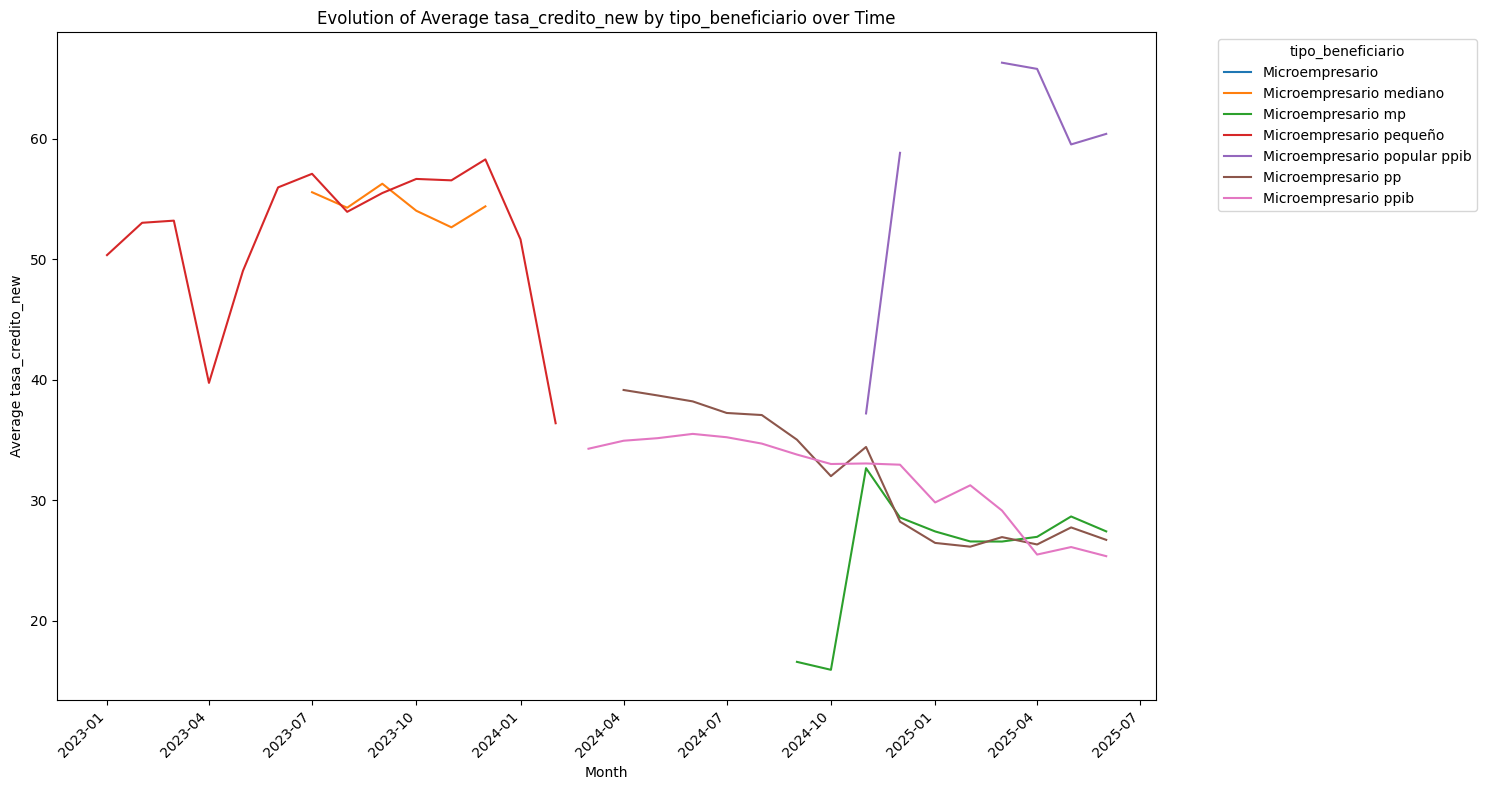

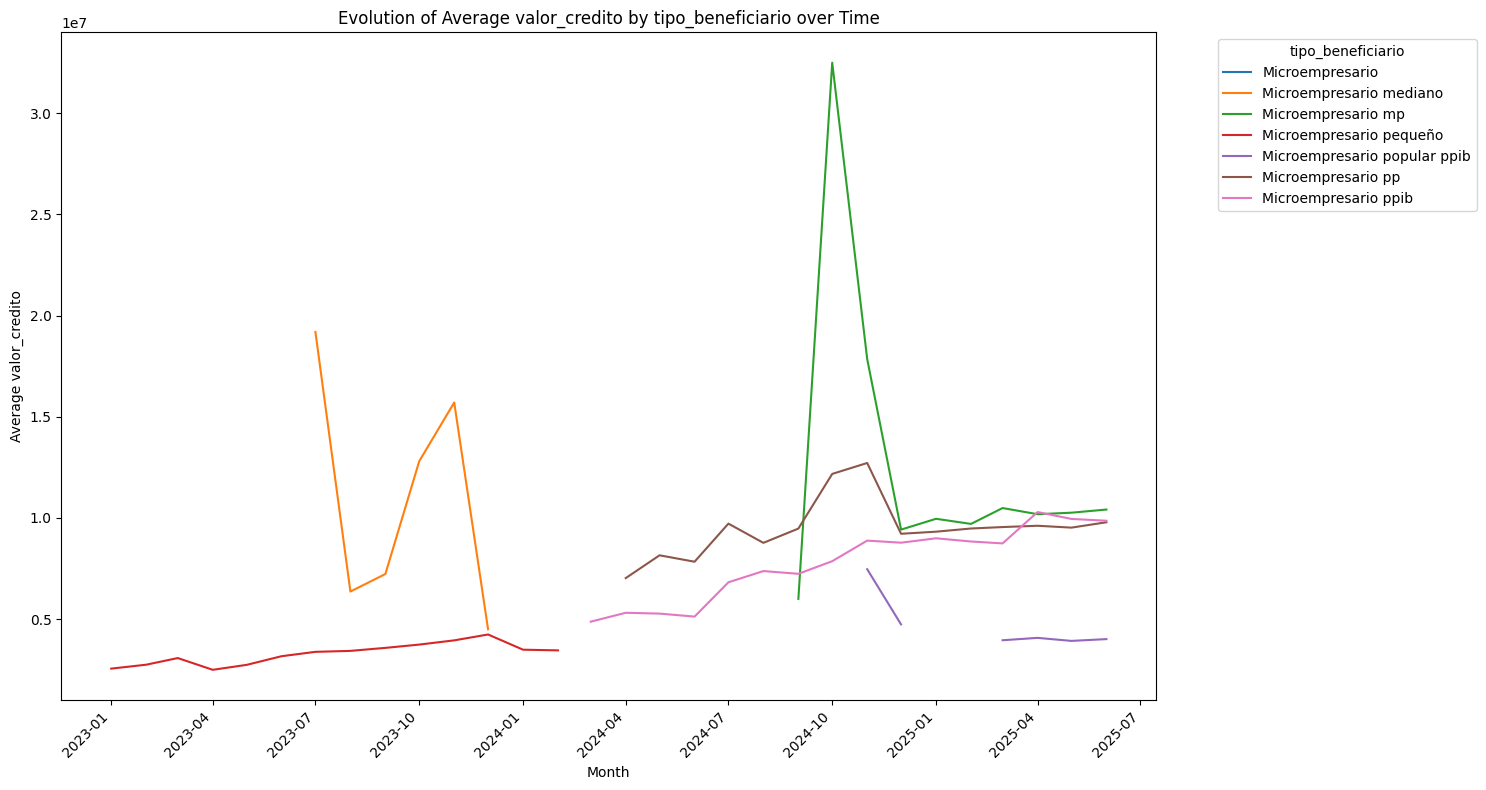

In [ ]:
var = 'tipo_beneficiario'

plot_monthly_categorical_distribution(df_microempresario, var, 'valor_credito')
plot_monthly_numerical_variable(df_microempresario, 'tasa_credito_new', var)
plot_monthly_numerical_variable(df_microempresario, 'valor_credito', var)

### Ruralidad

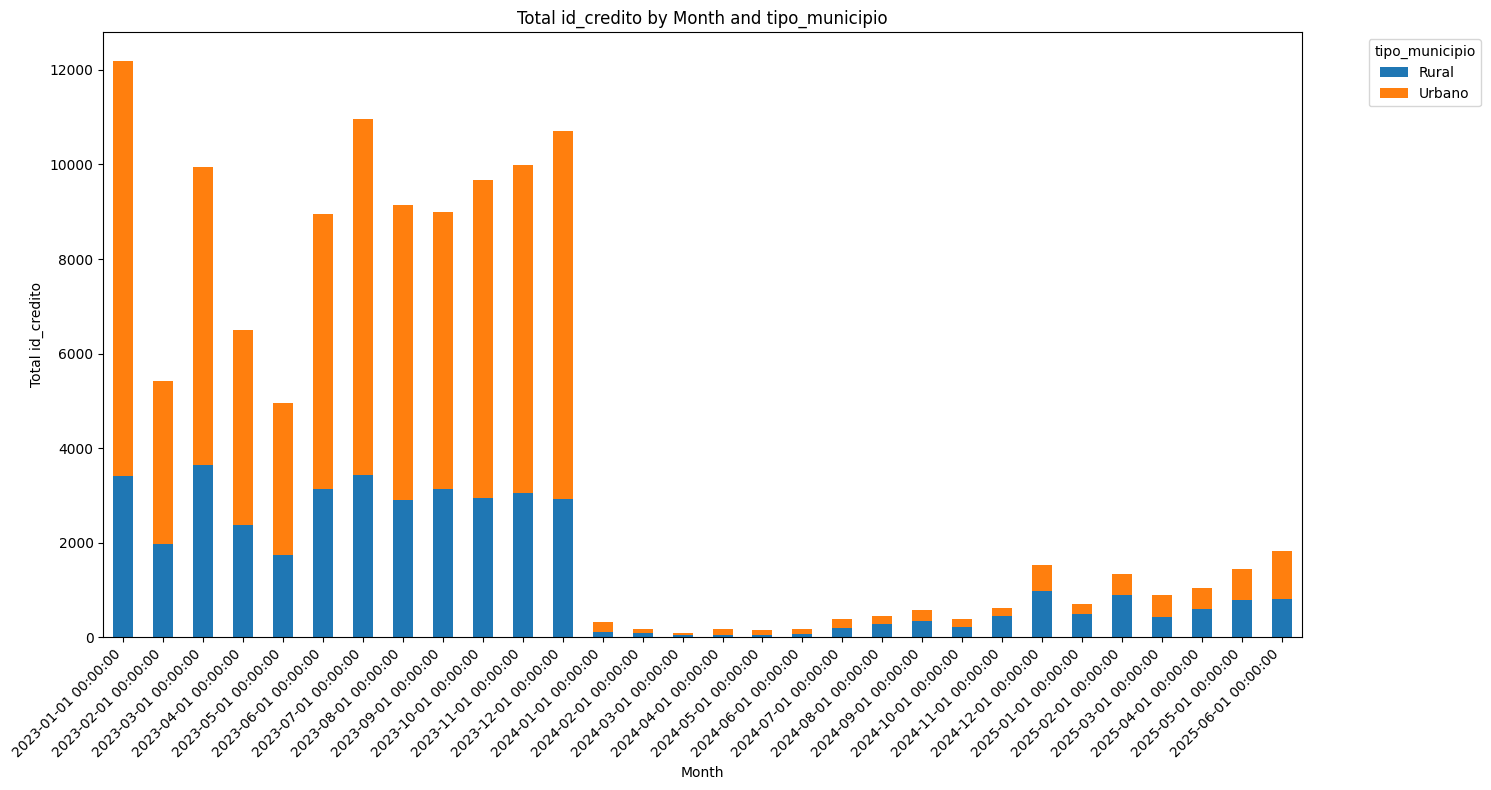

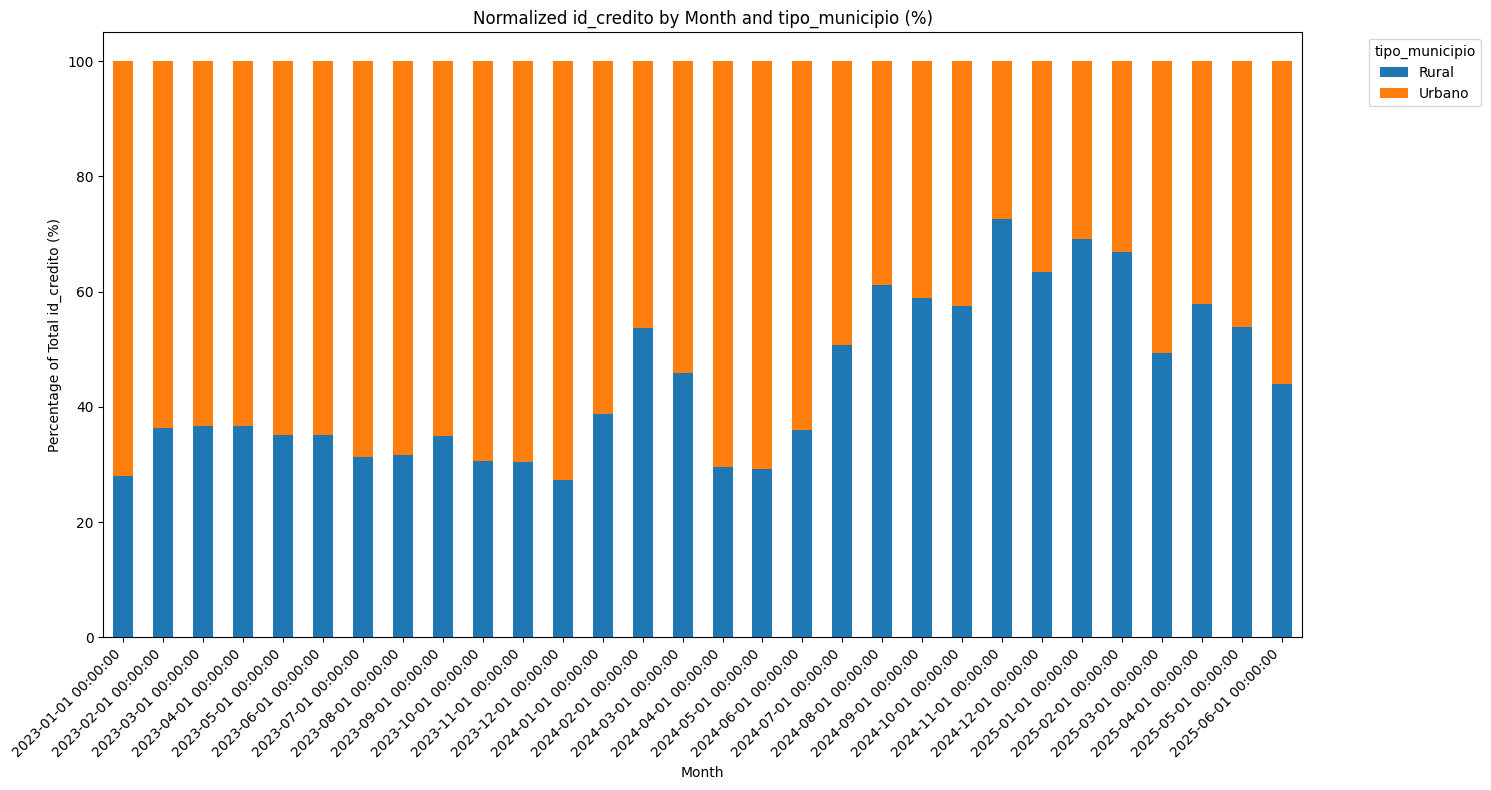

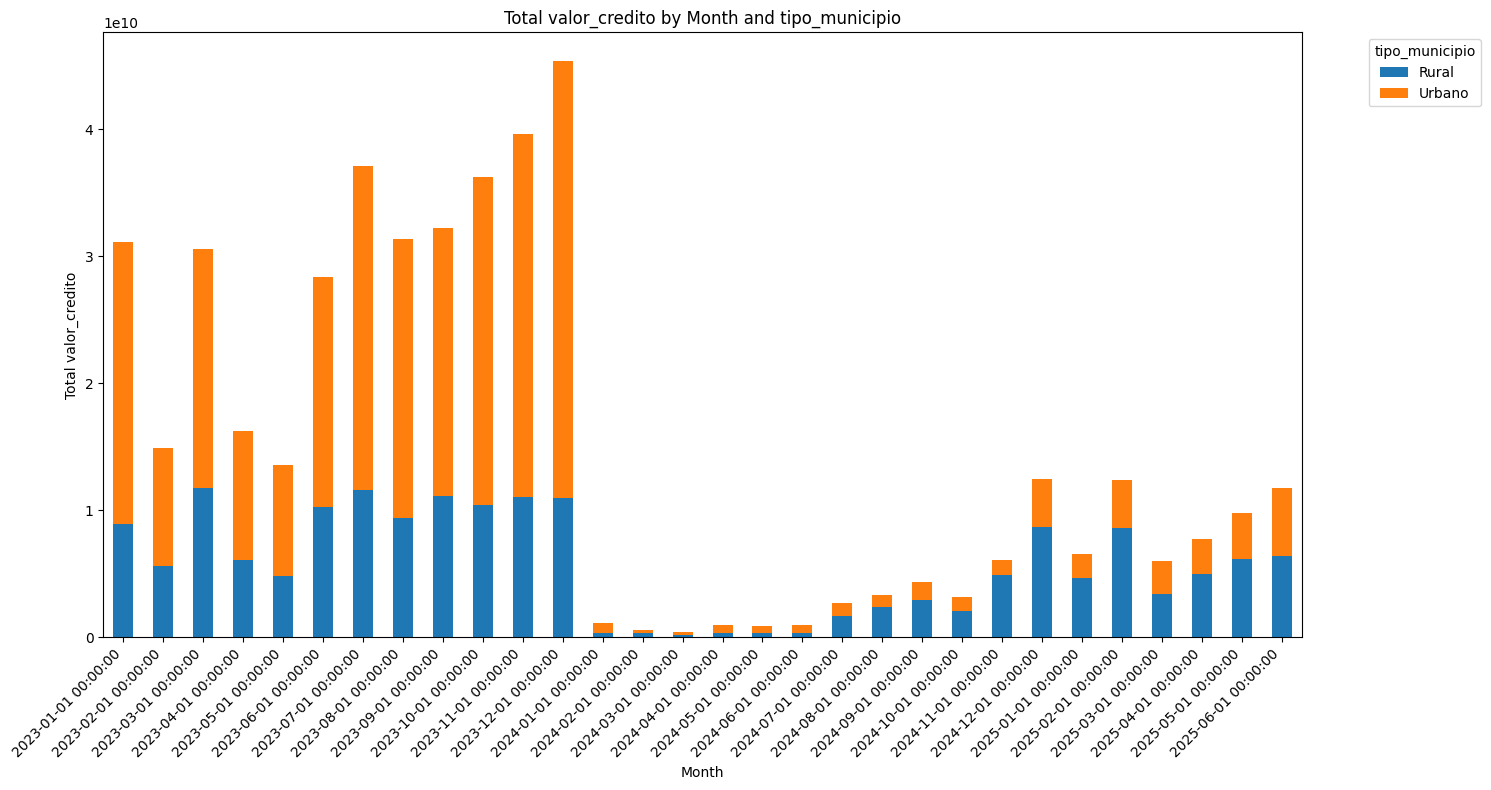

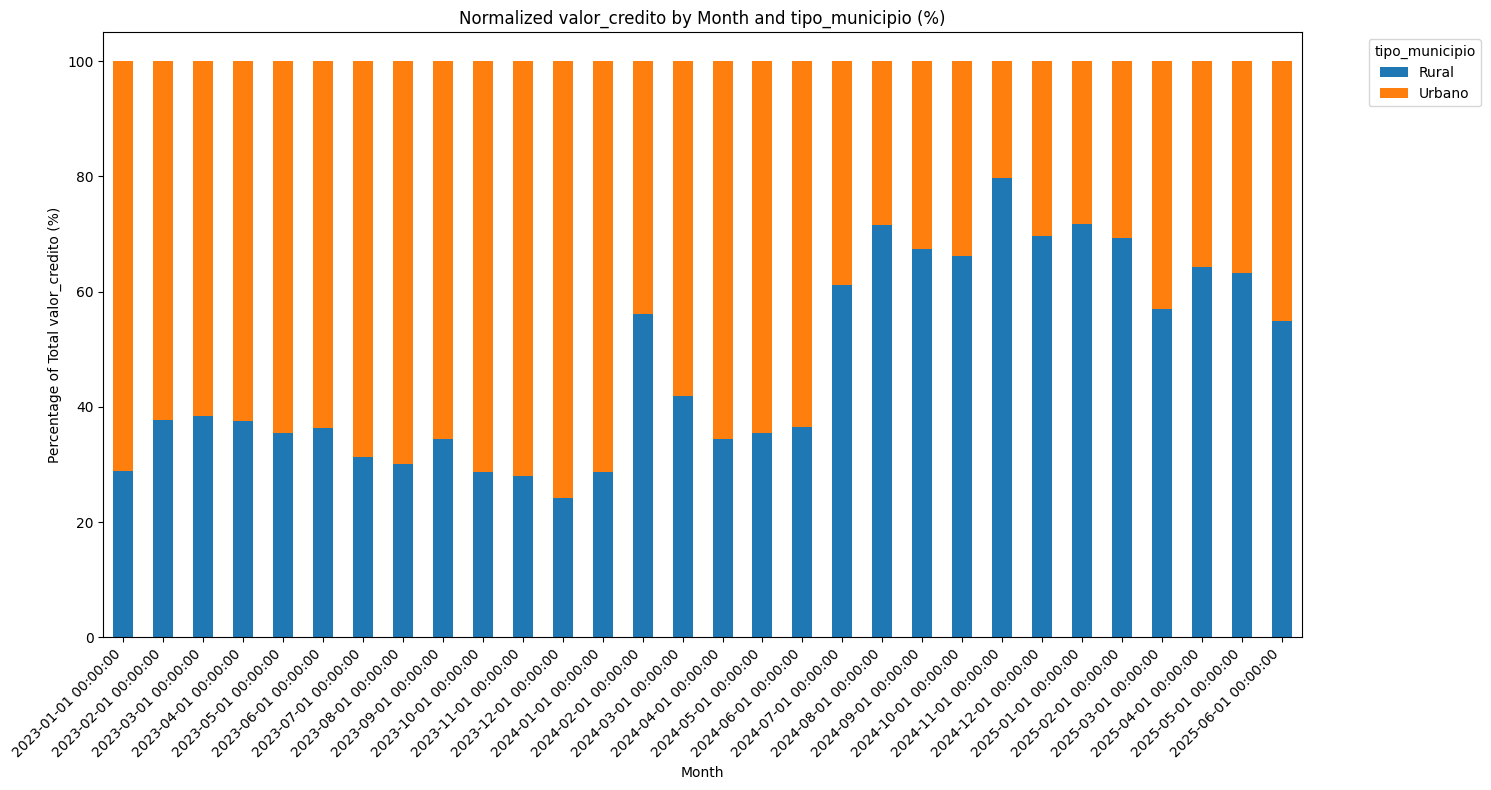

In [ ]:
plot_monthly_categorical_distribution(df_microempresario, 'tipo_municipio', 'id_credito')
plot_monthly_categorical_distribution(df_microempresario, 'tipo_municipio', 'valor_credito')

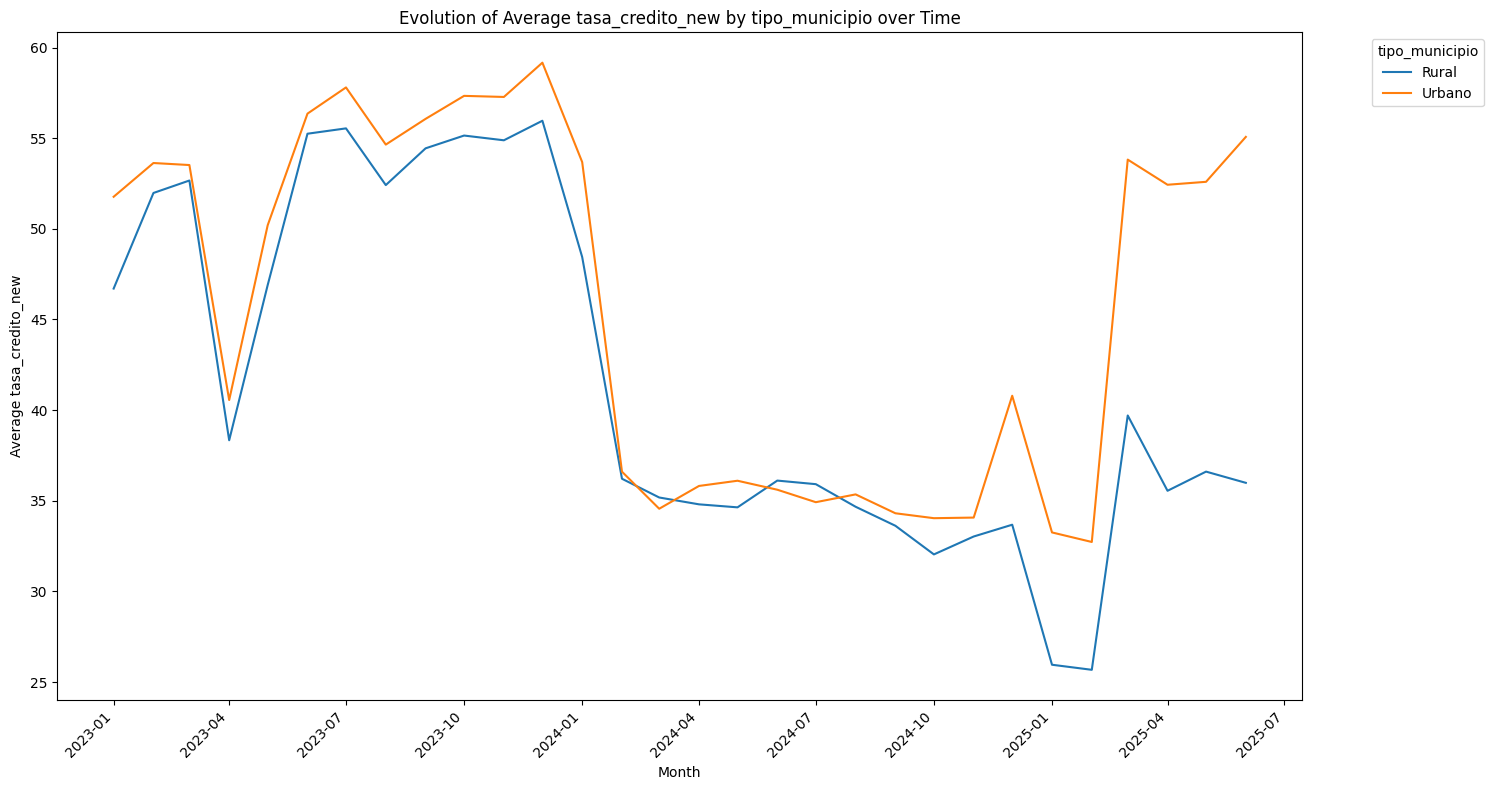

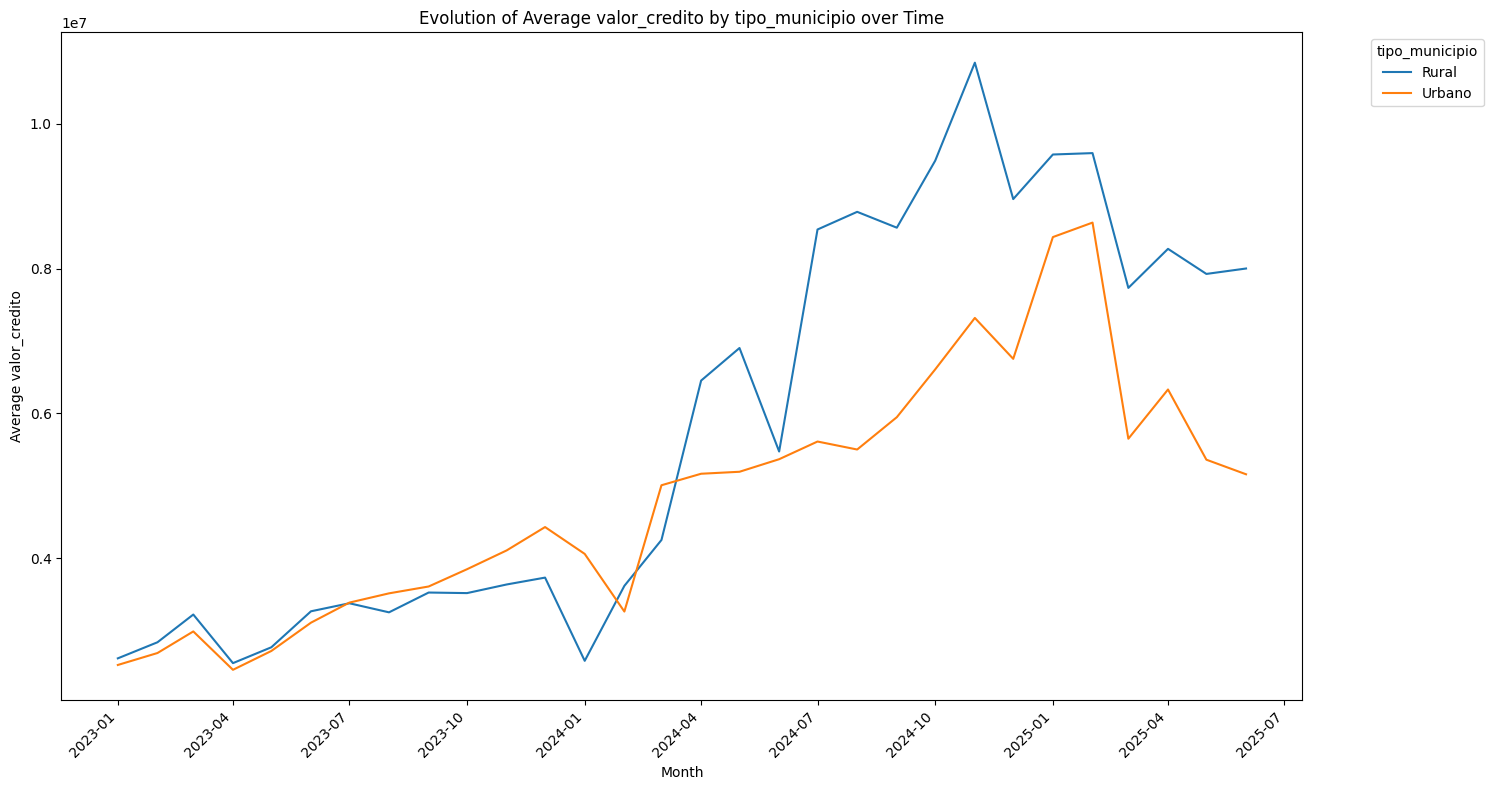

In [ ]:
plot_monthly_numerical_variable(df_microempresario, 'tasa_credito_new', 'tipo_municipio')
plot_monthly_numerical_variable(df_microempresario, 'valor_credito', 'tipo_municipio')

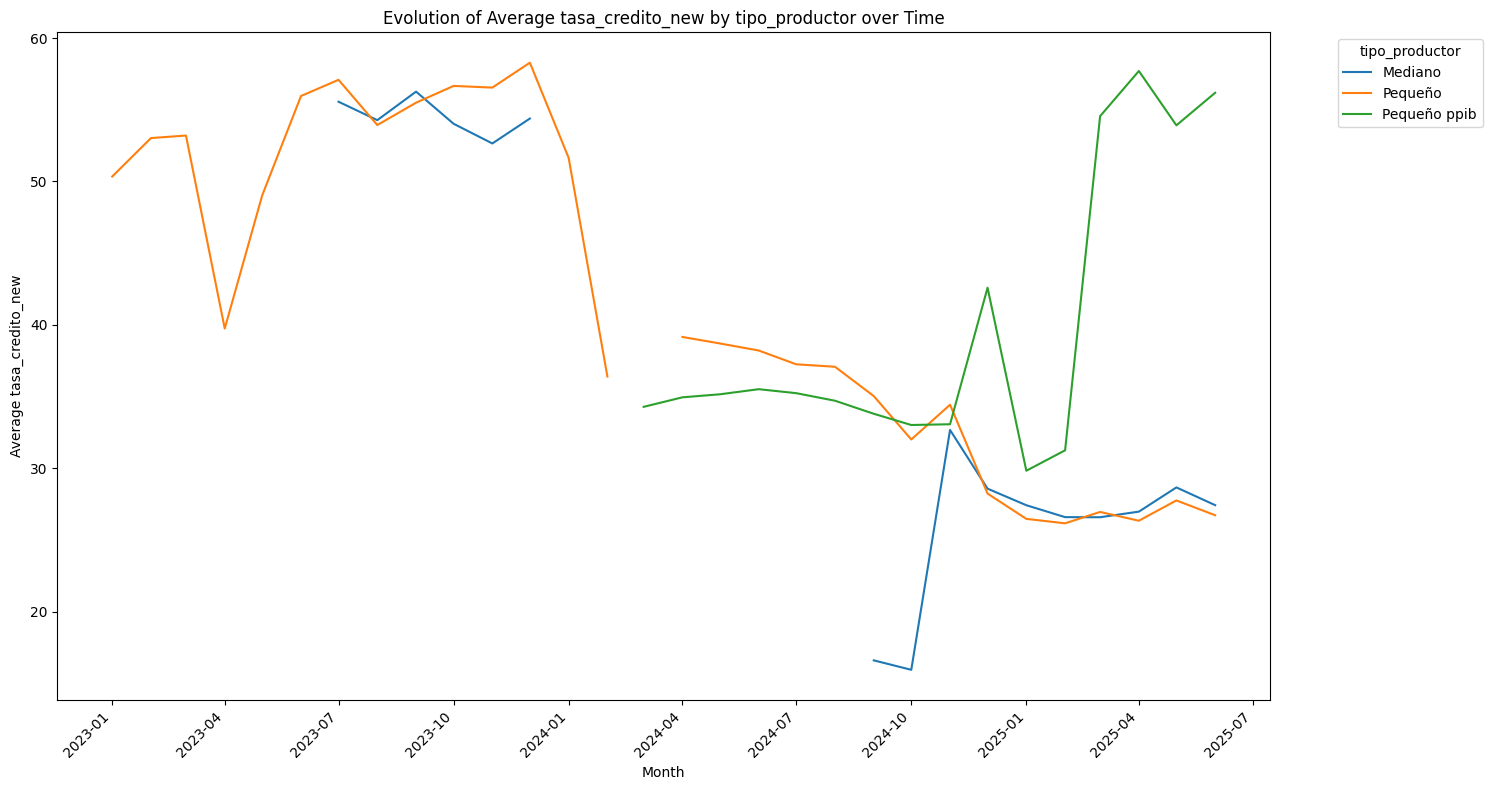

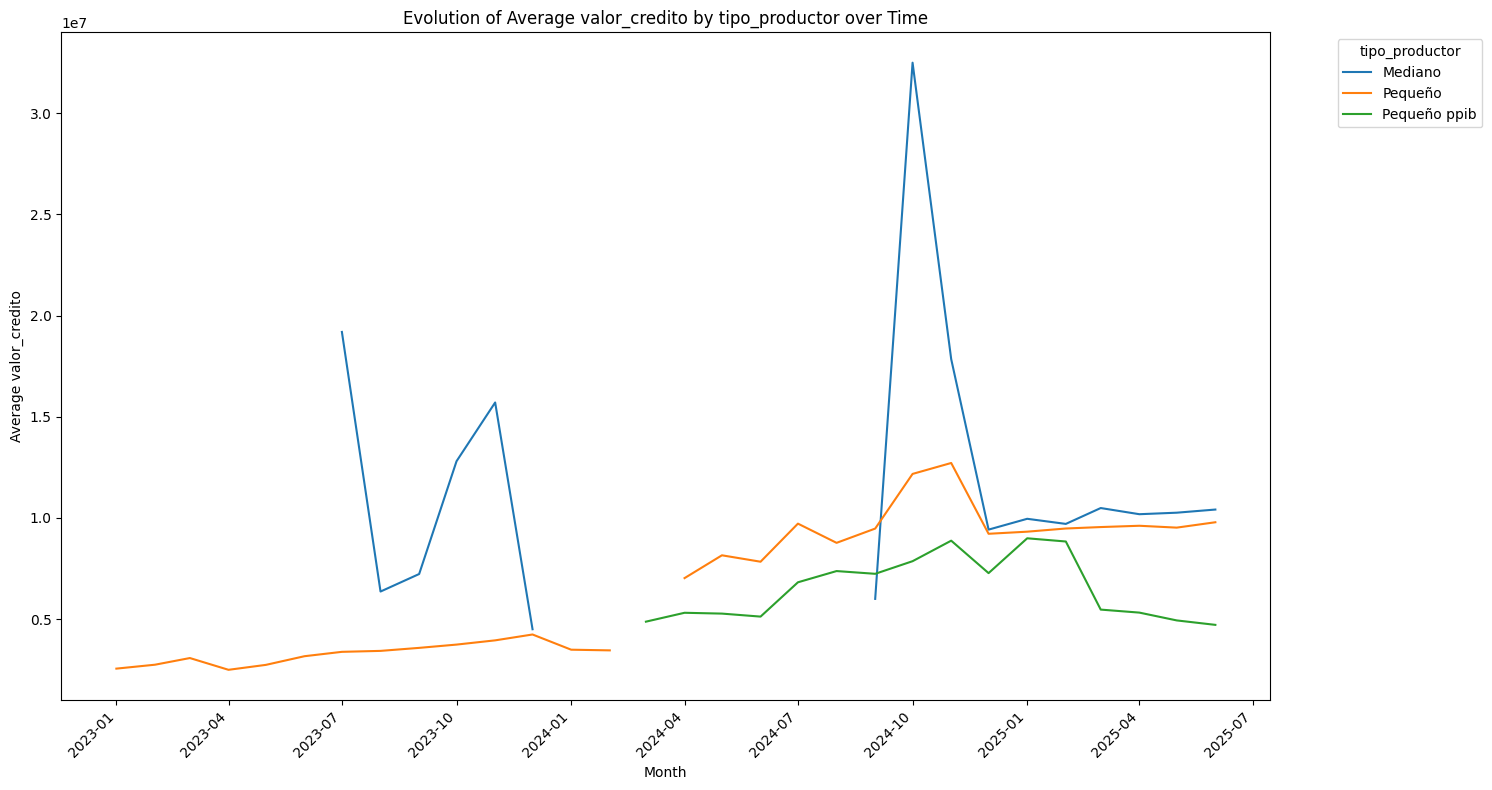

In [ ]:
plot_monthly_numerical_variable(df_microempresario, 'tasa_credito_new', 'tipo_productor')
plot_monthly_numerical_variable(df_microempresario, 'valor_credito', 'tipo_productor')

## Ruralidad vs No Ruralidad

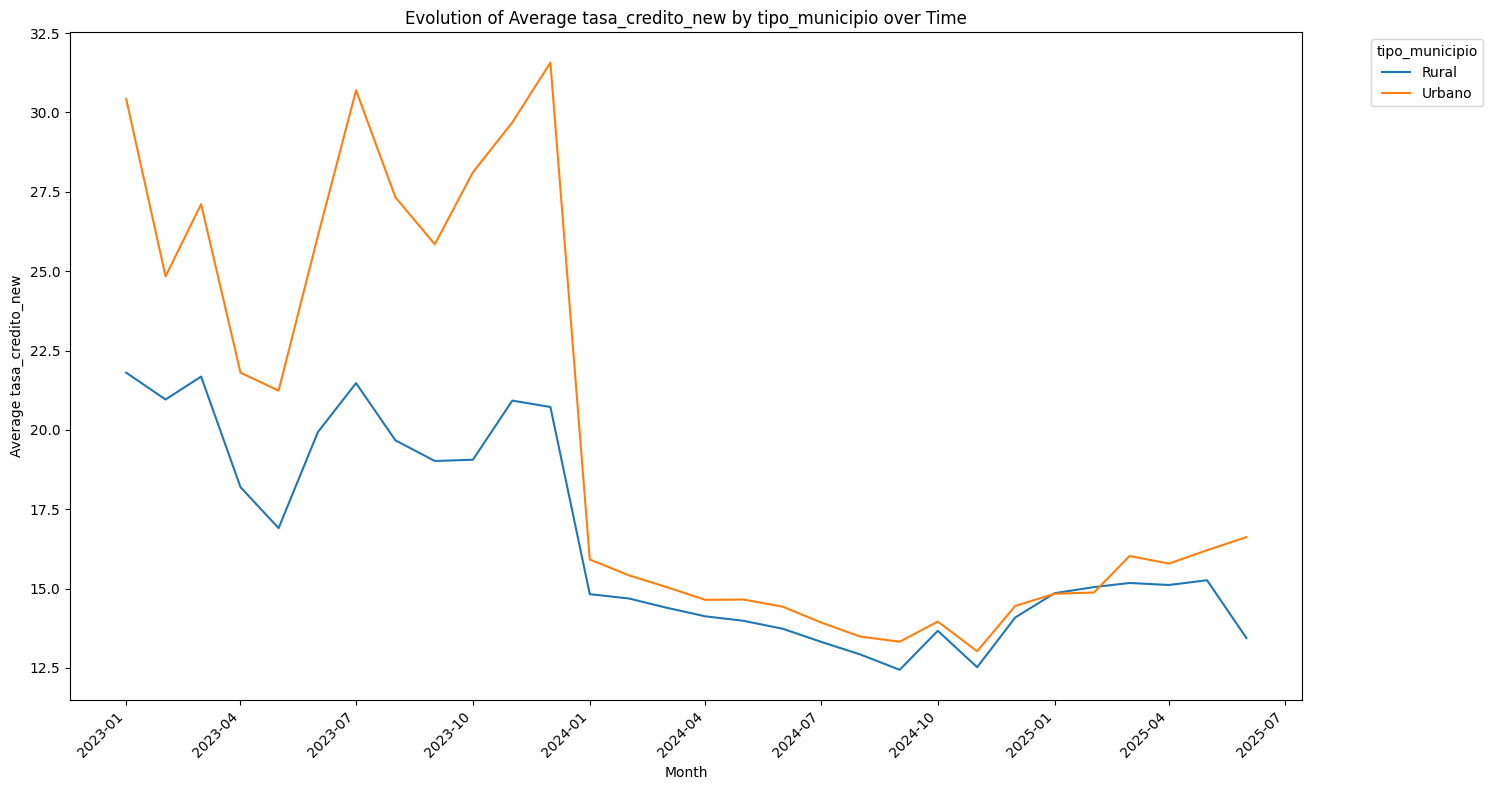

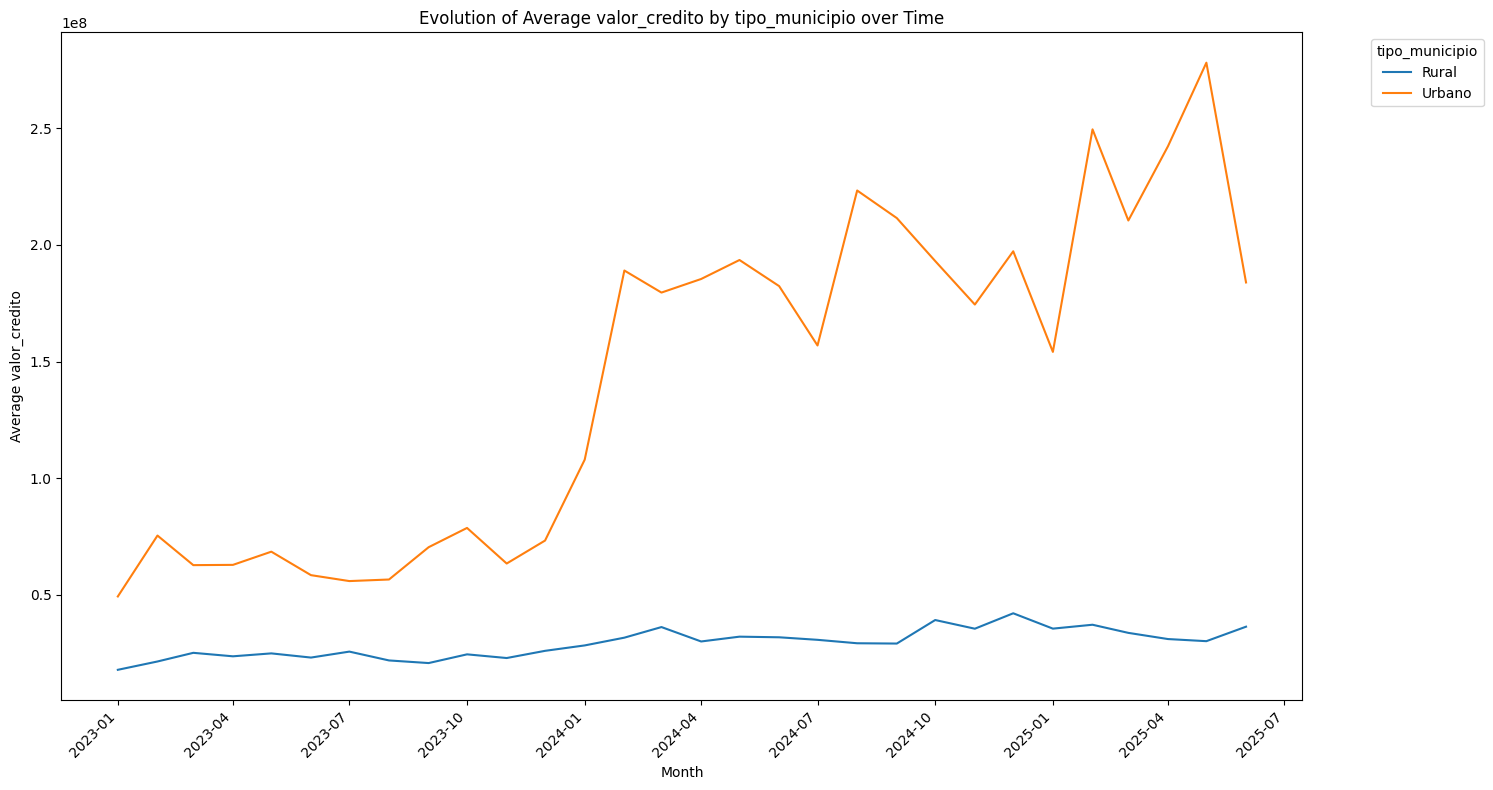

In [ ]:
plot_monthly_numerical_variable(df_pandas, 'tasa_credito_new', 'tipo_municipio')
plot_monthly_numerical_variable(df_pandas, 'valor_credito', 'tipo_municipio')

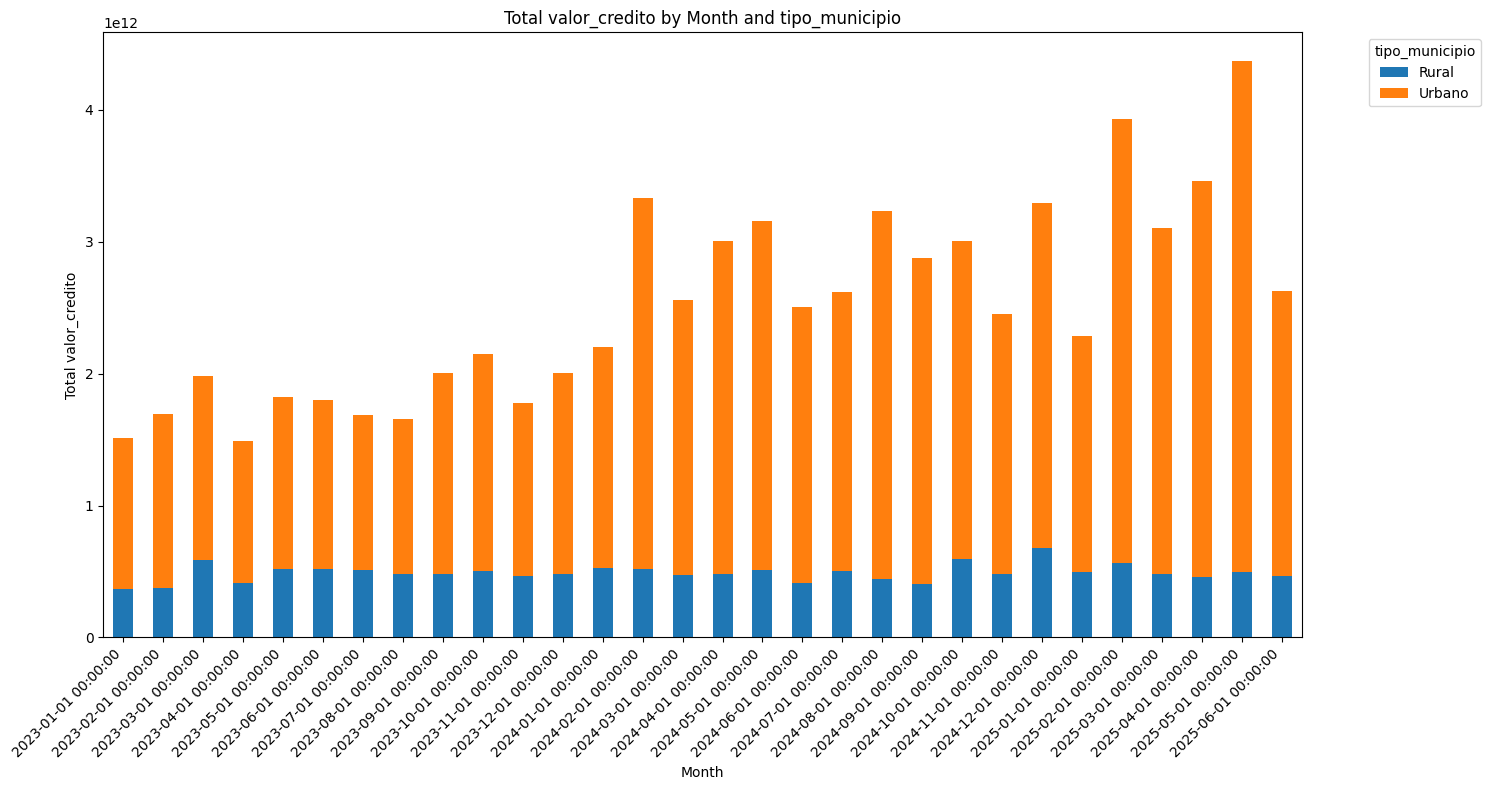

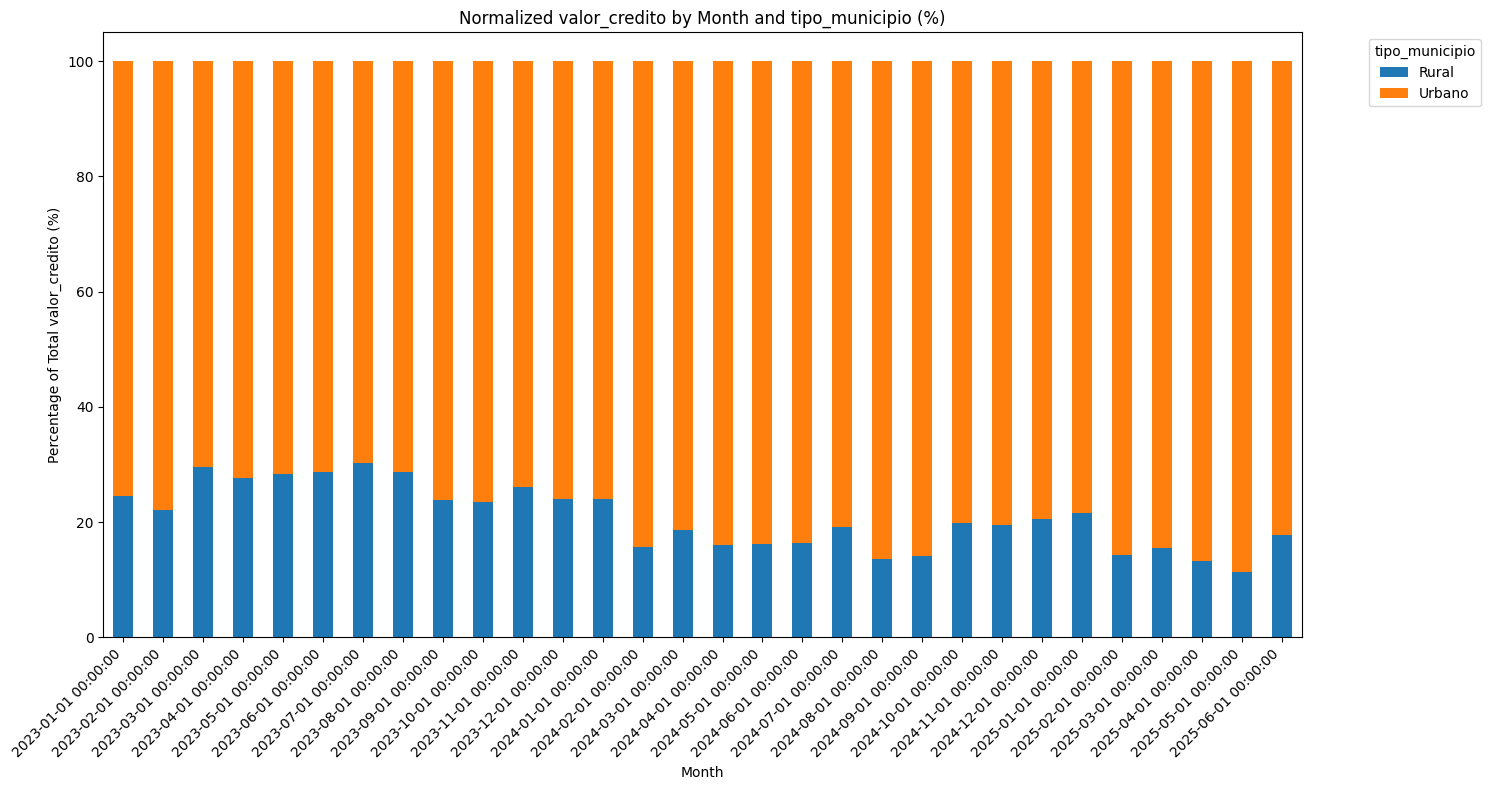

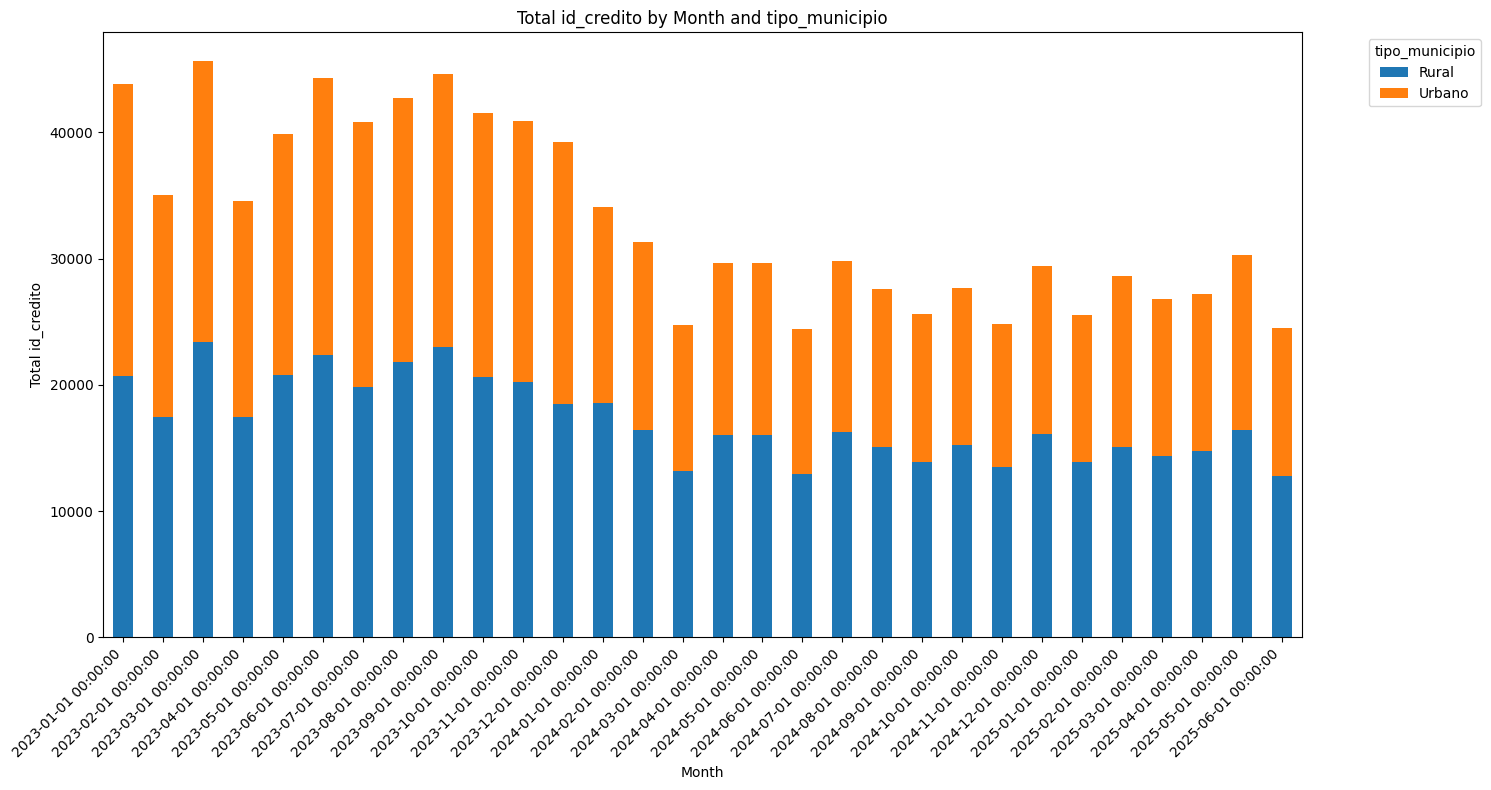

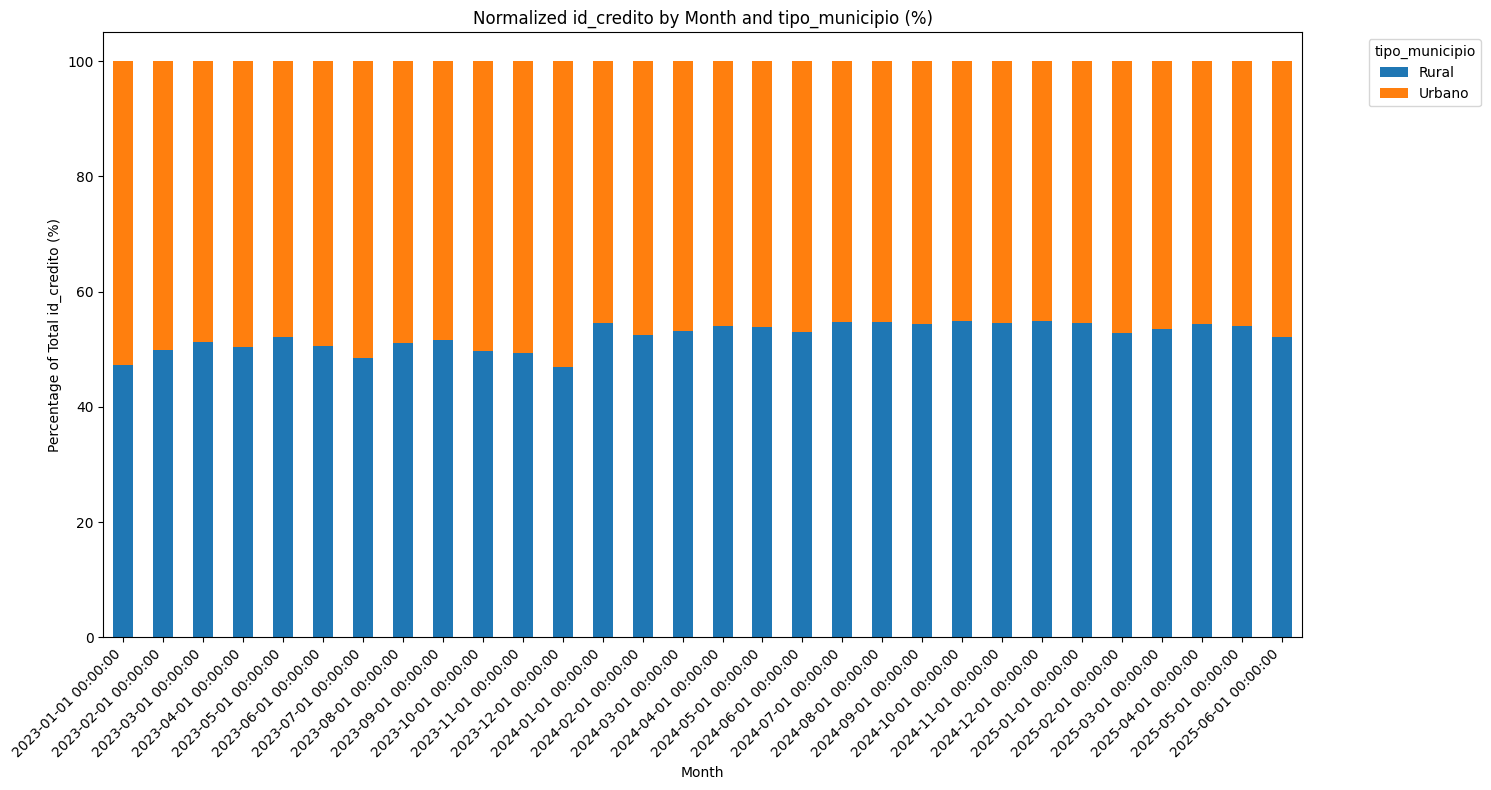

In [ ]:
plot_monthly_categorical_distribution(df_pandas, 'tipo_municipio', 'valor_credito')
plot_monthly_categorical_distribution(df_pandas, 'tipo_municipio', 'id_credito')